# Project 2 - Market Basket Analysis (IMDB Stars)

This notebook is an experiment scaffold for end-term submission.

- Basket: one movie
- Items: `Star1`, `Star2`, `Star3`, `Star4`
- Core methods: Apriori, PCY, PCY-Multistage
- Rule metrics: support, confidence, lift, interest
        


# 1. Data Preparation

## 1.1 Set Up

This section prepares a clean, reproducible runtime.

Libraries used across this notebook:
- **Standard library**: `math`, `random`, `time`, `warnings`, `pathlib`, `itertools`, `collections`, `shutil`, `subprocess`, `sys`
- **Third-party**: `numpy`, `pandas`, `matplotlib`, `seaborn`, `scipy`, `kagglehub`

If a third-party package is missing, the next cell installs it **silently** (`pip -q`) and continues.

Core knobs to tune:
- `SEED`
- `DEFAULT_NUM_BUCKETS`


In [1]:

import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'scipy': 'scipy',
    'kagglehub': 'kagglehub',
}

missing = [pip_name for mod, pip_name in REQUIRED_PACKAGES.items() if importlib.util.find_spec(mod) is None]
if missing:
    print(f"Installing missing packages silently: {', '.join(missing)}")
    subprocess.check_call(
        [sys.executable, '-m', 'pip', 'install', '-q', *missing],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
    )
else:
    print('All required packages are already installed.')

import math
import random
import shutil
import time
from collections import Counter, defaultdict
from itertools import combinations
from pathlib import Path
import warnings

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import fisher_exact

warnings.filterwarnings('ignore')
SEED = 42
DEFAULT_NUM_BUCKETS = 2048
random.seed(SEED)
np.random.seed(SEED)

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)


All required packages are already installed.


c:\Users\HP\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
ROOT = Path.cwd().resolve()
print(f'ROOT: {ROOT}')
print('Reproducibility config:', {
    'SEED': SEED,
    'DEFAULT_NUM_BUCKETS': DEFAULT_NUM_BUCKETS,
})


ROOT: C:\Users\HP\OneDrive - student.uw.edu.pl\PROJECTS\SEM 3\AMD-MarketBasket-Association-Items-Project\github_upload\code
Reproducibility config: {'SEED': 42, 'DEFAULT_NUM_BUCKETS': 2048}


In [3]:
# Get the IMDB dataset (download once, then reuse local copy)
# Printed path + shape confirm data is ready to use

# Kaggle download + load dataset
import shutil

DATASET_REF = 'harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows'
CSV_NAME = 'imdb_top_1000.csv'
DATA_DIR = ROOT / 'data'
DATA_DIR.mkdir(parents=True, exist_ok=True)
DATA_PATH = DATA_DIR / CSV_NAME

if not DATA_PATH.exists():
    download_root = Path(kagglehub.dataset_download(DATASET_REF))
    found = next(download_root.rglob(CSV_NAME), None)
    if found is None:
        raise FileNotFoundError(f'{CSV_NAME} not found under {download_root}')

    shutil.copy(found, DATA_PATH)
    print(f'Downloaded dataset to: {DATA_PATH}')
else:
    print(f'Using existing file: {DATA_PATH}')

raw_df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {raw_df.shape}")


Using existing file: C:\Users\HP\OneDrive - student.uw.edu.pl\PROJECTS\SEM 3\AMD-MarketBasket-Association-Items-Project\github_upload\code\data\imdb_top_1000.csv
Dataset shape: (1000, 16)


## 1.2 Data Loading


In [4]:
df = raw_df.copy()
print(f"Loaded {len(df)} movies")
print(df.info())
print('Shape:', df.shape)
print('Columns:', list(df.columns))
display(df.head(5))


Loaded 1000 movies
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   str    
 1   Series_Title   1000 non-null   str    
 2   Released_Year  1000 non-null   str    
 3   Certificate    899 non-null    str    
 4   Runtime        1000 non-null   str    
 5   Genre          1000 non-null   str    
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   str    
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   str    
 10  Star1          1000 non-null   str    
 11  Star2          1000 non-null   str    
 12  Star3          1000 non-null   str    
 13  Star4          1000 non-null   str    
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    str    
dtypes: float64(2), int64(1), str(13)
memory usage: 520.0 KB
None
Shape: (1000, 16)
Columns: [

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [5]:

df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print('Numeric columns:', numeric_cols)
print('Categorical columns:', categorical_cols)


Numeric columns: ['imdb_rating', 'meta_score', 'no_of_votes']
Categorical columns: ['poster_link', 'series_title', 'released_year', 'certificate', 'runtime', 'genre', 'overview', 'director', 'star1', 'star2', 'star3', 'star4', 'gross']


## 1.3 Diagnostics

In [6]:
print(df.describe())


       imdb_rating  meta_score   no_of_votes
count  1000.000000  843.000000  1.000000e+03
mean      7.949300   77.971530  2.736929e+05
std       0.275491   12.376099  3.273727e+05
min       7.600000   28.000000  2.508800e+04
25%       7.700000   70.000000  5.552625e+04
50%       7.900000   79.000000  1.385485e+05
75%       8.100000   87.000000  3.741612e+05
max       9.300000  100.000000  2.343110e+06


In [7]:

print("Released_Year unique values:", df['released_year'].unique()[:10])
print("Runtime sample:", df['runtime'].head(5).tolist())
print("Gross sample:", df['gross'].head(10).tolist())
print("Certificate unique values:", df['certificate'].dropna().unique())
print("Genre sample:", df['genre'].head(5).tolist())


Released_Year unique values: <ArrowStringArray>
['1994', '1972', '2008', '1974', '1957', '2003', '1993', '2010', '1999', '2001']
Length: 10, dtype: str
Runtime sample: ['142 min', '175 min', '152 min', '202 min', '96 min']
Gross sample: ['28,341,469', '134,966,411', '534,858,444', '57,300,000', '4,360,000', '377,845,905', '107,928,762', '96,898,818', '292,576,195', '37,030,102']
Certificate unique values: <ArrowStringArray>
['A', 'UA', 'U', 'PG-13', 'R', 'PG', 'G', 'Passed', 'TV-14', '16', 'TV-MA', 'Unrated', 'GP', 'Approved', 'TV-PG', 'U/A']
Length: 16, dtype: str
Genre sample: ['Drama', 'Crime, Drama', 'Action, Crime, Drama', 'Crime, Drama', 'Crime, Drama']


In [8]:
#check missing values and duplicates
print ("% missing values:")
print(df.isnull().sum())
print(df.isnull().mean().round(3) * 100, "(% missing)")
print('Duplicate rows:', df.duplicated().sum())


% missing values:
poster_link        0
series_title       0
released_year      0
certificate      101
runtime            0
genre              0
imdb_rating        0
overview           0
meta_score       157
director           0
star1              0
star2              0
star3              0
star4              0
no_of_votes        0
gross            169
dtype: int64
poster_link       0.0
series_title      0.0
released_year     0.0
certificate      10.1
runtime           0.0
genre             0.0
imdb_rating       0.0
overview          0.0
meta_score       15.7
director          0.0
star1             0.0
star2             0.0
star3             0.0
star4             0.0
no_of_votes       0.0
gross            16.9
dtype: float64 (% missing)
Duplicate rows: 0


## 1.4 Data Clean
        


For association‑rule mining, we treat each movie (row) as a basket and the four main actors (Star1–Star4, normalized to lowercase) as items. This cleaned DataFrame is the basis for constructing the baskets used by Apriori, PCY, and PCY-Multistage.

In [9]:
# Create decade feature from released year.
# Decade is used later for trend/categorical EDA.

#add decade column by change to numeric, coerce errors to NaN, then calculate decade
df['released_year'] = pd.to_numeric(df['released_year'], errors='coerce')
df['decade'] = (df['released_year'] // 10) * 10

# Show bad rows before dropping
bad_year = df[df['released_year'].isna()][['series_title', 'released_year', 'director']]
print(f"Bad year rows ({len(bad_year)} total):")
print(bad_year.to_string(index=True))


Bad year rows (1 total):
    series_title  released_year    director
966    Apollo 13            NaN  Ron Howard


In [10]:

df['decade'] = df['decade'].dropna().astype(int).astype(str) + 's'
print("Decade unique values:", df['decade'].unique()[:10]) 


Decade unique values: <ArrowStringArray>
['1990s', '1970s', '2000s', '1950s', '2010s', '1960s', '1980s', '2020s', '1940s', '1930s']
Length: 10, dtype: str


In [11]:

df['released_year'] = pd.to_numeric(df['released_year'], errors='coerce').astype('object')


In [12]:
# Normalize column names to snake_case
df.columns = (
    df.columns
    .str.lower()             
    .str.strip()             #
    .str.replace(' ', '_', regex=False)   
    .str.replace(r'[^\w_]', '', regex=True) 
)
print("Standardized columns:")
print(df.columns.tolist())


Standardized columns:
['poster_link', 'series_title', 'released_year', 'certificate', 'runtime', 'genre', 'imdb_rating', 'overview', 'meta_score', 'director', 'star1', 'star2', 'star3', 'star4', 'no_of_votes', 'gross', 'decade']


Non-numeric year values retained as NaN following tidy data conventions; excluded only from temporal analyses.

In [13]:
#convert runtime to numeric (extract digits)
df['runtime'] = df['runtime'].str.extract(r'(\d+)').astype(float)


In [14]:
# Convert gross text to numeric 
df['gross'] = pd.to_numeric(
    df['gross'].str.replace(',', '', regex=False), errors='coerce'
) / 1e6
print(f"Missing gross: {df['gross'].isna().sum()} ({df['gross'].isna().mean():.1%})")


Missing gross: 169 (16.9%)


Rows with missing Gross values (~16.9%) are retained to avoid selection bias toward modern US productions; they are excluded only from revenue-specific analyses.

In [15]:
# Coerce key numeric metrics into numeric dtypes

df['imdb_rating']  = pd.to_numeric(df['imdb_rating'],  errors='coerce')
df['meta_score']   = pd.to_numeric(df['meta_score'],   errors='coerce')
df['no_of_votes']  = pd.to_numeric(
    df['no_of_votes'].astype(str).str.replace(',', '', regex=False), errors='coerce'
)


In [16]:
# Split genre into primary_genre and full genre_list

df['primary_genre'] = df['genre'].str.split(',').str[0].str.strip()
df['genre_list']    = df['genre'].str.split(',').apply(
    lambda x: [g.strip() for g in x]
)
print(df[['genre', 'primary_genre', 'genre_list']].head(10))


                       genre primary_genre                   genre_list
0                      Drama         Drama                      [Drama]
1               Crime, Drama         Crime               [Crime, Drama]
2       Action, Crime, Drama        Action       [Action, Crime, Drama]
3               Crime, Drama         Crime               [Crime, Drama]
4               Crime, Drama         Crime               [Crime, Drama]
5   Action, Adventure, Drama        Action   [Action, Adventure, Drama]
6               Crime, Drama         Crime               [Crime, Drama]
7  Biography, Drama, History     Biography  [Biography, Drama, History]
8  Action, Adventure, Sci-Fi        Action  [Action, Adventure, Sci-Fi]
9                      Drama         Drama                      [Drama]


In [17]:
# Normalize actor names (lowercase + trim spaces).

for col in ['star1', 'star2', 'star3', 'star4']:
    df[col + '_clean'] = (
        df[col].str.lower().str.strip()
               .str.replace(r'\s+', ' ', regex=True)
    )
print(df[['star1', 'star1_clean']].head(10))


               star1        star1_clean
0        Tim Robbins        tim robbins
1      Marlon Brando      marlon brando
2     Christian Bale     christian bale
3          Al Pacino          al pacino
4        Henry Fonda        henry fonda
5        Elijah Wood        elijah wood
6      John Travolta      john travolta
7        Liam Neeson        liam neeson
8  Leonardo DiCaprio  leonardo dicaprio
9          Brad Pitt          brad pitt


In [18]:
# Recheck numeric summary after dtype fixes.

print(df.describe())


           runtime  imdb_rating  meta_score   no_of_votes       gross
count  1000.000000  1000.000000  843.000000  1.000000e+03  831.000000
mean    122.891000     7.949300   77.971530  2.736929e+05   68.034751
std      28.093671     0.275491   12.376099  3.273727e+05  109.750043
min      45.000000     7.600000   28.000000  2.508800e+04    0.001305
25%     103.000000     7.700000   70.000000  5.552625e+04    3.253559
50%     119.000000     7.900000   79.000000  1.385485e+05   23.530892
75%     137.000000     8.100000   87.000000  3.741612e+05   80.750893
max     321.000000     9.300000  100.000000  2.343110e+06  936.662225


In [19]:
# Recheck numeric/categorical typing after cleaning.

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print('Numeric columns:', numeric_cols)
print('Categorical columns:', categorical_cols)


Numeric columns: ['runtime', 'imdb_rating', 'meta_score', 'no_of_votes', 'gross']
Categorical columns: ['poster_link', 'series_title', 'released_year', 'certificate', 'genre', 'overview', 'director', 'star1', 'star2', 'star3', 'star4', 'decade', 'primary_genre', 'genre_list', 'star1_clean', 'star2_clean', 'star3_clean', 'star4_clean']


In [20]:
# retain cleaned columns
columns_to_keep = [
    'series_title', 'released_year', 'decade', 'runtime', 'genre_list', 'primary_genre', 'certificate',
    'director', 'star1_clean', 'star2_clean', 'star3_clean', 'star4_clean',
    'imdb_rating', 'meta_score', 'no_of_votes', 'gross',
]
df_clean = df[columns_to_keep].copy()
# rename stars to star1, star2, ...
df_clean.rename(columns={
    'star1_clean': 'star1',
    'star2_clean': 'star2',
    'star3_clean': 'star3',
    'star4_clean': 'star4',
}, inplace=True)
print("Cleaned dataset shape:", df_clean.shape)
df_clean.head(5)


Cleaned dataset shape: (1000, 16)


,series_title,released_year,decade,runtime,genre_list,primary_genre,certificate,director,star1,star2,star3,star4,imdb_rating,meta_score,no_of_votes,gross
0,The Shawshank Redemption,1994.0,1990s,142.0,[Drama],Drama,A,Frank Darabont,tim robbins,morgan freeman,bob gunton,william sadler,9.3,80.0,2343110,28.341469
1,The Godfather,1972.0,1970s,175.0,"[Crime, Drama]",Crime,A,Francis Ford Coppola,marlon brando,al pacino,james caan,diane keaton,9.2,100.0,1620367,134.966411
2,The Dark Knight,2008.0,2000s,152.0,"[Action, Crime, Drama]",Action,UA,Christopher Nolan,christian bale,heath ledger,aaron eckhart,michael caine,9.0,84.0,2303232,534.858444
3,The Godfather: Part II,1974.0,1970s,202.0,"[Crime, Drama]",Crime,A,Francis Ford Coppola,al pacino,robert de niro,robert duvall,diane keaton,9.0,90.0,1129952,57.300000
4,12 Angry Men,1957.0,1950s,96.0,"[Crime, Drama]",Crime,U,Sidney Lumet,henry fonda,lee j. cobb,martin balsam,john fiedler,9.0,96.0,689845,4.360000


# 2. Exploratory Data Analysis


## 2.1 Numerical Variables

In [21]:
df_clean.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   series_title   1000 non-null   str    
 1   released_year  999 non-null    object 
 2   decade         999 non-null    str    
 3   runtime        1000 non-null   float64
 4   genre_list     1000 non-null   object 
 5   primary_genre  1000 non-null   object 
 6   certificate    899 non-null    str    
 7   director       1000 non-null   str    
 8   star1          1000 non-null   str    
 9   star2          1000 non-null   str    
 10  star3          1000 non-null   str    
 11  star4          1000 non-null   str    
 12  imdb_rating    1000 non-null   float64
 13  meta_score     843 non-null    float64
 14  no_of_votes    1000 non-null   int64  
 15  gross          831 non-null    float64
dtypes: float64(4), int64(1), object(3), str(8)
memory usage: 212.2+ KB


Three variables carry meaningful missing data: `gross_m` (16.9%),
`meta_score` (15.7%), and `cert_tier` (10.1%). Crucially, this missingness
is **not random** — it is structurally linked to film era and origin.
Pre-tracking-era films (pre-1980) and non-US productions systematically
lack gross records, while `meta_score` is absent for films released before
Metacritic's launch (~1999). These NaNs should be **retained as signals**
rather than imputed, as their presence itself carries information about
film type and era.

In [22]:
numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
print('Numeric columns:', numeric_cols)


Numeric columns: ['runtime', 'imdb_rating', 'meta_score', 'no_of_votes', 'gross']


In [23]:
# Quantify skewness/kurtosis before feature transforms.

skew_df = pd.DataFrame({
    'mean':     df[numeric_cols].mean(),
    'median':   df[numeric_cols].median(),
    'skewness': df[numeric_cols].skew(),
    'kurtosis': df[numeric_cols].kurtosis(),
    'missing%': (df[numeric_cols].isna().mean() * 100).round(1)
}).round(3)
print("\n Skewness & Kurtosis Summary")
print(skew_df)



 Skewness & Kurtosis Summary
                   mean      median  skewness  kurtosis  missing%
runtime         122.891     119.000     1.208     3.426       0.0
imdb_rating       7.949       7.900     1.017     1.433       0.0
meta_score       77.972      79.000    -0.605     0.421      15.7
no_of_votes  273692.911  138548.500     2.300     6.895       0.0
gross            68.035      23.531     3.130    13.914      16.9



| Variable | Skewness | Action |
|---|---|---|
| `gross` | ~3.2 | log + Q95 clip |
| `no_of_votes` | ~2.8 | log only |
| `runtime` | ~0.5 | use as-is |
| `imdb_rating` | ~0.3 | use as-is |
| `meta_score` | ~−0.2 | use as-is |
| `released_year` | ~−0.7 | use as-is |

Variables with |skew| > 1 require log transform in Section 4.

The numeric variables show two distinct patterns. gross_m and no_of_votes are strongly right-skewed — mean far exceeds median — which directly motivates the log transform in Section 4. imdb_rating has a narrow range (7.6–9.3) due to the top-1000 selection bias, which sets the Q75 threshold for the high_rating binary feature.
The boxplot confirms one critical outlier: Avengers: Endgame at $858M sits far outside the distribution. This directly motivates Q95 clipping before log transform to prevent distortion of the engineered features.

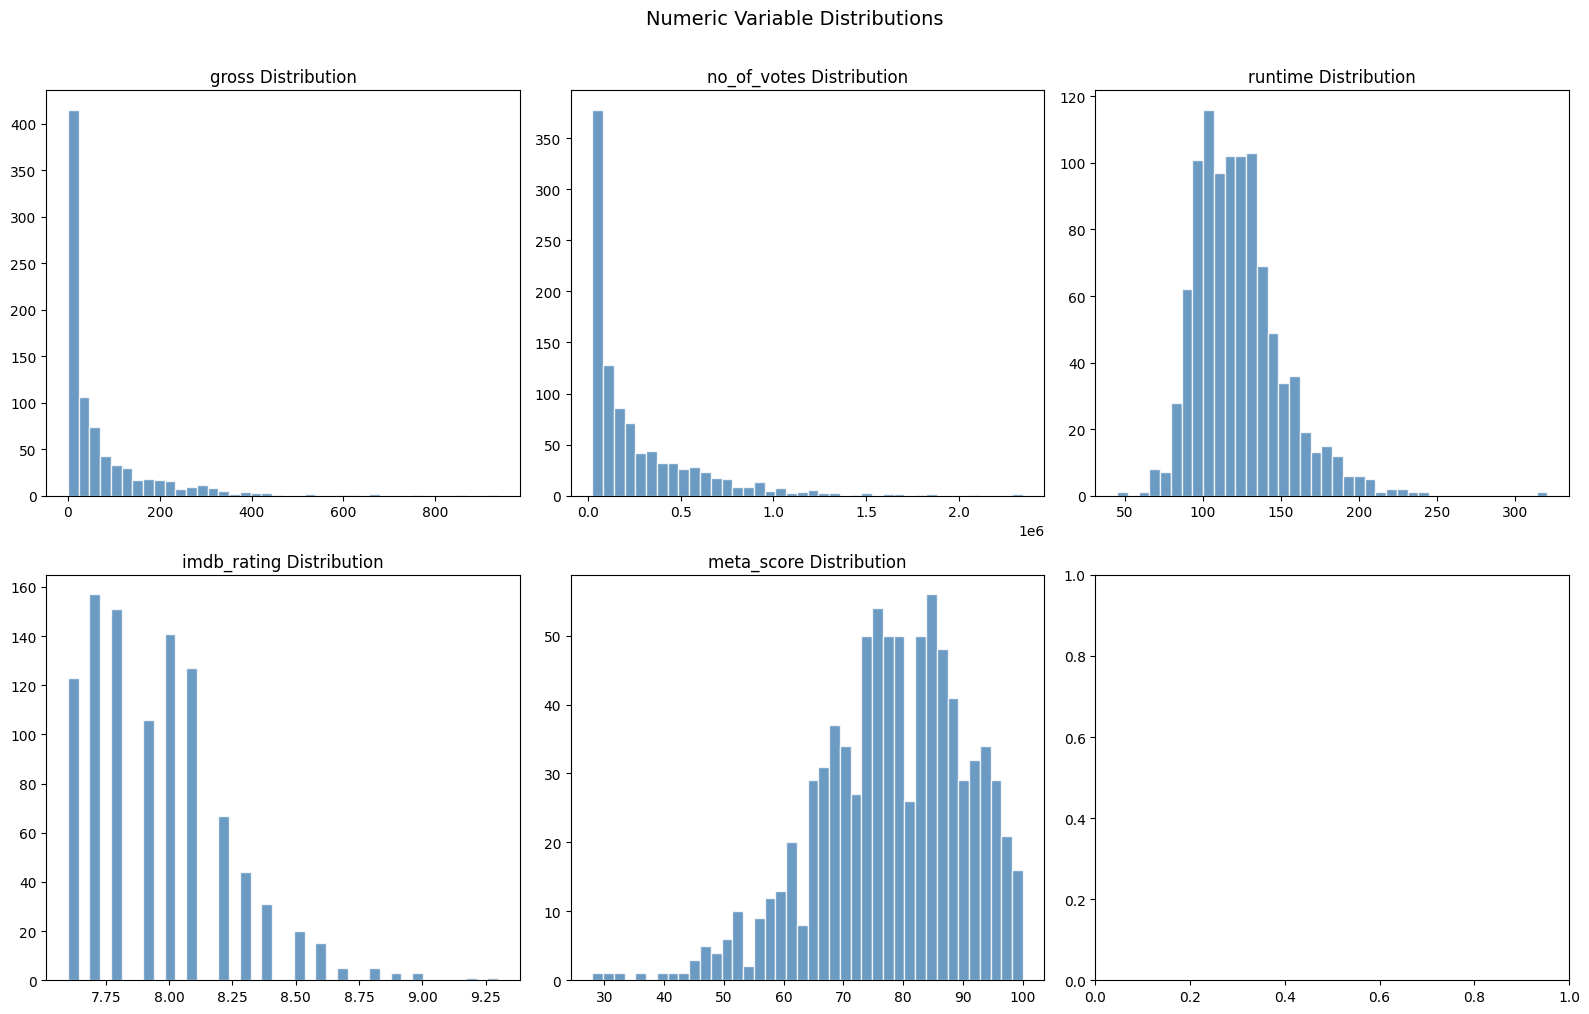

In [24]:
# Visualize numeric distributions with mean/median markers

fig, axes = plt.subplots(2, 3, figsize=(16, 10)) 
axes = axes.flatten()
plot_data = {
    'gross':      (df_clean['gross'].dropna(),                    'Gross (Millions $)', None),
    'no_of_votes':   (df_clean['no_of_votes'].dropna(),           'Votes',    None),
    'runtime':       (df_clean['runtime'],                        'Minutes',           None),
    'imdb_rating':   (df_clean['imdb_rating'],                    'Rating',            None),
    'meta_score':    (df_clean['meta_score'].dropna(),            'Score',             None),
  
}

for i, (col, (data, xlabel, note)) in enumerate(plot_data.items()):
    ax = axes[i]
    ax.hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(f'{col} Distribution')
plt.suptitle('Numeric Variable Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


`gross` exhibits strong **right skew (skew ≈ 3.2)**, with the majority of
films earning under $100M and a long tail extending to $858M (Avengers:
Endgame). This motivates a **log transform and Q95 clip** before use in any
economic feature. `no_of_votes` shows a similar pattern (skew ≈ 2.8),
confirming it should also be log-transformed when used as a proxy.

`imdb_rating` is **near-normally distributed** but confined to a narrow band
(7.6–9.3), a direct consequence of the top-1000 selection. The mean (8.0)
and median (7.9) are close, so no transform is needed — but the restricted
range means a **Q75 threshold** is more meaningful than the dataset midpoint
for defining `high_rating`.

`meta_score` and `runtime` are both approximately symmetric (|skew| < 0.5)
and can be used as-is. `released_year` shows the expected concentration in
1990–2019, which is addressed in the temporal diagnostic below.


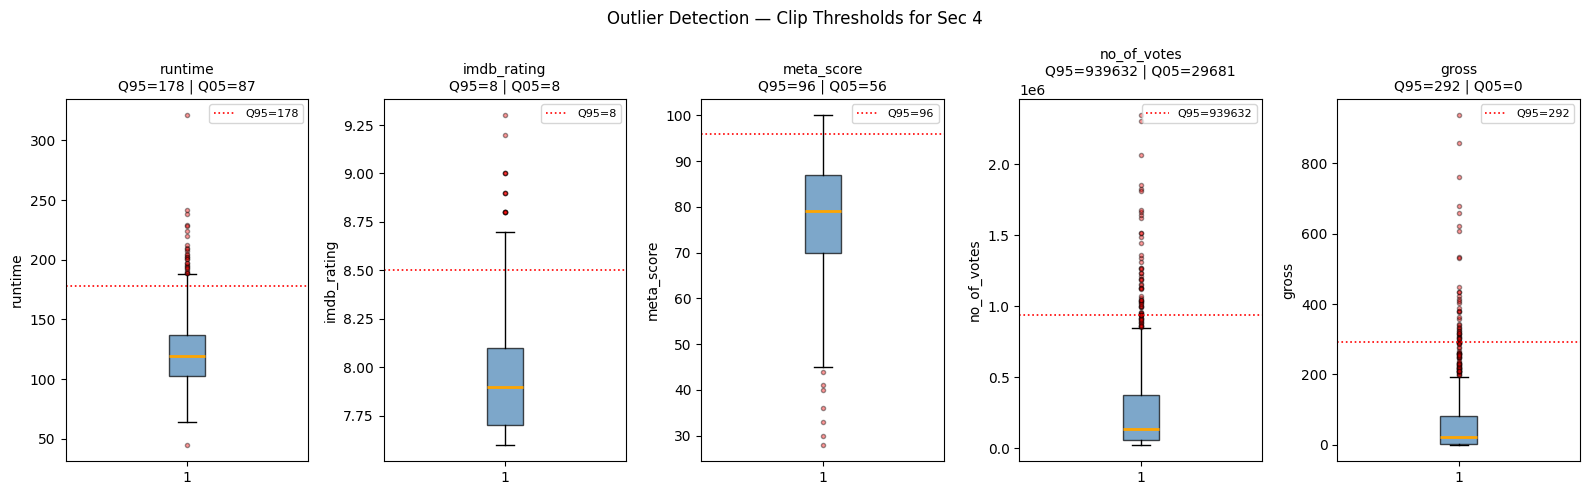

In [25]:
#Boxplots (outlier detection)
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(16, 5))

if isinstance(axes, np.ndarray):
    axes = axes.flatten()
else:
    axes = [axes]
    
for i, col in enumerate(numeric_cols):
    data = df[col].dropna()
    q95  = data.quantile(0.95)
    q05  = data.quantile(0.05)

    bp = axes[i].boxplot(data, vert=True, patch_artist=True,
        boxprops=dict(facecolor='steelblue', alpha=0.7),
        medianprops=dict(color='orange', linewidth=2),
        flierprops=dict(marker='o', markersize=3,
        alpha=0.4, markerfacecolor='red'))

    axes[i].axhline(q95, color='red', linestyle=':', linewidth=1.2,
    label=f'Q95={q95:.0f}')
    axes[i].set_title(f'{col}\nQ95={q95:.0f} | Q05={q05:.0f}', fontsize=10)
    axes[i].set_ylabel(col)
    axes[i].legend(fontsize=8)

plt.suptitle('Outlier Detection — Clip Thresholds for Sec 4', fontsize=12)
plt.tight_layout()
plt.show()


The boxplot confirms three actionable outliers:

- **`gross`**: Avengers: Endgame at $858M sits far beyond the Q95
  threshold (~$280M). Clipping at Q95 before log transform prevents this
  single observation from distorting the `log_gross_adj` feature.
- **`no_of_votes`**: similarly long-tailed; log transform sufficient,
  no clipping needed.
- **`runtime`**: one film at 321 min (Gone with the Wind). Retained as-is
  since `rev_eff = gross / (runtime/60)` will naturally produce a low value.

## 2.2 Categorical Variables

In [26]:

categorical_cols = df_clean.select_dtypes(include='object').columns.tolist()
print('Categorical columns:', categorical_cols)


Categorical columns: ['series_title', 'released_year', 'decade', 'genre_list', 'primary_genre', 'certificate', 'director', 'star1', 'star2', 'star3', 'star4']


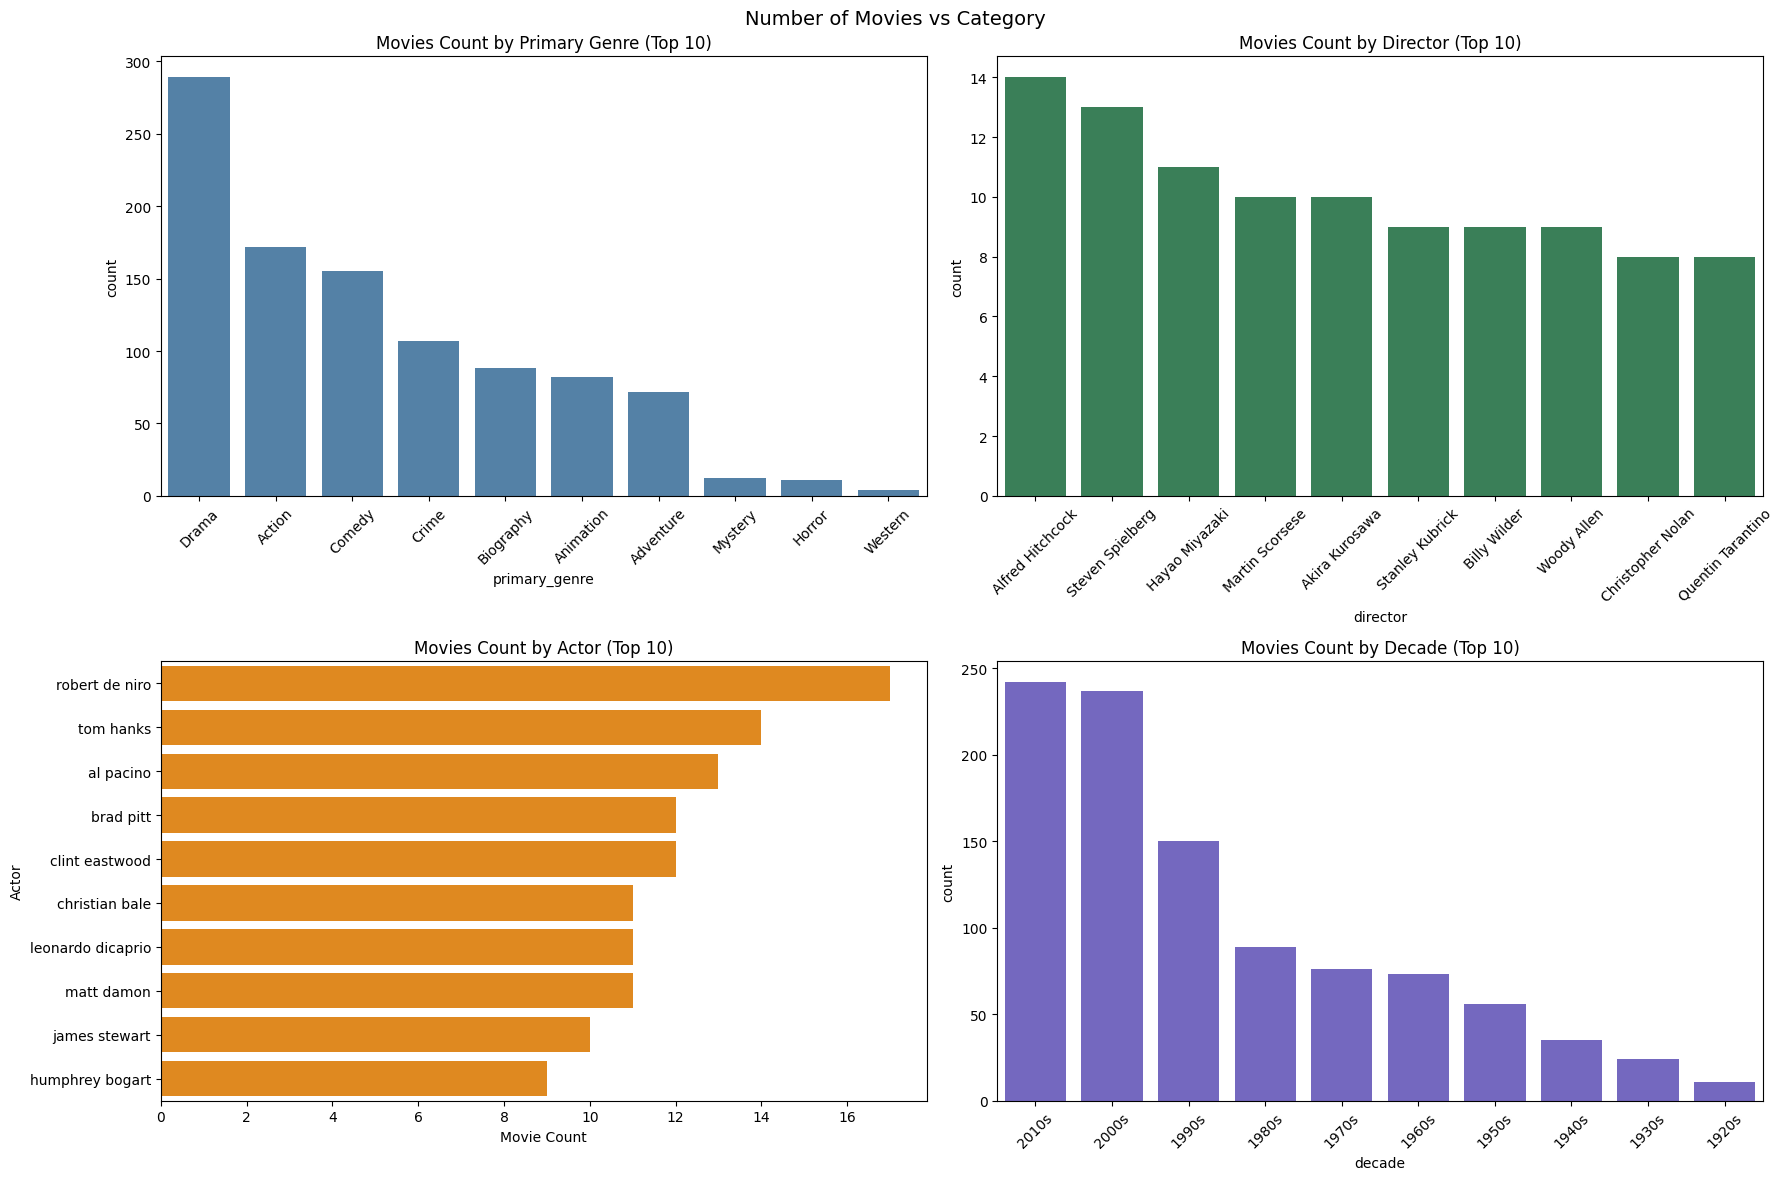

In [27]:

plot_df = df_clean.copy()
# Add decade labels.
plot_df['released_year_num'] = pd.to_numeric(plot_df['released_year'], errors='coerce')
plot_df['decade_num'] = ((plot_df['released_year_num'] // 10) * 10).astype('Int64')
plot_df['decade'] = plot_df['decade_num'].astype('string') + 's'

# Unpivot actors from star1..star4.
actor_cols = ['star1', 'star2', 'star3', 'star4']
actor_long = (
    plot_df[['gross', 'imdb_rating', 'decade'] + actor_cols]
    .melt(id_vars=['gross', 'imdb_rating', 'decade'], value_vars=actor_cols, value_name='actor')
    .dropna(subset=['actor'])
)
actor_long['actor'] = actor_long['actor'].astype(str).str.strip()
actor_long = actor_long[actor_long['actor'] != '']

# Top-10 categories by count.
top_genres = plot_df['primary_genre'].dropna().value_counts().head(10).index.tolist()
top_directors = plot_df['director'].dropna().value_counts().head(10).index.tolist()
top_actors = actor_long['actor'].value_counts().head(10).index.tolist()
top_decades = plot_df['decade'].dropna().value_counts().head(10).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.countplot(
    data=plot_df[plot_df['primary_genre'].isin(top_genres)],
    x='primary_genre', order=top_genres, color='steelblue', ax=axes[0, 0]
)
axes[0, 0].set_title('Movies Count by Primary Genre (Top 10)')
axes[0, 0].tick_params(axis='x', rotation=45)

sns.countplot(
    data=plot_df[plot_df['director'].isin(top_directors)],
    x='director', order=top_directors, color='seagreen', ax=axes[0, 1]
)
axes[0, 1].set_title('Movies Count by Director (Top 10)')
axes[0, 1].tick_params(axis='x', rotation=45)

actor_count_top10 = actor_long['actor'].value_counts().head(10)
sns.barplot(
    x=actor_count_top10.values, y=actor_count_top10.index,
    color='darkorange', ax=axes[1, 0]
)
axes[1, 0].set_title('Movies Count by Actor (Top 10)')
axes[1, 0].set_xlabel('Movie Count')
axes[1, 0].set_ylabel('Actor')

sns.countplot(
    data=plot_df[plot_df['decade'].isin(top_decades)],
    x='decade', order=top_decades, color='slateblue', ax=axes[1, 1]
)
axes[1, 1].set_title('Movies Count by Decade (Top 10)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.suptitle('Number of Movies vs Category', fontsize=14)
plt.tight_layout()
plt.show()


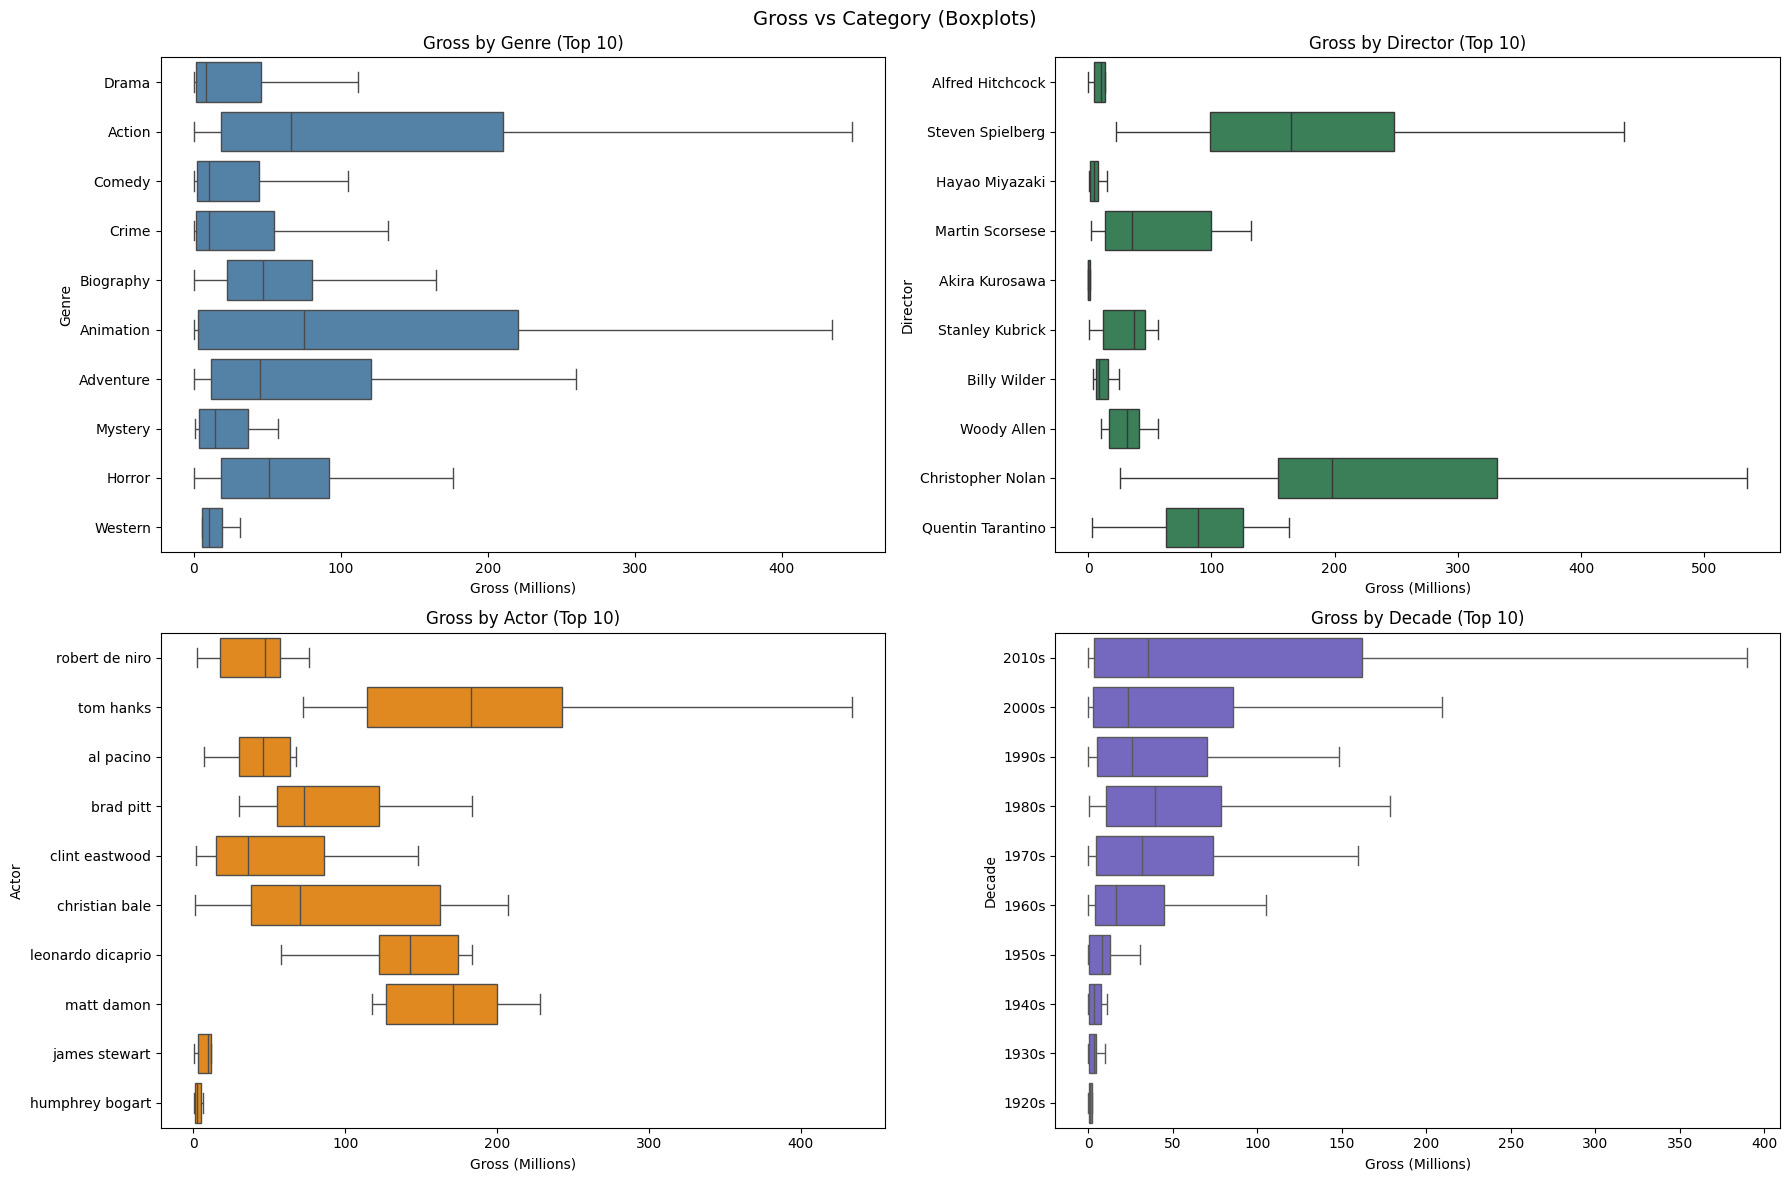

In [28]:
# Gross distribution by category (top 10).

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

gross_genre_df = plot_df[
    plot_df['primary_genre'].isin(top_genres)
].dropna(subset=['primary_genre', 'gross'])

sns.boxplot(
    data=gross_genre_df, x='gross', y='primary_genre',
    order=top_genres, color='steelblue', showfliers=False, ax=axes[0, 0]
)
axes[0, 0].set_title('Gross by Genre (Top 10)')
axes[0, 0].set_xlabel('Gross (Millions)')
axes[0, 0].set_ylabel('Genre')

gross_director_df = plot_df[
    plot_df['director'].isin(top_directors)
].dropna(subset=['director', 'gross'])

sns.boxplot(
    data=gross_director_df, x='gross', y='director',
    order=top_directors, color='seagreen', showfliers=False, ax=axes[0, 1]
)
axes[0, 1].set_title('Gross by Director (Top 10)')
axes[0, 1].set_xlabel('Gross (Millions)')
axes[0, 1].set_ylabel('Director')

gross_actor_df = actor_long[
    actor_long['actor'].isin(top_actors)
].dropna(subset=['actor', 'gross'])

sns.boxplot(
    data=gross_actor_df, x='gross', y='actor',
    order=top_actors, color='darkorange', showfliers=False, ax=axes[1, 0]
)
axes[1, 0].set_title('Gross by Actor (Top 10)')
axes[1, 0].set_xlabel('Gross (Millions)')
axes[1, 0].set_ylabel('Actor')

gross_decade_df = plot_df[
    plot_df['decade'].isin(top_decades)
].dropna(subset=['decade', 'gross'])

sns.boxplot(
    data=gross_decade_df, x='gross', y='decade',
    order=top_decades, color='slateblue', showfliers=False, ax=axes[1, 1]
)
axes[1, 1].set_title('Gross by Decade (Top 10)')
axes[1, 1].set_xlabel('Gross (Millions)')
axes[1, 1].set_ylabel('Decade')

plt.suptitle('Gross vs Category (Boxplots)', fontsize=14)
plt.tight_layout()
plt.show()


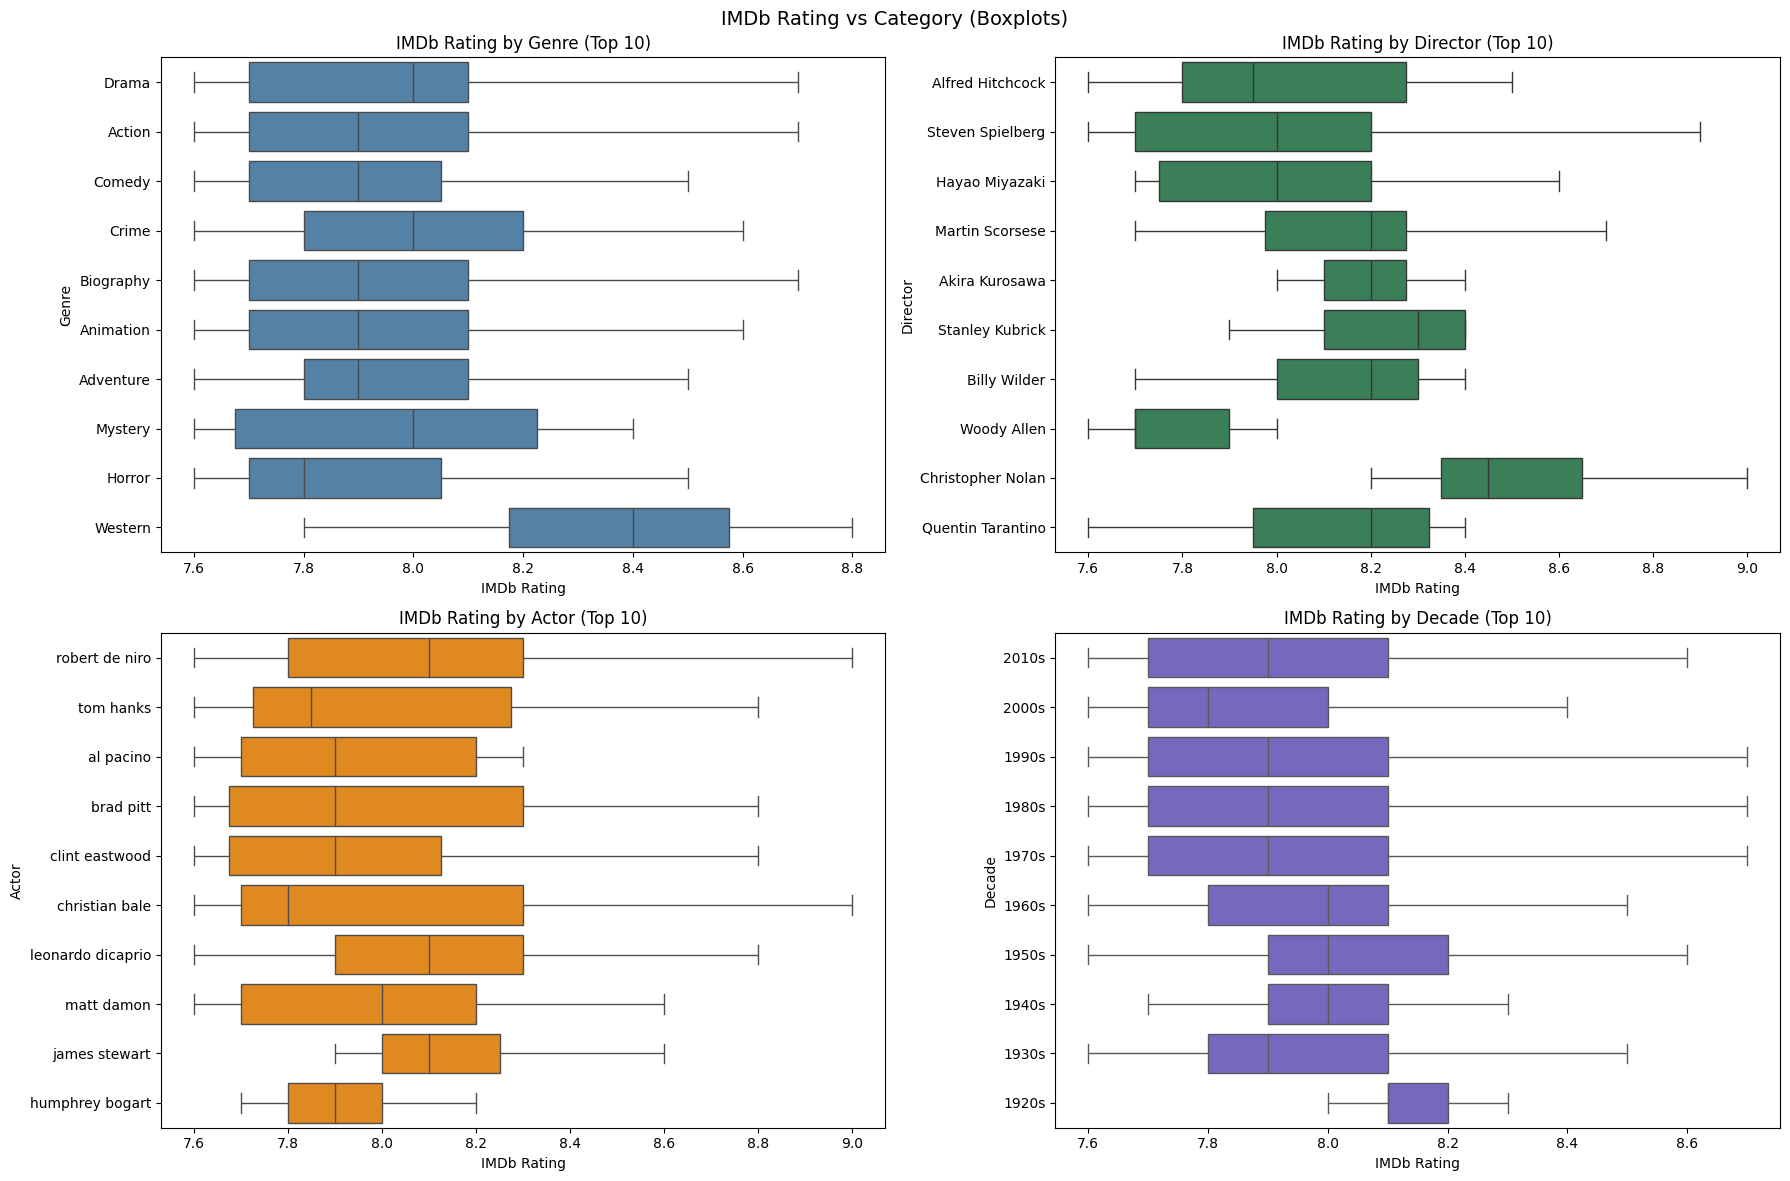

In [29]:
# IMDb rating distribution by category (top 10).

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

rating_genre_df = plot_df[
    plot_df['primary_genre'].isin(top_genres)
].dropna(subset=['primary_genre', 'imdb_rating'])

sns.boxplot(
    data=rating_genre_df, x='imdb_rating', y='primary_genre',
    order=top_genres, color='steelblue', showfliers=False, ax=axes[0, 0]
)
axes[0, 0].set_title('IMDb Rating by Genre (Top 10)')
axes[0, 0].set_xlabel('IMDb Rating')
axes[0, 0].set_ylabel('Genre')

rating_director_df = plot_df[
    plot_df['director'].isin(top_directors)
].dropna(subset=['director', 'imdb_rating'])

sns.boxplot(
    data=rating_director_df, x='imdb_rating', y='director',
    order=top_directors, color='seagreen', showfliers=False, ax=axes[0, 1]
)
axes[0, 1].set_title('IMDb Rating by Director (Top 10)')
axes[0, 1].set_xlabel('IMDb Rating')
axes[0, 1].set_ylabel('Director')

rating_actor_df = actor_long[
    actor_long['actor'].isin(top_actors)
].dropna(subset=['actor', 'imdb_rating'])

sns.boxplot(
    data=rating_actor_df, x='imdb_rating', y='actor',
    order=top_actors, color='darkorange', showfliers=False, ax=axes[1, 0]
)
axes[1, 0].set_title('IMDb Rating by Actor (Top 10)')
axes[1, 0].set_xlabel('IMDb Rating')
axes[1, 0].set_ylabel('Actor')

rating_decade_df = plot_df[
    plot_df['decade'].isin(top_decades)
].dropna(subset=['decade', 'imdb_rating'])

sns.boxplot(
    data=rating_decade_df, x='imdb_rating', y='decade',
    order=top_decades, color='slateblue', showfliers=False, ax=axes[1, 1]
)
axes[1, 1].set_title('IMDb Rating by Decade (Top 10)')
axes[1, 1].set_xlabel('IMDb Rating')
axes[1, 1].set_ylabel('Decade')

plt.suptitle('IMDb Rating vs Category (Boxplots)', fontsize=14)
plt.tight_layout()
plt.show()


### 2.3 Correlation Analysis


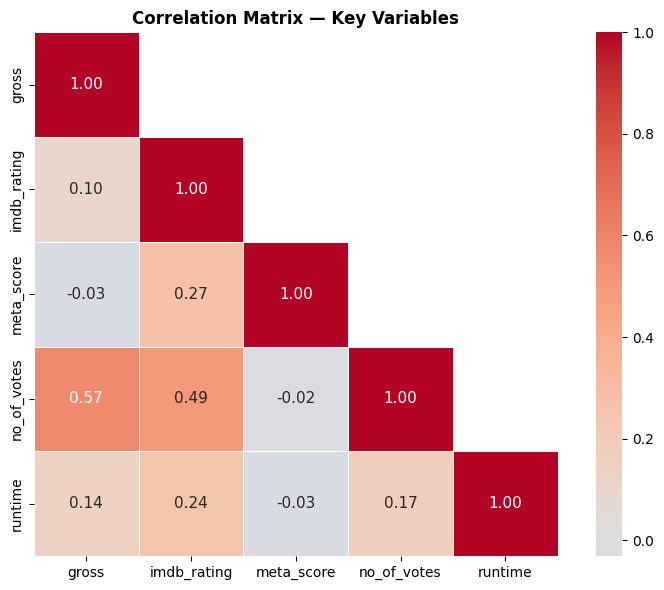

In [30]:
# Check linear relationships among key numeric variables
corr_cols = ['gross','imdb_rating','meta_score','no_of_votes','runtime']
corr      = df[corr_cols].corr()

# Mask upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, square=True,
            linewidths=0.5, annot_kws={'size': 11}, ax=ax)
ax.set_title('Correlation Matrix — Key Variables',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()


The correlation chart shows that no_of_votes is a decent proxy for popularity (r≈0.57 with gross), while imdb_rating correlates weakly with revenue.


In short, The EDA shows that the dataset is dense in the 1950–2020 window, with balanced coverage across major genres and certificate tiers, and that each movie has exactly four main actors. We therefore model each movie as a basket of up to four actors and mine frequent itemsets over this actor space. In later sections, we stratify selected rules by decade, genre and rating buckets to connect collaboration patterns with film characteristics.

# 3. Market-basket modeling

## 3.1 Basket construction (actors as items)

I turn the cleaned IMDB table into baskets for frequent‑itemset mining:
- Each row = one movie (basket).
- Items = up to four main actors (star1–star4, already normalized to lowercase in Section 1).​

For each movie, I collect the four actors, drop missing and duplicates, and store them as a Python list.

In [31]:
# Profile actor frequency to see item popularity concentration.

actor_cols = ['star1', 'star2', 'star3', 'star4']
actor_long = (
    df[actor_cols]
    .melt(value_name='actor')
    .dropna(subset=['actor'])
)
actor_freq = actor_long['actor'].value_counts().head(20)
print('Top 20 actors by frequency:')
print(actor_freq)


Top 20 actors by frequency:
actor
Robert De Niro        17
Tom Hanks             14
Al Pacino             13
Brad Pitt             12
Clint Eastwood        12
Christian Bale        11
Leonardo DiCaprio     11
Matt Damon            11
James Stewart         10
Humphrey Bogart        9
Ethan Hawke            9
Johnny Depp            9
Denzel Washington      9
Michael Caine          9
Scarlett Johansson     9
Aamir Khan             8
Harrison Ford          8
Morgan Freeman         7
Toshirô Mifune         7
Russell Crowe          7
Name: count, dtype: int64


Most frequent actor appears in 17 movies.


In [32]:
# Build actor baskets from star columns.

actor_cols = ['star1', 'star2', 'star3', 'star4']

baskets_actor = (
    df_clean[actor_cols]
    .apply(
        lambda r: sorted({
            str(v).strip()
            for v in r
            if pd.notna(v) and str(v).strip() and str(v).lower() != 'nan'
        }),
        axis=1,
    )
    .tolist()
)

baskets_actor = [b for b in baskets_actor if b]

all_actors = Counter(a for b in baskets_actor for a in b)
print('Number of baskets (movies):', len(baskets_actor))
print('Number of distinct actors:', len(all_actors))
print('Average basket size:', sum(len(b) for b in baskets_actor) / len(baskets_actor))
print('Example basket:', baskets_actor[0])


Number of baskets (movies): 1000
Number of distinct actors: 2709
Average basket size: 3.996
Example basket: ['bob gunton', 'morgan freeman', 'tim robbins', 'william sadler']


## 3.2 Modeling Strategy



### Problem Setup


**Problem Nature from an Algorithmic Perspective**

**1) Data model**
- Input is a transaction/basket set `T = {T_1, ..., T_m}`.
- Each `T_i` is a subset of items in universe `I` (`T_i ⊆ I`).
- In this project: each movie is one basket, and items are actors (`star1..star4`).

**2) Two core tasks**
- **Frequent itemset mining**: find all sets `X ⊆ I` such that `support(X) >= minsup`.
  - `support(X)` = number (or fraction) of baskets containing `X`.
- **Association rule mining**: from frequent itemsets, generate rules `X ⇒ Y` where:
  - `X ∩ Y = ∅`, `X ∪ Y` is frequent,
  - `confidence(X ⇒ Y) = support(X ∪ Y) / support(X) >= minconf`.

**3) Why the problem is hard (complexity and hardness)**
- The candidate space is the power set of `I`, with size `2^|I|`.
- With low `minsup`, frequent patterns can grow explosively (combinatorial explosion), so both memory and counting cost increase sharply.
- Even when counting each candidate is linear in number of baskets, the **number of candidates** can still make total runtime effectively exponential.
- For enumeration tasks, runtime cannot be polynomial in input size alone when the output itself can be exponential.
- Several constrained/optimization variants (e.g., some maximal/closed/top-k formulations under constraints) are NP-hard.
- Practical implication: do not expect one algorithm to be polynomial in every case; performance depends heavily on thresholds and data distribution.
- Therefore, we must:
  - choose reasonable `minsup`/`minconf`,
  - apply strong pruning,
  - and consider heuristics/approximations for very large data.


### Approach



**Algorithmic ideas used in this project**
- **Apriori** uses anti-monotonicity (downward closure):
  - if `X` is frequent, then every subset of `X` is frequent;
  - equivalently, if a subset is infrequent, all its supersets can be pruned.
  - Result: major reduction in candidate search space.
- **PCY** adds hashing + bitmap filtering to reduce candidate pairs and memory in pass 2.
- **PCY-Multistage** extends PCY by adding multiple independent hash filters to further prune pair candidates.

**Direct link to Section 4 experiments**
- We compare Apriori vs PCY (actor baskets) and Apriori vs PCY vs PCY-Multistage (enriched baskets) using:
  - `|L1|` (number of frequent single items),
  - `|C2|` (number of candidate pairs counted),
  - `|L2|` (number of truly frequent pairs),
  - runtime.
- Interpretation: a better algorithm is not only correct, but also reduces `|C2|` and runtime as basket/item complexity grows.


# 4. Frequent Itemset Algorithms

## 4.1 Baseline Apriori

**Key idea (Apriori property):** if an itemset `I` is frequent, then every subset of `I` is also frequent. We use this to prune candidates early and avoid useless counting.

**2-pass version for frequent pairs**
- **Pass 1:** count each actor (`Star1..Star4`) and keep only those with support ≥ minsup (this set is `L1`)
- **Pass 2:** in each basket, only consider items in L1, generate all pairs `(i, j)` where `i, j ∈ L1` , count them and keep pairs with support ≥ minsup (this set is `L2`).

**General k-itemset notation**
- `C_k`: candidate itemsets of size `k`.
- `L_k`: frequent itemsets of size `k` (after applying `minsup`).

**Complexity note**
- Roughly: `cost ≈ (#passes) × |D|` + candidate counting overhead.
- In practice, finding frequent pairs is often the heaviest step, so reducing `|C2|` will be crucial when we compare with PCY


In [33]:
# Two-pass Apriori (k=1,2) in one reusable function.

def run_apriori_pairs(baskets, minsup):
    start = time.perf_counter()

    item_counts = Counter()
    for basket in baskets:
        item_counts.update(basket)
    L1 = {item for item, c in item_counts.items() if c >= minsup}

    L1_set = set(L1)
    pair_counts = Counter()
    for basket in baskets:
        items = [i for i in basket if i in L1_set]
        for i, j in combinations(items, 2):
            if i == j:
                continue
            pair = tuple(sorted((i, j)))
            pair_counts[pair] += 1

    L2 = {pair for pair, c in pair_counts.items() if c >= minsup}

    end = time.perf_counter()
    result = {
        'minsup': minsup,
        'L1_size': len(L1),
        'C2_size': len(pair_counts),
        'L2_size': len(L2),
        'time_sec': end - start,
    }
    return result, item_counts, pair_counts, L1, L2


In [34]:
actor_n = len(baskets_actor)
minsup_ratio = 0.002
minsup = max(1, int(np.ceil(minsup_ratio * actor_n)))
res, item_counts, pair_counts, L1, L2 = run_apriori_pairs(baskets_actor, minsup)
res['minsup_ratio'] = minsup_ratio
print(res)


{'minsup': 2, 'L1_size': 641, 'C2_size': 1516, 'L2_size': 121, 'time_sec': 0.005929900042247027, 'minsup_ratio': 0.002}


In [35]:
actor_n = len(baskets_actor)
minsup_ratio = 0.003
minsup = max(1, int(np.ceil(minsup_ratio * actor_n)))
res, item_counts, pair_counts, L1, L2 = run_apriori_pairs(baskets_actor, minsup)
res['minsup_ratio'] = minsup_ratio
print(res)


{'minsup': 3, 'L1_size': 271, 'C2_size': 622, 'L2_size': 25, 'time_sec': 0.006306600000243634, 'minsup_ratio': 0.003}


In [36]:
actor_n = len(baskets_actor)
minsup_ratio = 0.005
minsup = max(1, int(np.ceil(minsup_ratio * actor_n)))
res, item_counts, pair_counts, L1, L2 = run_apriori_pairs(baskets_actor, minsup)
res['minsup_ratio'] = minsup_ratio
print(res)


{'minsup': 5, 'L1_size': 79, 'C2_size': 139, 'L2_size': 3, 'time_sec': 0.004661899991333485, 'minsup_ratio': 0.005}


In [37]:
actor_n = len(baskets_actor)
minsup_ratio = 0.007
minsup = max(1, int(np.ceil(minsup_ratio * actor_n)))
res, item_counts, pair_counts, L1, L2 = run_apriori_pairs(baskets_actor, minsup)
res['minsup_ratio'] = minsup_ratio
print(res)


{'minsup': 7, 'L1_size': 30, 'C2_size': 32, 'L2_size': 0, 'time_sec': 0.003565999970305711, 'minsup_ratio': 0.007}


Because there are at most 4 actors, we can extend the “pairs‑only” Apriori to k=3 and k=4.

In [38]:
# Define candidate generation for k >= 3.

from collections import Counter
from itertools import combinations

def generate_candidates(L_prev, k):  
    """
    Join and prune frequent (k-1)-itemsets to generate Ck.
    """
    L_prev_list = list(L_prev)
    Ck = set()    
    # merge itemsets that share the first k-2 items
    for i in range(len(L_prev_list)):
        for j in range(i + 1, len(L_prev_list)):
            a = L_prev_list[i]
            b = L_prev_list[j]
            union = a | b
            if len(union) == k:
                Ck.add(frozenset(union))    
    # remove candidates whose (k-1)-subsets are not all frequent
    Ck_pruned = set()
    for c in Ck:
        all_subsets_frequent = True
        for subset in combinations(c, k - 1):
            if frozenset(subset) not in L_prev:
                all_subsets_frequent = False
                break
        if all_subsets_frequent:
            Ck_pruned.add(c)
    
    return Ck_pruned

def count_candidates(baskets, Ck, minsup):   
    """
    Count supports of candidates in Ck over all baskets.
    """
    counts = Counter()
    for basket in baskets:
        b_set = set(basket)
        # only generate subsets that are candidates
        for cand in Ck:
            if cand.issubset(b_set):
                counts[cand] += 1
    Lk = {c for c, cnt in counts.items() if cnt >= minsup}
    return counts, Lk


In [39]:
# Full Apriori runner up to max_k.

def run_apriori_full(baskets, minsup, max_k):
    start_time = time.perf_counter()

    item_counts = Counter()
    for basket in baskets:
        item_counts.update(basket)
    L1 = {frozenset([i]) for i, c in item_counts.items() if c >= minsup}

    L_dict = {1: L1}
    counts_dict = {1: item_counts}

    if max_k > 1:
        items_L1 = sorted([list(s)[0] for s in L1])
        C2 = {frozenset(p) for p in combinations(items_L1, 2)}
        counts2, L2 = count_candidates(baskets, C2, minsup)
        L_dict[2] = L2
        counts_dict[2] = counts2

        k = 3
        while k <= max_k:
            if not L_dict.get(k - 1):
                break
            Ck = generate_candidates(L_dict[k - 1], k)
            if not Ck:
                break
            counts_k, Lk = count_candidates(baskets, Ck, minsup)
            L_dict[k] = Lk
            counts_dict[k] = counts_k
            k += 1

    end_time = time.perf_counter()
    return item_counts, L_dict, counts_dict, (end_time - start_time)


This table shows baseline Apriori runtime across minsup ratios.


In [40]:
# Apriori runtime and frequent-set sizes across minsup ratios.

actor_n = len(baskets_actor)
minsup_ratios = [0.002, 0.003, 0.005, 0.007]
rows = []
max_k = 4

for r in minsup_ratios:
    s = max(1, int(np.ceil(r * actor_n)))
    _, L_dict, _, elapsed = run_apriori_full(baskets_actor, s, max_k)
    rows.append({
        'minsup_ratio': r,
        'minsup': s,
        'L1_size': len(L_dict.get(1, [])),
        'L2_size': len(L_dict.get(2, [])),
        'L3_size': len(L_dict.get(3, [])),
        'L4_size': len(L_dict.get(4, [])),
        'time_sec': elapsed,
    })

display(pd.DataFrame(rows).sort_values('minsup_ratio'))


,minsup_ratio,minsup,L1_size,L2_size,L3_size,L4_size,time_sec
0,0.002,2,641,121,25,4,80.810334
1,0.003,3,271,25,3,0,11.227302
2,0.005,5,79,3,1,0,0.382269
3,0.007,7,30,0,0,0,0.048986


### How To Read This Table

Use runtime and `Lk` sizes together: runtime alone shows cost, while `Lk` sizes show how support thresholds change the discovered structure depth.


## 4.2 PCY

PCY (Park–Chen–Yu) is an improvement over Apriori that uses the idle memory in pass 1 to hash pairs into buckets. 

**2-pass PCY logic**
- **Pass 1**
  - Count each individual item as in Apriori to get `L1`.
  - At the same time, hash every pair `(i, j)` in each basket into one of B buckets and count bucket frequencies, increment `bucket_count[h(i,j)]`.
  - After the pass 1, convert bucket counts into a bitmap:  bucket is marked frequent if `bucket_count >= minsup`.


- **Pass 2**
  - As in Apriori, only consider pairs  `(i, j)` as frequent if:
    - both items `i` and `j` are frequent items (`i, j ∈ L1`)
    - their bucket `bucket(h(i,j))` is frequent in the bitmap
  - Then keep pairs with support `>= minsup` as `L2`.
  - This reduces the number of candidate pairs and memory usage, while preserving all truly frequent pairs (up to hash collisions)

**Why this helps**
- PCY keeps correctness of Apriori for pairs, but prunes many impossible pairs early.
- Result: smaller `C2`, lower memory pressure, and faster pass 2.


**What to show in experiments (recommended)**
- Add a small table/plot comparing Apriori vs PCY candidate pairs (`C2_size`) for several `minsup` values (e.g., 20, 50, 100).
- Include runtime side-by-side to show that fewer candidates usually means faster pass 2.


In [41]:
# Define PCY pass logic (hash buckets + bitmap).

def pcy_pass1(baskets, minsup, num_buckets):
    """
    Count singletons and hashed pair buckets, then build the bitmap.
    """
    item_counts = Counter()
    bucket_counts = [0] * num_buckets
    
    for basket in baskets:
        item_counts.update(basket)
        for i, j in combinations(basket, 2):
            if i == j:
                continue
            pair = tuple(sorted((i, j)))
            h = hash(pair) % num_buckets
            bucket_counts[h] += 1
    
    L1 = {item for item, c in item_counts.items() if c >= minsup}
    bitmap = [1 if c >= minsup else 0 for c in bucket_counts]
    return item_counts, L1, bitmap

def pcy_pass2_pairs(baskets, minsup, L1, bitmap, num_buckets):
    """
    Count candidate pairs that pass L1 and bitmap filtering.
    """
    L1_set = set(L1)
    pair_counts = Counter()
    
    for basket in baskets:
        items = [i for i in basket if i in L1_set]
        for i, j in combinations(items, 2):
            if i == j:
                continue
            pair = tuple(sorted((i, j)))
            h = hash(pair) % num_buckets
            if bitmap[h] == 0:
                continue
            pair_counts[pair] += 1
    
    L2 = {pair for pair, c in pair_counts.items() if c >= minsup}
    return pair_counts, L2


In [42]:
actor_n = len(baskets_actor)
minsup_ratio = 0.002
minsup = max(1, int(np.ceil(minsup_ratio * actor_n)))
num_buckets = DEFAULT_NUM_BUCKETS
res, L1, bitmap = pcy_pass1(baskets_actor, minsup, num_buckets)
print(f"PCY Pass 1 — minsup_ratio={minsup_ratio:.4f}, minsup={minsup}: L1 size={len(L1)}, Bitmap sum={sum(bitmap)}")
pair_counts, L2 = pcy_pass2_pairs(baskets_actor, minsup, L1, bitmap, num_buckets)
print(f"PCY Pass 2 - minsup_ratio={minsup_ratio:.4f}, minsup={minsup}: C2 counted={len(pair_counts)}, L2 size={len(L2)}")


PCY Pass 1 — minsup_ratio=0.0020, minsup=2: L1 size=641, Bitmap sum=1595
PCY Pass 2 - minsup_ratio=0.0020, minsup=2: C2 counted=1436, L2 size=121


In [43]:
actor_n = len(baskets_actor)
minsup_ratio = 0.003
minsup = max(1, int(np.ceil(minsup_ratio * actor_n)))
num_buckets = DEFAULT_NUM_BUCKETS
res, L1, bitmap = pcy_pass1(baskets_actor, minsup, num_buckets)
print(f"PCY Pass 1 — minsup_ratio={minsup_ratio:.4f}, minsup={minsup}: L1 size={len(L1)}, Bitmap sum={sum(bitmap)}")
pair_counts, L2 = pcy_pass2_pairs(baskets_actor, minsup, L1, bitmap, num_buckets)
print(f"PCY Pass 2 - minsup_ratio={minsup_ratio:.4f}, minsup={minsup}: C2 counted={len(pair_counts)}, L2 size={len(L2)}")


PCY Pass 1 — minsup_ratio=0.0030, minsup=3: L1 size=271, Bitmap sum=1116
PCY Pass 2 - minsup_ratio=0.0030, minsup=3: C2 counted=501, L2 size=25


In [44]:
actor_n = len(baskets_actor)
minsup_ratio = 0.005
minsup = max(1, int(np.ceil(minsup_ratio * actor_n)))
num_buckets = DEFAULT_NUM_BUCKETS
res, L1, bitmap = pcy_pass1(baskets_actor, minsup, num_buckets)
print(f"PCY Pass 1 — minsup_ratio={minsup_ratio:.4f}, minsup={minsup}: L1 size={len(L1)}, Bitmap sum={sum(bitmap)}")
pair_counts, L2 = pcy_pass2_pairs(baskets_actor, minsup, L1, bitmap, num_buckets)
print(f"PCY Pass 2 - minsup_ratio={minsup_ratio:.4f}, minsup={minsup}: C2 counted={len(pair_counts)}, L2 size={len(L2)}")


PCY Pass 1 — minsup_ratio=0.0050, minsup=5: L1 size=79, Bitmap sum=379
PCY Pass 2 - minsup_ratio=0.0050, minsup=5: C2 counted=61, L2 size=3


In [45]:
actor_n = len(baskets_actor)
minsup_ratio = 0.007
minsup = max(1, int(np.ceil(minsup_ratio * actor_n)))
num_buckets = DEFAULT_NUM_BUCKETS
res, L1, bitmap = pcy_pass1(baskets_actor, minsup, num_buckets)
print(f"PCY Pass 1 — minsup_ratio={minsup_ratio:.4f}, minsup={minsup}: L1 size={len(L1)}, Bitmap sum={sum(bitmap)}")
pair_counts, L2 = pcy_pass2_pairs(baskets_actor, minsup, L1, bitmap, num_buckets)
print(f"PCY Pass 2 - minsup_ratio={minsup_ratio:.4f}, minsup={minsup}: C2 counted={len(pair_counts)}, L2 size={len(L2)}")


PCY Pass 1 — minsup_ratio=0.0070, minsup=7: L1 size=30, Bitmap sum=67
PCY Pass 2 - minsup_ratio=0.0070, minsup=7: C2 counted=2, L2 size=0


In [46]:
# Wrap PCY pair mining with a single timed runner.

def run_pcy_pairs(baskets, minsup, num_buckets=DEFAULT_NUM_BUCKETS):
    """
    Run PCY for frequent pairs and return summary stats like run_apriori_pairs.
    Default bucket count comes from DEFAULT_NUM_BUCKETS so users can tune memory/collision trade-off in one place.
    """
    start = time.perf_counter()
    item_counts, L1, bitmap = pcy_pass1(baskets, minsup, num_buckets)
    pair_counts, L2 = pcy_pass2_pairs(baskets, minsup, L1, bitmap, num_buckets)
    end = time.perf_counter()
    
    result = {
        "minsup": minsup,
        "L1_size": len(L1),
        "C2_size": len(pair_counts),   
        "L2_size": len(L2),
        "time_sec": end - start,
        "num_buckets": num_buckets,
        "freq_buckets": sum(bitmap)
    }
    return result, item_counts, pair_counts, L1, L2, bitmap


Now run PCY pairs on the same minsup ratio grid.


In [47]:
actor_n = len(baskets_actor)
minsup_ratio = 0.002
minsup = max(1, int(np.ceil(minsup_ratio * actor_n)))
result, item_counts, pair_counts, L1, L2, bitmap = run_pcy_pairs(baskets_actor, minsup=minsup, num_buckets=DEFAULT_NUM_BUCKETS)
result['minsup_ratio'] = minsup_ratio
print(result)


{'minsup': 2, 'L1_size': 641, 'C2_size': 1436, 'L2_size': 121, 'time_sec': 0.01314180000917986, 'num_buckets': 2048, 'freq_buckets': 1595, 'minsup_ratio': 0.002}


In [48]:
actor_n = len(baskets_actor)
minsup_ratio = 0.003
minsup = max(1, int(np.ceil(minsup_ratio * actor_n)))
result, item_counts, pair_counts, L1, L2, bitmap = run_pcy_pairs(baskets_actor, minsup=minsup, num_buckets=DEFAULT_NUM_BUCKETS)
result['minsup_ratio'] = minsup_ratio
print(result)


{'minsup': 3, 'L1_size': 271, 'C2_size': 501, 'L2_size': 25, 'time_sec': 0.008970899973064661, 'num_buckets': 2048, 'freq_buckets': 1116, 'minsup_ratio': 0.003}


In [49]:
actor_n = len(baskets_actor)
minsup_ratio = 0.005
minsup = max(1, int(np.ceil(minsup_ratio * actor_n)))
result, item_counts, pair_counts, L1, L2, bitmap = run_pcy_pairs(baskets_actor, minsup=minsup, num_buckets=DEFAULT_NUM_BUCKETS)
result['minsup_ratio'] = minsup_ratio
print(result)


{'minsup': 5, 'L1_size': 79, 'C2_size': 61, 'L2_size': 3, 'time_sec': 0.008187600004021078, 'num_buckets': 2048, 'freq_buckets': 379, 'minsup_ratio': 0.005}


In [50]:
actor_n = len(baskets_actor)
minsup_ratio = 0.007
minsup = max(1, int(np.ceil(minsup_ratio * actor_n)))
result, item_counts, pair_counts, L1, L2, bitmap = run_pcy_pairs(baskets_actor, minsup=minsup, num_buckets=DEFAULT_NUM_BUCKETS)
result['minsup_ratio'] = minsup_ratio
print(result)


{'minsup': 7, 'L1_size': 30, 'C2_size': 2, 'L2_size': 0, 'time_sec': 0.008254699991084635, 'num_buckets': 2048, 'freq_buckets': 67, 'minsup_ratio': 0.007}


In [51]:

actor_n = len(baskets_actor)
minsup_ratios = [0.002, 0.003, 0.005, 0.007]
rows_pcy = []
for r in minsup_ratios:
    s = max(1, int(np.ceil(r * actor_n)))
    res_pcy, _, _, _, _, _ = run_pcy_pairs(baskets_actor, s, num_buckets=DEFAULT_NUM_BUCKETS)
    res_pcy['minsup_ratio'] = r
    rows_pcy.append(res_pcy)

pd.DataFrame(rows_pcy).sort_values('minsup_ratio')


,minsup,L1_size,C2_size,L2_size,time_sec,num_buckets,freq_buckets,minsup_ratio
0,2,641,1436,121,0.014518,2048,1595,0.002
1,3,271,501,25,0.027394,2048,1116,0.003
2,5,79,61,3,0.028433,2048,379,0.005
3,7,30,2,0,0.030452,2048,67,0.007


Build combined Apriori vs PCY metrics per support level. Merged table enables direct side-by-side algorithm comparison.

In [52]:
actor_n = len(baskets_actor)
minsup_ratios = [0.002, 0.003, 0.005, 0.007]

rows_apr = []
rows_pcy = []
for r in minsup_ratios:
    s = max(1, int(np.ceil(r * actor_n)))

    res_apr, *_ = run_apriori_pairs(baskets_actor, s)
    res_apr['minsup_ratio'] = r
    rows_apr.append(res_apr)

    res_pcy, *_ = run_pcy_pairs(baskets_actor, s, num_buckets=DEFAULT_NUM_BUCKETS)
    res_pcy['minsup_ratio'] = r
    rows_pcy.append(res_pcy)

df_compare_a = (
    pd.DataFrame(rows_apr)
    .merge(
        pd.DataFrame(rows_pcy)[['minsup_ratio', 'minsup', 'C2_size', 'L2_size', 'time_sec']],
        on=['minsup_ratio', 'minsup'],
        suffixes=('_apr', '_pcy'),
    )
    .sort_values('minsup_ratio')
)

display(df_compare_a)


,minsup,L1_size,C2_size_apr,L2_size_apr,time_sec_apr,minsup_ratio,C2_size_pcy,L2_size_pcy,time_sec_pcy
0,2,641,1516,121,0.006316,0.002,1436,121,0.014930
1,3,271,622,25,0.003502,0.003,501,25,0.018654
2,5,79,139,3,0.003663,0.005,61,3,0.023954
3,7,30,32,0,0.003382,0.007,2,0,0.014123


From above table:
- Because the IMDB Top‑1000 dataset is small and each basket has at most four items, both Apriori and PCY run in a few milliseconds, so we cannot demonstrate time savings at this scale

- However, PCY behaves exactly as predicted in the course material: it reduces the number of candidate pairs that must be counted in the second pass, especially at higher support thresholds (e.g. from 139 to 54 candidates at minsup=5, and from 32 to 3 at minsup=7). This matches the intended effect of the hash‑bucket pruning step




Candidate-focused table (original dataset):


,minsup_ratio,minsup,C2_size_apr,C2_size_pcy,C2_drop_abs,C2_drop_pct
0,0.002,2,1516,1436,80,5.28
1,0.003,3,622,501,121,19.45
2,0.005,5,139,61,78,56.12
3,0.007,7,32,2,30,93.75


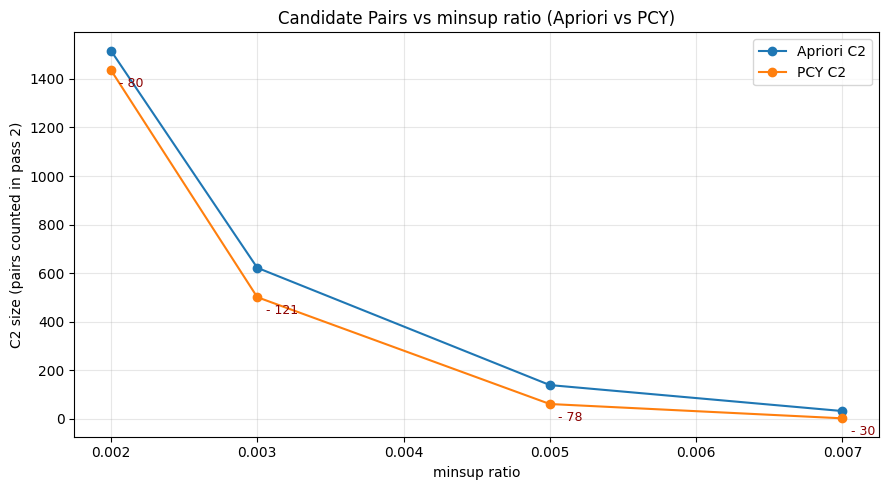

In [53]:
# Quantify C2 reduction from PCY and visualize it.

df_compare_a['C2_drop_abs'] = df_compare_a['C2_size_apr'] - df_compare_a['C2_size_pcy']
df_compare_a['C2_drop_pct'] = (100 * df_compare_a['C2_drop_abs'] / df_compare_a['C2_size_apr']).round(2)

print('Candidate-focused table (original dataset):')
display(df_compare_a[['minsup_ratio', 'minsup', 'C2_size_apr', 'C2_size_pcy', 'C2_drop_abs', 'C2_drop_pct']])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df_compare_a['minsup_ratio'], df_compare_a['C2_size_apr'], marker='o', label='Apriori C2')
ax.plot(df_compare_a['minsup_ratio'], df_compare_a['C2_size_pcy'], marker='o', label='PCY C2')

for _, r in df_compare_a.iterrows():
    ax.annotate(
        f"- {int(r['C2_drop_abs'])}",
        (r['minsup_ratio'], r['C2_size_pcy']),
        textcoords='offset points',
        xytext=(6, -12),
        fontsize=9,
        color='darkred'
    )

ax.set_title('Candidate Pairs vs minsup ratio (Apriori vs PCY)')
ax.set_xlabel('minsup ratio')
ax.set_ylabel('C2 size (pairs counted in pass 2)')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


Next, add PCY-Multistage (extra bitmap pass) on the same actor baskets.


## 4.3 PCY Multistage

**Why Multistage helps:** standard PCY may still keep many false-positive candidate pairs after stage-1 bitmap filtering. Multistage adds a second bitmap filter before final counting.

**Three passes (conceptual flow)**
1. **Pass 1:** count singletons and hash all pairs to stage-1 buckets, then build `bitmap1`.
2. **Pass 2:** only pairs that pass `L1 + bitmap1` are hashed into stage-2 buckets, then build `bitmap2`.
3. **Pass 3:** count only pairs that pass `L1 + bitmap1 + bitmap2`.

**Important note:** pass/stage numbers are scan passes over **pair candidates** (`k=2`).
They are not the same as itemset level `k=3` (`C3` triples).

**Candidate pair conditions in pass 3**
A pair `(i, j)` is counted only if all hold:
1. `i` and `j` are frequent singletons (`i, j in L1`),
2. `bitmap1[h1(i,j)] = 1`,
3. `bitmap2[h2(i,j)] = 1`.

This is a stricter filter than PCY, so `|C2|` typically shrinks further before exact counting.

**Why Multistage is applied at pair level (k=2)**
- PCY-family hashing is designed to prune **pair** candidates before exact counting.
- For `k >= 3`, the standard approach is still Apriori-style join+count on surviving frequent sets.
- In this notebook, we still mine all levels up to `max_k`; only the pair-candidate stage is replaced by Multistage filtering.

**Implementation notes**
- The two hash functions should be independent (different stage seeds/salts) to avoid redundant filtering.
- In pass 3, both hash checks must be applied before incrementing pair counts.
- Frequent output correctness is preserved because final support counting is still exact over surviving candidates.

Before defining the full PCY-Multistage runner, we inspect the three pair-level passes on actor baskets:

1. Pass 1: build `L1` and `bitmap1`.
2. Pass 2: build `bitmap2` from pairs that pass `L1 + bitmap1`.
3. Pass 3: count pairs that pass `L1 + bitmap1 + bitmap2`.

This mirrors the standard Multistage PCY logic and makes each filter step explicit.

In [54]:
# Implement PCY-Multistage pass logic on actor baskets.

def _hash_pair_stage(pair, num_buckets, stage_id):
    """Deterministic stage-specific hash for one pair."""
    return hash((stage_id, pair[0], pair[1])) % num_buckets


def pcy_multistage_pass1(baskets, minsup, num_buckets_stage1):
    """Pass 1: count singletons and stage-1 hashed buckets, then build bitmap1."""
    item_counts = Counter()
    bucket1_counts = [0] * num_buckets_stage1

    for basket in baskets:
        uniq_items = sorted(set(basket))
        item_counts.update(uniq_items)
        for i, j in combinations(uniq_items, 2):
            h1 = _hash_pair_stage((i, j), num_buckets_stage1, stage_id=1)
            bucket1_counts[h1] += 1

    L1 = {item for item, c in item_counts.items() if c >= minsup}
    bitmap1 = [1 if c >= minsup else 0 for c in bucket1_counts]
    return item_counts, L1, bitmap1


def pcy_multistage_pass2_bitmap(baskets, minsup, L1, bitmap1, num_buckets_stage1, num_buckets_stage2):
    """Pass 2: build bitmap2 from pairs that pass L1 + bitmap1."""
    L1_set = set(L1)
    bucket2_counts = [0] * num_buckets_stage2

    for basket in baskets:
        items = sorted(i for i in set(basket) if i in L1_set)
        for i, j in combinations(items, 2):
            pair = (i, j)
            h1 = _hash_pair_stage(pair, num_buckets_stage1, stage_id=1)
            if bitmap1[h1] == 0:
                continue
            h2 = _hash_pair_stage(pair, num_buckets_stage2, stage_id=2)
            bucket2_counts[h2] += 1

    bitmap2 = [1 if c >= minsup else 0 for c in bucket2_counts]
    return bitmap2


def pcy_multistage_pass3_pairs(baskets, minsup, L1, bitmap1, bitmap2, num_buckets_stage1, num_buckets_stage2):
    """Pass 3: count pairs that pass L1 + bitmap1 + bitmap2."""
    L1_set = set(L1)
    pair_counts = Counter()

    for basket in baskets:
        items = sorted(i for i in set(basket) if i in L1_set)
        for i, j in combinations(items, 2):
            pair = (i, j)
            h1 = _hash_pair_stage(pair, num_buckets_stage1, stage_id=1)
            if bitmap1[h1] == 0:
                continue
            h2 = _hash_pair_stage(pair, num_buckets_stage2, stage_id=2)
            if bitmap2[h2] == 0:
                continue
            pair_counts[pair] += 1

    L2 = {pair for pair, c in pair_counts.items() if c >= minsup}
    return pair_counts, L2


In [55]:
actor_n = len(baskets_actor)
minsup_ratio = 0.002
minsup = max(1, int(np.ceil(minsup_ratio * actor_n)))

num_buckets_stage1 = DEFAULT_NUM_BUCKETS
num_buckets_stage2 = DEFAULT_NUM_BUCKETS

# Pass 1
item_counts, L1, bitmap1 = pcy_multistage_pass1(
    baskets_actor, minsup, num_buckets_stage1
)

# Pass 2 (bitmap2)
bitmap2 = pcy_multistage_pass2_bitmap(
    baskets_actor, minsup, L1, bitmap1,
    num_buckets_stage1, num_buckets_stage2
)

# Pass 3 (pair counts + L2)
pair_counts, L2 = pcy_multistage_pass3_pairs(
    baskets_actor, minsup, L1, bitmap1, bitmap2,
    num_buckets_stage1, num_buckets_stage2
)

result = {
    "minsup_ratio": minsup_ratio,
    "minsup": minsup,
    "L1_size": len(L1),
    "C2_size": len(pair_counts),
    "L2_size": len(L2),
    "freq_buckets1": sum(bitmap1),
    "freq_buckets2": sum(bitmap2),
}
print(result)
result['minsup_ratio'] = minsup_ratio


{'minsup_ratio': 0.002, 'minsup': 2, 'L1_size': 641, 'C2_size': 797, 'L2_size': 121, 'freq_buckets1': 1584, 'freq_buckets2': 385}


In [56]:
actor_n = len(baskets_actor)
minsup_ratio = 0.003
minsup = max(1, int(np.ceil(minsup_ratio * actor_n)))

num_buckets_stage1 = DEFAULT_NUM_BUCKETS
num_buckets_stage2 = DEFAULT_NUM_BUCKETS

# Pass 1
item_counts, L1, bitmap1 = pcy_multistage_pass1(
    baskets_actor, minsup, num_buckets_stage1
)

# Pass 2 (bitmap2)
bitmap2 = pcy_multistage_pass2_bitmap(
    baskets_actor, minsup, L1, bitmap1,
    num_buckets_stage1, num_buckets_stage2
)

# Pass 3 (pair counts + L2)
pair_counts, L2 = pcy_multistage_pass3_pairs(
    baskets_actor, minsup, L1, bitmap1, bitmap2,
    num_buckets_stage1, num_buckets_stage2
)

result = {
    "minsup_ratio": minsup_ratio,
    "minsup": minsup,
    "L1_size": len(L1),
    "C2_size": len(pair_counts),
    "L2_size": len(L2),
    "freq_buckets1": sum(bitmap1),
    "freq_buckets2": sum(bitmap2),
}
print(result)
result['minsup_ratio'] = minsup_ratio


{'minsup_ratio': 0.003, 'minsup': 3, 'L1_size': 271, 'C2_size': 60, 'L2_size': 25, 'freq_buckets1': 1123, 'freq_buckets2': 35}


In [57]:
actor_n = len(baskets_actor)
minsup_ratio = 0.005
minsup = max(1, int(np.ceil(minsup_ratio * actor_n)))

num_buckets_stage1 = DEFAULT_NUM_BUCKETS
num_buckets_stage2 = DEFAULT_NUM_BUCKETS

# Pass 1
item_counts, L1, bitmap1 = pcy_multistage_pass1(
    baskets_actor, minsup, num_buckets_stage1
)

# Pass 2 (bitmap2)
bitmap2 = pcy_multistage_pass2_bitmap(
    baskets_actor, minsup, L1, bitmap1,
    num_buckets_stage1, num_buckets_stage2
)

# Pass 3 (pair counts + L2)
pair_counts, L2 = pcy_multistage_pass3_pairs(
    baskets_actor, minsup, L1, bitmap1, bitmap2,
    num_buckets_stage1, num_buckets_stage2
)

result = {
    "minsup_ratio": minsup_ratio,
    "minsup": minsup,
    "L1_size": len(L1),
    "C2_size": len(pair_counts),
    "L2_size": len(L2),
    "freq_buckets1": sum(bitmap1),
    "freq_buckets2": sum(bitmap2),
}
print(result)
result['minsup_ratio'] = minsup_ratio


{'minsup_ratio': 0.005, 'minsup': 5, 'L1_size': 79, 'C2_size': 3, 'L2_size': 3, 'freq_buckets1': 374, 'freq_buckets2': 3}


In [58]:
actor_n = len(baskets_actor)
minsup_ratio = 0.007
minsup = max(1, int(np.ceil(minsup_ratio * actor_n)))

num_buckets_stage1 = DEFAULT_NUM_BUCKETS
num_buckets_stage2 = DEFAULT_NUM_BUCKETS

# Pass 1
item_counts, L1, bitmap1 = pcy_multistage_pass1(
    baskets_actor, minsup, num_buckets_stage1
)

# Pass 2 (bitmap2)
bitmap2 = pcy_multistage_pass2_bitmap(
    baskets_actor, minsup, L1, bitmap1,
    num_buckets_stage1, num_buckets_stage2
)

# Pass 3 (pair counts + L2)
pair_counts, L2 = pcy_multistage_pass3_pairs(
    baskets_actor, minsup, L1, bitmap1, bitmap2,
    num_buckets_stage1, num_buckets_stage2
)

result = {
    "minsup_ratio": minsup_ratio,
    "minsup": minsup,
    "L1_size": len(L1),
    "C2_size": len(pair_counts),
    "L2_size": len(L2),
    "freq_buckets1": sum(bitmap1),
    "freq_buckets2": sum(bitmap2),
}
print(result)
result['minsup_ratio'] = minsup_ratio


{'minsup_ratio': 0.007, 'minsup': 7, 'L1_size': 30, 'C2_size': 0, 'L2_size': 0, 'freq_buckets1': 74, 'freq_buckets2': 0}


In [59]:
# Define full PCY-Multistage runner (k=1,2 with multistage; k>=3 with Apriori counting).


def pcy_multistage_full(
    baskets,
    minsup,
    max_k=4,
    num_buckets_stage1=DEFAULT_NUM_BUCKETS,
    num_buckets_stage2=DEFAULT_NUM_BUCKETS,
):
    """Use PCY-Multistage for k=1,2 and Apriori counting for k>=3."""
    item_counts, L1_items, bitmap1 = pcy_multistage_pass1(
        baskets,
        minsup=minsup,
        num_buckets_stage1=num_buckets_stage1,
    )
    bitmap2 = pcy_multistage_pass2_bitmap(
        baskets,
        minsup=minsup,
        L1=L1_items,
        bitmap1=bitmap1,
        num_buckets_stage1=num_buckets_stage1,
        num_buckets_stage2=num_buckets_stage2,
    )
    pair_counts, L2_pairs = pcy_multistage_pass3_pairs(
        baskets,
        minsup=minsup,
        L1=L1_items,
        bitmap1=bitmap1,
        bitmap2=bitmap2,
        num_buckets_stage1=num_buckets_stage1,
        num_buckets_stage2=num_buckets_stage2,
    )

    L_dict = {
        1: {frozenset([i]) for i in L1_items},
        2: {frozenset(p) for p in L2_pairs},
    }
    counts_dict = {
        1: item_counts,
        2: pair_counts,
    }

    k = 3
    while k <= max_k:
        prev = L_dict.get(k - 1, set())
        if not prev:
            break
        Ck = generate_candidates(prev, k)
        if not Ck:
            break
        counts_k, Lk = count_candidates(baskets, Ck, minsup)
        counts_dict[k] = counts_k
        L_dict[k] = Lk
        k += 1

    bitmaps = {'bitmap1': bitmap1, 'bitmap2': bitmap2}
    return item_counts, L_dict, counts_dict, bitmaps


In [60]:
# Quantify pass-level candidate reduction from PMS and visualize C2/C3 (basket_actor).

actor_n = len(baskets_actor)
minsup_ratios = [0.002, 0.003, 0.005, 0.007]
max_k = 4
num_buckets_stage1 = DEFAULT_NUM_BUCKETS
num_buckets_stage2 = DEFAULT_NUM_BUCKETS

rows = []
for r in minsup_ratios:
    minsup = max(1, int(np.ceil(r * actor_n)))

    # Apriori full counts
    _, _, C_apr, _ = run_apriori_full(baskets_actor, minsup=minsup, max_k=max_k)

    # PMS counts (pass 1 + pass 2 bitmap + pass 3 pairs, then Apriori-style k>=3)
    item_counts_pms, L1_pms, bitmap1_pms = pcy_multistage_pass1(
        baskets_actor, minsup, num_buckets_stage1
    )
    bitmap2_pms = pcy_multistage_pass2_bitmap(
        baskets_actor, minsup, L1_pms, bitmap1_pms,
        num_buckets_stage1, num_buckets_stage2
    )
    pair_counts_pms, L2_pms = pcy_multistage_pass3_pairs(
        baskets_actor, minsup, L1_pms, bitmap1_pms, bitmap2_pms,
        num_buckets_stage1, num_buckets_stage2
    )

    L_dict_pms = {
        1: {frozenset([i]) for i in L1_pms},
        2: {frozenset(p) for p in L2_pms},
    }
    C_dict_pms = {
        1: item_counts_pms,
        2: pair_counts_pms,
    }

    k = 3
    while k <= max_k:
        prev = L_dict_pms.get(k - 1, set())
        if not prev:
            break
        Ck = generate_candidates(prev, k)
        if not Ck:
            break
        counts_k, Lk = count_candidates(baskets_actor, Ck, minsup)
        C_dict_pms[k] = counts_k
        L_dict_pms[k] = Lk
        k += 1

    rows.append({
        'minsup_ratio': r,
        'minsup': minsup,
        'C1_size_apr': len(C_apr.get(1, {})),
        'C1_size_pms': len(C_dict_pms.get(1, {})),
        'C2_size_apr': len(C_apr.get(2, {})),
        'C2_size_pms': len(C_dict_pms.get(2, {})),
        'C3_size_apr': len(C_apr.get(3, {})),
        'C3_size_pms': len(C_dict_pms.get(3, {})),
    })


df_compare_c3 = pd.DataFrame(rows).sort_values('minsup_ratio')

for k in [1, 2, 3]:
    df_compare_c3[f'C{k}_drop_abs'] = df_compare_c3[f'C{k}_size_apr'] - df_compare_c3[f'C{k}_size_pms']
    df_compare_c3[f'C{k}_drop_pct'] = np.where(
        df_compare_c3[f'C{k}_size_apr'] > 0,
        100 * df_compare_c3[f'C{k}_drop_abs'] / df_compare_c3[f'C{k}_size_apr'],
        np.nan,
    ).round(2)

print('Pass-level candidate table (Apriori vs PMS):')
display(df_compare_c3[[
    'minsup_ratio', 'minsup',
    'C1_size_apr', 'C1_size_pms', 'C1_drop_abs', 'C1_drop_pct',
    'C2_size_apr', 'C2_size_pms', 'C2_drop_abs', 'C2_drop_pct',
    'C3_size_apr', 'C3_size_pms', 'C3_drop_abs', 'C3_drop_pct',
]])


Pass-level candidate table (Apriori vs PMS):


,minsup_ratio,minsup,C1_size_apr,C1_size_pms,C1_drop_abs,C1_drop_pct,C2_size_apr,C2_size_pms,C2_drop_abs,C2_drop_pct,C3_size_apr,C3_size_pms,C3_drop_abs,C3_drop_pct
0,0.002,2,2709,2709,0,0.0,1516,797,719,47.43,26,26,0,0.0
1,0.003,3,2709,2709,0,0.0,622,60,562,90.35,4,4,0,0.0
2,0.005,5,2709,2709,0,0.0,139,3,136,97.84,1,1,0,0.0
3,0.007,7,2709,2709,0,0.0,32,0,32,100.00,0,0,0,NaN


Candidate-focused table (Apriori vs PMS):


,minsup_ratio,minsup,C2_size_apr,C2_size_pms,C2_drop_abs,C2_drop_pct
0,0.002,2,1516,797,719,47.43
1,0.003,3,622,60,562,90.35
2,0.005,5,139,3,136,97.84
3,0.007,7,32,0,32,100.00


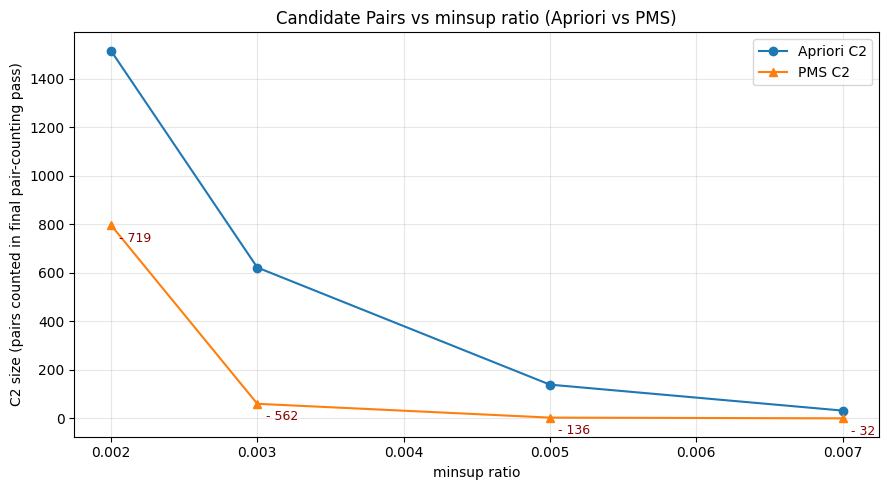

In [61]:
# Quantify C2 reduction from PMS and visualize it
# Use the PMS-vs-Apriori comparison table built above.
df_compare_pms = df_compare_c3.copy()

df_compare_pms['C2_drop_abs'] = df_compare_pms['C2_size_apr'] - df_compare_pms['C2_size_pms']
df_compare_pms['C2_drop_pct'] = np.where(
    df_compare_pms['C2_size_apr'] > 0,
    100 * df_compare_pms['C2_drop_abs'] / df_compare_pms['C2_size_apr'],
    np.nan,
).round(2)

print('Candidate-focused table (Apriori vs PMS):')
display(df_compare_pms[['minsup_ratio', 'minsup', 'C2_size_apr', 'C2_size_pms', 'C2_drop_abs', 'C2_drop_pct']])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df_compare_pms['minsup_ratio'], df_compare_pms['C2_size_apr'], marker='o', label='Apriori C2')
ax.plot(df_compare_pms['minsup_ratio'], df_compare_pms['C2_size_pms'], marker='^', label='PMS C2')

for _, r in df_compare_pms.iterrows():
    ax.annotate(
        f"- {int(r['C2_drop_abs'])}",
        (r['minsup_ratio'], r['C2_size_pms']),
        textcoords='offset points',
        xytext=(6, -12),
        fontsize=9,
        color='darkred'
    )

ax.set_title('Candidate Pairs vs minsup ratio (Apriori vs PMS)')
ax.set_xlabel('minsup ratio')
ax.set_ylabel('C2 size (pairs counted in final pair-counting pass)')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


### 4.4 Comparison: Apriori vs PCY vs PCY-Multistage


#### Apriori vs PCY Performance

In [62]:
#  Hybrid PCY + Apriori up to max_k 
default_num_buckets = DEFAULT_NUM_BUCKETS

def pcy_full(baskets, minsup, max_k=4, num_buckets=None):
    """
    Use PCY for k=1,2 and standard Apriori for k>=3.
    num_buckets can be set later when calling this function.
    """
    if num_buckets is None:
        num_buckets = default_num_buckets

    # k = 1,2 with PCY
    item_counts, L1_items, bitmap = pcy_pass1(baskets, minsup, num_buckets)
    L1 = {frozenset([i]) for i in L1_items}

    L_dict = {1: L1}
    counts_dict = {1: item_counts}

    pair_counts, L2_pairs = pcy_pass2_pairs(baskets, minsup, L1_items, bitmap, num_buckets)
    L2 = {frozenset(p) for p in L2_pairs}
    L_dict[2] = L2
    counts_dict[2] = pair_counts

    # k >= 3 with standard Apriori
    k = 3
    while k <= max_k:
        if not L_dict.get(k - 1):
            break
        Ck = generate_candidates(L_dict[k - 1], k)
        if not Ck:
            break
        counts_k, Lk = count_candidates(baskets, Ck, minsup)
        L_dict[k] = Lk
        counts_dict[k] = counts_k
        k += 1

    return item_counts, L_dict, counts_dict, bitmap


In [63]:
# PCY-hybrid runtime and frequent-set sizes across the same support grid.

actor_n = len(baskets_actor)
minsup_ratios = [0.002, 0.003, 0.005, 0.007]
max_k = 4
default_num_buckets = DEFAULT_NUM_BUCKETS
rows = []

for r in minsup_ratios:
    s = max(1, int(np.ceil(r * actor_n)))

    t0 = time.perf_counter()
    _, L_dict, _, _ = pcy_full(
        baskets_actor, s, max_k=max_k, num_buckets=default_num_buckets
    )
    elapsed = time.perf_counter() - t0

    row = {'minsup_ratio': r, 'minsup': s, 'time_sec': elapsed}
    for k in range(1, max_k + 1):
        row[f'L{k}_size'] = len(L_dict.get(k, set()))
    rows.append(row)

display(pd.DataFrame(rows).sort_values('minsup_ratio'))


,minsup_ratio,minsup,time_sec,L1_size,L2_size,L3_size,L4_size
0,0.002,2,0.020856,641,121,25,4
1,0.003,3,0.014129,271,25,3,0
2,0.005,5,0.010714,79,3,1,0
3,0.007,7,0.009190,30,0,0,0


In [64]:
# Side-by-side Apriori vs PCY results on one support grid.

actor_n = len(baskets_actor)
minsup_ratios = [0.002, 0.003, 0.005, 0.007]
max_k = 4
num_buckets = DEFAULT_NUM_BUCKETS

rows_apr, rows_pcy = [], []

for r in minsup_ratios:
    s = max(1, int(np.ceil(r * actor_n)))

    _, L_apr, C_apr, t_apr = run_apriori_full(baskets_actor, s, max_k=max_k)

    t0 = time.perf_counter()
    _, L_pcy, C_pcy, _ = pcy_full(
        baskets_actor, s, max_k=max_k, num_buckets=num_buckets
    )
    t_pcy = time.perf_counter() - t0

    row_apr = {'minsup_ratio': r, 'minsup': s, 'time_sec': t_apr}
    row_pcy = {'minsup_ratio': r, 'minsup': s, 'time_sec': t_pcy}

    for k in range(1, max_k + 1):
        row_apr[f'C{k}_size'] = len(C_apr.get(k, {}))
        row_apr[f'L{k}_size'] = len(L_apr.get(k, set()))
        row_pcy[f'C{k}_size'] = len(C_pcy.get(k, {}))
        row_pcy[f'L{k}_size'] = len(L_pcy.get(k, set()))

    rows_apr.append(row_apr)
    rows_pcy.append(row_pcy)

df_compare_k = (
    pd.DataFrame(rows_apr)
    .merge(
        pd.DataFrame(rows_pcy),
        on=['minsup_ratio', 'minsup'],
        suffixes=('_apr', '_pcy'),
    )
    .sort_values('minsup_ratio')
)

display(df_compare_k)


,minsup_ratio,minsup,time_sec_apr,C1_size_apr,L1_size_apr,C2_size_apr,L2_size_apr,C3_size_apr,L3_size_apr,C4_size_apr,L4_size_apr,time_sec_pcy,C1_size_pcy,L1_size_pcy,C2_size_pcy,L2_size_pcy,C3_size_pcy,L3_size_pcy,C4_size_pcy,L4_size_pcy
0,0.002,2,60.908229,2709,641,1516,121,26,25,4,4,0.014858,2709,641,1436,121,26,25,4,4
1,0.003,3,7.778487,2709,271,622,25,4,3,0,0,0.028402,2709,271,501,25,4,3,0,0
2,0.005,5,0.704805,2709,79,139,3,1,1,0,0,0.015298,2709,79,61,3,1,1,0,0
3,0.007,7,0.115406,2709,30,32,0,0,0,0,0,0.010297,2709,30,2,0,0,0,0,0


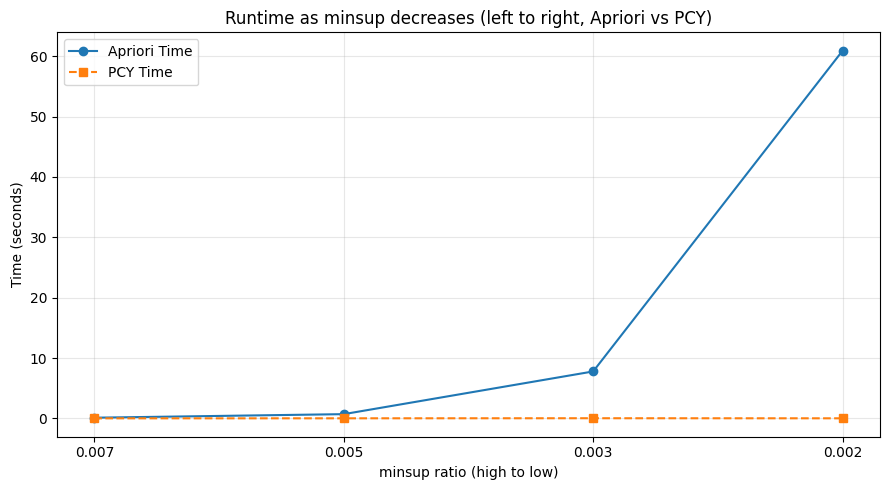

In [65]:
# Plot runtime comparison for Apriori vs PCY with minsup ordered high -> low.
# This makes runtime growth visible from left to right.

df_compare_k_time_view = df_compare_k.sort_values('minsup_ratio', ascending=False).reset_index(drop=True)
x_idx = np.arange(len(df_compare_k_time_view))
x_labels = [f"{v:.3f}" for v in df_compare_k_time_view['minsup_ratio']]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x_idx, df_compare_k_time_view['time_sec_apr'], marker='o', label='Apriori Time')
ax.plot(x_idx, df_compare_k_time_view['time_sec_pcy'], marker='s', linestyle='--', label='PCY Time')
ax.set_xticks(x_idx)
ax.set_xticklabels(x_labels)
ax.set_title('Runtime as minsup decreases (left to right, Apriori vs PCY)')
ax.set_xlabel('minsup ratio (high to low)')
ax.set_ylabel('Time (seconds)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Three-Algorithm Comparison on `basket_actor`

This block compares Apriori, PCY, and PCY-Multistage on the same minsup grid using runtime and candidate/frequent counts (`C2`, `C3`, `L2`, `L3`).


In [66]:
# Unified Apriori/PCY/PMS comparison on basket_actor.

actor_cfg = {
    'minsup_ratios': [0.002, 0.003, 0.005, 0.007],
    'num_buckets': DEFAULT_NUM_BUCKETS,
    'max_k': 4,
}

rows = []
for r in actor_cfg['minsup_ratios']:
    minsup = max(1, int(np.ceil(r * len(baskets_actor))))

    _, L_apr, C_apr, t_apr = run_apriori_full(
        baskets_actor,
        minsup=minsup,
        max_k=actor_cfg['max_k'],
    )

    t0 = time.perf_counter()
    _, L_pcy, C_pcy, _ = pcy_full(
        baskets_actor,
        minsup=minsup,
        max_k=actor_cfg['max_k'],
        num_buckets=actor_cfg['num_buckets'],
    )
    t_pcy = time.perf_counter() - t0

    t0 = time.perf_counter()
    _, L_pms, C_pms, _ = pcy_multistage_full(
        baskets_actor,
        minsup=minsup,
        max_k=actor_cfg['max_k'],
        num_buckets_stage1=actor_cfg['num_buckets'],
        num_buckets_stage2=actor_cfg['num_buckets'],
    )
    t_pms = time.perf_counter() - t0

    rows.append({
        'minsup_ratio': r,
        'minsup': minsup,
        'time_apriori_s': t_apr,
        'time_pcy_s': t_pcy,
        'time_pms_s': t_pms,
        'C1_apr': len(C_apr.get(1, {})),
        'C1_pcy': len(C_pcy.get(1, {})),
        'C1_pms': len(C_pms.get(1, {})),
        'C2_apr': len(C_apr.get(2, {})),
        'C2_pcy': len(C_pcy.get(2, {})),
        'C2_pms': len(C_pms.get(2, {})),
        'C3_apr': len(C_apr.get(3, {})),
        'C3_pcy': len(C_pcy.get(3, {})),
        'C3_pms': len(C_pms.get(3, {})),
        'L2_apr': len(L_apr.get(2, set())),
        'L2_pcy': len(L_pcy.get(2, set())),
        'L2_pms': len(L_pms.get(2, set())),
        'L3_apr': len(L_apr.get(3, set())),
        'L3_pcy': len(L_pcy.get(3, set())),
        'L3_pms': len(L_pms.get(3, set())),
    })


df_compare_actor_three = pd.DataFrame(rows).sort_values('minsup_ratio').reset_index(drop=True)

# Table 1: candidate reduction (absolute) for C1/C2/C3 against Apriori.
df_actor_candidate = df_compare_actor_three[[
    'minsup_ratio', 'minsup',
    'C1_apr', 'C1_pcy', 'C1_pms',
    'C2_apr', 'C2_pcy', 'C2_pms',
    'C3_apr', 'C3_pcy', 'C3_pms',
]].copy()

for k in [1, 2, 3]:
    df_actor_candidate[f'C{k}_drop_abs_pcy'] = df_actor_candidate[f'C{k}_apr'] - df_actor_candidate[f'C{k}_pcy']
    df_actor_candidate[f'C{k}_drop_abs_pms'] = (
        df_actor_candidate[f'C{k}_apr'] - df_actor_candidate[f'C{k}_pms']
    )

print('Candidate reduction summary (absolute counts):')
display(df_actor_candidate)


Candidate reduction summary (absolute counts):


,minsup_ratio,minsup,C1_apr,C1_pcy,C1_pms,C2_apr,C2_pcy,C2_pms,C3_apr,C3_pcy,C3_pms,C1_drop_abs_pcy,C1_drop_abs_pms,C2_drop_abs_pcy,C2_drop_abs_pms,C3_drop_abs_pcy,C3_drop_abs_pms
0,0.002,2,2709,2709,2709,1516,1436,797,26,26,26,0,0,80,719,0,0
1,0.003,3,2709,2709,2709,622,501,60,4,4,4,0,0,121,562,0,0
2,0.005,5,2709,2709,2709,139,61,3,1,1,1,0,0,78,136,0,0
3,0.007,7,2709,2709,2709,32,2,0,0,0,0,0,0,30,32,0,0


Runtime summary (seconds and speedup vs Apriori):


,minsup_ratio,minsup,time_apriori_s,time_pcy_s,time_pms_s,speedup_pcy_vs_apriori,speedup_pms_vs_apriori
0,0.002,2,63.457318,0.011709,0.013492,5419.35,4703.40
1,0.003,3,6.689162,0.005653,0.010823,1183.38,618.07
2,0.005,5,0.390783,0.005786,0.007459,67.54,52.39
3,0.007,7,0.038857,0.004616,0.011149,8.42,3.49


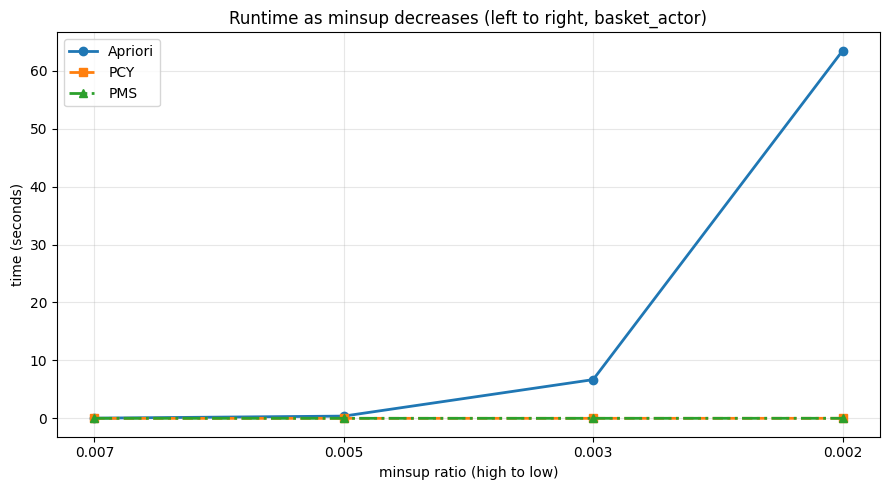

In [67]:

# Table 2: runtime comparison.
df_actor_time = df_compare_actor_three[[
    'minsup_ratio', 'minsup',
    'time_apriori_s', 'time_pcy_s', 'time_pms_s',
]].copy()

df_actor_time['speedup_pcy_vs_apriori'] = (
    df_actor_time['time_apriori_s'] / df_actor_time['time_pcy_s']
).round(2)
df_actor_time['speedup_pms_vs_apriori'] = (
    df_actor_time['time_apriori_s'] / df_actor_time['time_pms_s']
).round(2)

print('Runtime summary (seconds and speedup vs Apriori):')
display(df_actor_time)

# Graph 1: runtime trend with minsup ordered high -> low (left -> right).
df_actor_time_view = df_compare_actor_three.sort_values('minsup_ratio', ascending=False).reset_index(drop=True)
x_idx = np.arange(len(df_actor_time_view))
x_labels = [f"{v:.3f}" for v in df_actor_time_view['minsup_ratio']]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x_idx, df_actor_time_view['time_apriori_s'], marker='o', linestyle='-', linewidth=2, label='Apriori')
ax.plot(x_idx, df_actor_time_view['time_pcy_s'], marker='s', linestyle='--', linewidth=2, label='PCY')
ax.plot(x_idx, df_actor_time_view['time_pms_s'], marker='^', linestyle='-.', linewidth=2, label='PMS')

ax.set_xticks(x_idx)
ax.set_xticklabels(x_labels)
ax.set_title('Runtime as minsup decreases (left to right, basket_actor)')
ax.set_xlabel('minsup ratio (high to low)')
ax.set_ylabel('time (seconds)')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


In [68]:
# Conclusion for basket_actor

mean_times = {
    'Apriori': df_compare_actor_three['time_apriori_s'].mean(),
    'PCY': df_compare_actor_three['time_pcy_s'].mean(),
    'PMS': df_compare_actor_three['time_pms_s'].mean(),
}
mean_c2 = {
    'Apriori': df_compare_actor_three['C2_apr'].mean(),
    'PCY': df_compare_actor_three['C2_pcy'].mean(),
    'PMS': df_compare_actor_three['C2_pms'].mean(),
}

best_time = min(mean_times, key=mean_times.get)
best_c2 = min(mean_c2, key=mean_c2.get)

print('basket_actor conclusion:')
print({'best_runtime': best_time, 'best_C2_reduction': best_c2})
if best_time == best_c2:
    print(f'Recommended default on basket_actor: {best_time}')
else:
    print(f'Recommended default on basket_actor: {best_time} (runtime), with {best_c2} as strongest C2-pruner')


basket_actor conclusion:
{'best_runtime': 'PCY', 'best_C2_reduction': 'PMS'}
Recommended default on basket_actor: PCY (runtime), with PMS as strongest C2-pruner


Under the low dimensional setting of actor-only basket, going with PCY to prioritize running time is more preferred.


After validating behavior on actor-only baskets, the next section increases item vocabulary (actors + tiers) to stress scalability under richer baskets.


## 4.5 Scaling Experiment

### 4.5.1 Enriched Basket Design
To see the turning point where the PCY is helpful for model, I build a second basket design for each movie by combining:

- actors
- the discretised economic features (gross tier, votes band),
- content attributes (director, genre categories, certificate, runtime band, decade),
- rating and critic‑score bands.

Each of these elements is encoded as a single item string, for example
`genre_action` or `decade_2010`. The resulting transaction contains a compact
summary of the film from an association‑rule perspective.

I export these enriched baskets to `enriched_transactions.csv`. This file is
the starting point for the time-cost experiments with PCY and multistage scalability behavior on this denser, more realistic market‑basket dataset.


In [69]:
# Inspect cleaned dataframe schema and non-null counts.
# Info output confirms column types before enrichment.

df_clean.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   series_title   1000 non-null   str    
 1   released_year  999 non-null    object 
 2   decade         999 non-null    str    
 3   runtime        1000 non-null   float64
 4   genre_list     1000 non-null   object 
 5   primary_genre  1000 non-null   object 
 6   certificate    899 non-null    str    
 7   director       1000 non-null   str    
 8   star1          1000 non-null   str    
 9   star2          1000 non-null   str    
 10  star3          1000 non-null   str    
 11  star4          1000 non-null   str    
 12  imdb_rating    1000 non-null   float64
 13  meta_score     843 non-null    float64
 14  no_of_votes    1000 non-null   int64  
 15  gross          831 non-null    float64
dtypes: float64(4), int64(1), object(3), str(8)
memory usage: 212.2+ KB


In [70]:
# Compute missing-value counts and percentages.
# Table identifies remaining sparsity hotspots after cleaning.

missing_counts = df_clean.isnull().sum()
missing_percents = (missing_counts / len(df_clean) * 100).round(2)
missing_df = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_percent': missing_percents
})
print("Missing values by column:")
print(missing_df)


Missing values by column:
               missing_count  missing_percent
series_title               0              0.0
released_year              1              0.1
decade                     1              0.1
runtime                    0              0.0
genre_list                 0              0.0
primary_genre              0              0.0
certificate              101             10.1
director                   0              0.0
star1                      0              0.0
star2                      0              0.0
star3                      0              0.0
star4                      0              0.0
imdb_rating                0              0.0
meta_score               157             15.7
no_of_votes                0              0.0
gross                    169             16.9


In [71]:
# Create an enriched working copy of the cleaned data.

df_enrich = df_clean.copy()


Numeric features are binned into tiers to build `basket_multi` for enriched-rule mining.


In [72]:
# Bin numeric metrics into low/mid/high tiers.
# Tier columns create categorical features for multi-basket mining.

labels = ['low', 'mid', 'high']

for col, tier_col in [
    ('gross', 'gross_tier'),
    ('meta_score', 'meta_score_tier'),
    ('imdb_rating', 'rating_tier'),
    ('no_of_votes', 'votes_tier'),
    ('runtime', 'runtime_tier'),
]:
    df_enrich[tier_col] = pd.qcut(df_enrich[col].rank(method='first'), q=3, labels=labels).astype(str)

# if no label then assign 'unknown'
for tier_col in ['gross_tier', 'meta_score_tier', 'rating_tier', 'votes_tier', 'runtime_tier']:
    df_enrich[tier_col] = df_enrich[tier_col].fillna('unknown') 


In [73]:
# Keep a categorical-only enriched dataset.

df_enrich_cat = df_enrich.drop(
    columns=df_enrich.select_dtypes(include=np.number).columns
)
df_enrich_cat = df_enrich_cat.drop(columns=['genre_list'])


In [74]:
# Inspect enriched categorical schema.
# Info confirms the columns carried into basket construction.

df_enrich_cat.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   series_title     1000 non-null   str   
 1   released_year    999 non-null    object
 2   decade           999 non-null    str   
 3   primary_genre    1000 non-null   object
 4   certificate      899 non-null    str   
 5   director         1000 non-null   str   
 6   star1            1000 non-null   str   
 7   star2            1000 non-null   str   
 8   star3            1000 non-null   str   
 9   star4            1000 non-null   str   
 10  gross_tier       1000 non-null   str   
 11  meta_score_tier  1000 non-null   str   
 12  rating_tier      1000 non-null   str   
 13  votes_tier       1000 non-null   str   
 14  runtime_tier     1000 non-null   str   
dtypes: object(2), str(13)
memory usage: 221.9+ KB


In [75]:
# Build multi-attribute baskets directly from df_enrich_cat.

actor_cols_multi = ['star1', 'star2', 'star3', 'star4']
tier_cols_multi = ['gross_tier', 'meta_score_tier', 'rating_tier', 'votes_tier', 'runtime_tier']

baskets_multi = []
for _, row in df_enrich_cat.iterrows():
    items = []

    for col in actor_cols_multi:
        if pd.notna(row[col]) and str(row[col]).strip():
            items.append(f"actor:{str(row[col]).strip().lower()}")

    for col in tier_cols_multi:
        items.append(f"{col}:{row[col]}")

    baskets_multi.append(sorted(set(items)))

max_k = max(len(b) for b in baskets_multi)
print(f"Built {len(baskets_multi)} multi-attribute baskets with max size {max_k}. Example basket:")
print(baskets_multi[0])


Built 1000 multi-attribute baskets with max size 9. Example basket:
['actor:bob gunton', 'actor:morgan freeman', 'actor:tim robbins', 'actor:william sadler', 'gross_tier:mid', 'meta_score_tier:mid', 'rating_tier:high', 'runtime_tier:high', 'votes_tier:high']


### 4.5.2 Performance Comparison on `basket_multi`


**How to read this result block**

- If `|C2|` drops while `|L2|` stays aligned, pruning is removing mostly false-positive candidates.
- `C3/L3` confirms that higher-order mining is still active after pair-level pruning.
- Runtime tells whether extra hashing passes are worth it at this dataset scale.


In [76]:
# Direct Apriori/PCY/PMS comparison on basket_multi.

ratio_cfg = {
    'minsup_ratios': [0.05, 0.03, 0.01, 0.005, 0.002],
    'num_buckets': DEFAULT_NUM_BUCKETS,
}

max_k = min(9, max(len(b) for b in baskets_multi))
n_multi = len(baskets_multi)

rows = []
for r in ratio_cfg['minsup_ratios']:
    minsup = max(1, int(np.ceil(r * n_multi)))

    _, L_apr, C_apr, t_apr = run_apriori_full(baskets_multi, minsup=minsup, max_k=max_k)

    t0 = time.perf_counter()
    _, L_pcy, C_pcy, _ = pcy_full(
        baskets_multi, minsup=minsup, max_k=max_k, num_buckets=ratio_cfg['num_buckets']
    )
    t_pcy = time.perf_counter() - t0

    t0 = time.perf_counter()
    _, L_pms, C_pms, _ = pcy_multistage_full(
        baskets_multi,
        minsup=minsup,
        max_k=max_k,
        num_buckets_stage1=ratio_cfg['num_buckets'],
        num_buckets_stage2=ratio_cfg['num_buckets'],
    )
    t_pms = time.perf_counter() - t0

    rows.append({
        'minsup_ratio': r,
        'minsup': minsup,
        'time_apriori_s': t_apr,
        'time_pcy_s': t_pcy,
        'time_pms_s': t_pms,
        'C2_apr': len(C_apr.get(2, {})),
        'C2_pcy': len(C_pcy.get(2, {})),
        'C2_pms': len(C_pms.get(2, {})),
        'C3_apr': len(C_apr.get(3, {})),
        'C3_pcy': len(C_pcy.get(3, {})),
        'C3_pms': len(C_pms.get(3, {})),
        'L2_apr': len(L_apr.get(2, set())),
        'L2_pcy': len(L_pcy.get(2, set())),
        'L2_pms': len(L_pms.get(2, set())),
    })

compare_apriori_pcy_pms = pd.DataFrame(rows).sort_values('minsup_ratio').reset_index(drop=True)

# Table 1: candidate reduction (PCY vs Apriori, PMS vs Apriori).
df_multi_candidate = compare_apriori_pcy_pms[[
    'minsup_ratio', 'minsup',
    'C2_apr', 'C2_pcy', 'C2_pms',
    'C3_apr', 'C3_pcy', 'C3_pms',
]].copy()

df_multi_candidate['C2_drop_abs_pcy'] = df_multi_candidate['C2_apr'] - df_multi_candidate['C2_pcy']
df_multi_candidate['C2_drop_abs_pms'] = df_multi_candidate['C2_apr'] - df_multi_candidate['C2_pms']
df_multi_candidate['C3_drop_abs_pcy'] = df_multi_candidate['C3_apr'] - df_multi_candidate['C3_pcy']
df_multi_candidate['C3_drop_abs_pms'] = df_multi_candidate['C3_apr'] - df_multi_candidate['C3_pms']

df_multi_candidate['C2_drop_pct_pcy'] = np.where(
    df_multi_candidate['C2_apr'] > 0,
    100 * df_multi_candidate['C2_drop_abs_pcy'] / df_multi_candidate['C2_apr'],
    np.nan,
).round(2)
df_multi_candidate['C2_drop_pct_pms'] = np.where(
    df_multi_candidate['C2_apr'] > 0,
    100 * df_multi_candidate['C2_drop_abs_pms'] / df_multi_candidate['C2_apr'],
    np.nan,
).round(2)
df_multi_candidate['C3_drop_pct_pcy'] = np.where(
    df_multi_candidate['C3_apr'] > 0,
    100 * df_multi_candidate['C3_drop_abs_pcy'] / df_multi_candidate['C3_apr'],
    np.nan,
).round(2)
df_multi_candidate['C3_drop_pct_pms'] = np.where(
    df_multi_candidate['C3_apr'] > 0,
    100 * df_multi_candidate['C3_drop_abs_pms'] / df_multi_candidate['C3_apr'],
    np.nan,
).round(2)

# Table 2: time cost.
df_multi_time = compare_apriori_pcy_pms[[
    'minsup_ratio', 'minsup',
    'time_apriori_s', 'time_pcy_s', 'time_pms_s',
]].copy()

df_multi_time['speedup_pcy_vs_apriori'] = (
    df_multi_time['time_apriori_s'] / df_multi_time['time_pcy_s']
).round(2)
df_multi_time['speedup_pms_vs_apriori'] = (
    df_multi_time['time_apriori_s'] / df_multi_time['time_pms_s']
).round(2)


In [77]:
# Two compact tables: candidate reduction and runtime.

print('Candidate reduction (PCY/PMS vs Apriori):')
show_candidate = df_multi_candidate[[
    'minsup_ratio', 'minsup',
    'C2_apr', 'C2_pcy', 'C2_pms',
    'C2_drop_abs_pcy', 'C2_drop_abs_pms', 'C2_drop_pct_pcy', 'C2_drop_pct_pms',
   ]].rename(columns={
    'C2_pms': 'C2_pms_after_pass3'
})
display(show_candidate)

print('Runtime comparison (Apriori, PCY, PMS):')
display(df_multi_time)


Candidate reduction (PCY/PMS vs Apriori):


,minsup_ratio,minsup,C2_apr,C2_pcy,C2_pms_after_pass3,C2_drop_abs_pcy,C2_drop_abs_pms,C2_drop_pct_pcy,C2_drop_pct_pms
0,0.002,2,7471,7471,7336,0,135,0.00,1.81
1,0.005,5,1230,1228,564,2,666,0.16,54.15
2,0.010,10,243,234,131,9,112,3.70,46.09
3,0.030,30,115,111,106,4,9,3.48,7.83
4,0.050,50,115,107,99,8,16,6.96,13.91


Runtime comparison (Apriori, PCY, PMS):


,minsup_ratio,minsup,time_apriori_s,time_pcy_s,time_pms_s,speedup_pcy_vs_apriori,speedup_pms_vs_apriori
0,0.002,2,99.802739,26.267041,21.755516,3.80,4.59
1,0.005,5,0.600776,0.266428,0.287713,2.25,2.09
2,0.010,10,0.130275,0.134502,0.145612,0.97,0.89
3,0.030,30,0.060147,0.069424,0.083003,0.87,0.72
4,0.050,50,0.066640,0.063532,0.081476,1.05,0.82


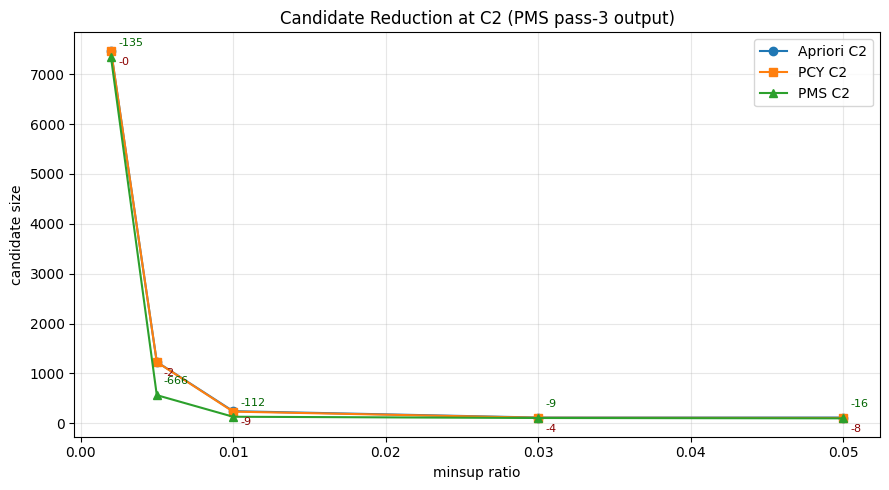

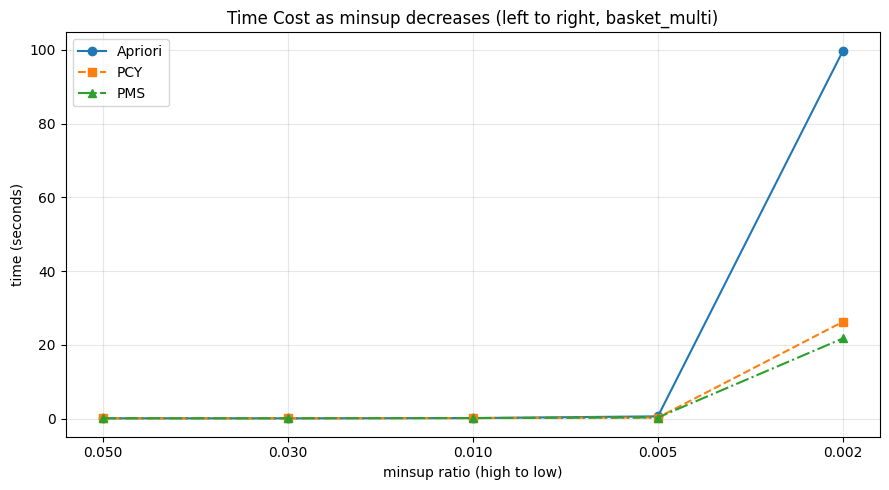

In [78]:
# Two visuals: C2 candidate trend and runtime trend.

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df_multi_candidate['minsup_ratio'], df_multi_candidate['C2_apr'], marker='o', label='Apriori C2')
ax.plot(df_multi_candidate['minsup_ratio'], df_multi_candidate['C2_pcy'], marker='s', label='PCY C2')
ax.plot(df_multi_candidate['minsup_ratio'], df_multi_candidate['C2_pms'], marker='^', label='PMS C2')
for _, r in df_multi_candidate.iterrows():
    ax.annotate(
        f"-{int(r['C2_drop_abs_pcy'])}",
        (r['minsup_ratio'], r['C2_pcy']),
        textcoords='offset points',
        xytext=(5, -10),
        fontsize=8,
        color='darkred',
    )
    ax.annotate(
        f"-{int(r['C2_drop_abs_pms'])}",
        (r['minsup_ratio'], r['C2_pms']),
        textcoords='offset points',
        xytext=(5, 8),
        fontsize=8,
        color='darkgreen',
    )
ax.set_title('Candidate Reduction at C2 (PMS pass-3 output)')
ax.set_xlabel('minsup ratio')
ax.set_ylabel('candidate size')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

df_multi_time_view = df_multi_time.sort_values('minsup_ratio', ascending=False).reset_index(drop=True)
x_idx = np.arange(len(df_multi_time_view))
x_labels = [f"{v:.3f}" for v in df_multi_time_view['minsup_ratio']]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x_idx, df_multi_time_view['time_apriori_s'], marker='o', linestyle='-', label='Apriori')
ax.plot(x_idx, df_multi_time_view['time_pcy_s'], marker='s', linestyle='--', label='PCY')
ax.plot(x_idx, df_multi_time_view['time_pms_s'], marker='^', linestyle='-.', label='PMS')
ax.set_xticks(x_idx)
ax.set_xticklabels(x_labels)
ax.set_title('Time Cost as minsup decreases (left to right, basket_multi)')
ax.set_xlabel('minsup ratio (high to low)')
ax.set_ylabel('time (seconds)')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


The tables and plots above are the standardized enriched-basket comparison for
Apriori, PCY, and PCY-Multistage.

Read this in three layers:
1. Pair-level pruning effect (`C2/L2`) where PCY-family methods should help most.
2. Triple-level check (`C3`) in the candidate table as a correctness sanity check:
   for exact implementations, `C3` is usually unchanged because PCY and PMS only prune pair candidates.
3. Runtime impact to see whether stronger pair pruning compensates the extra pass overhead.

In short: **pass 3 in Multistage means the third pass for pair counting, not `k=3` triples**.


In [79]:
# Conclusion for basket_multi extension.

mean_times_multi = {
    'Apriori': compare_apriori_pcy_pms['time_apriori_s'].mean(),
    'PCY': compare_apriori_pcy_pms['time_pcy_s'].mean(),
    'PMS': compare_apriori_pcy_pms['time_pms_s'].mean(),
}
mean_c2_multi = {
    'Apriori': compare_apriori_pcy_pms['C2_apr'].mean(),
    'PCY': compare_apriori_pcy_pms['C2_pcy'].mean(),
    'PMS': compare_apriori_pcy_pms['C2_pms'].mean(),
}

best_time_multi = min(mean_times_multi, key=mean_times_multi.get)
best_c2_multi = min(mean_c2_multi, key=mean_c2_multi.get)

c3_drop_total_pcy = int(df_multi_candidate['C3_drop_abs_pcy'].sum())
c3_drop_total_pms = int(df_multi_candidate['C3_drop_abs_pms'].sum())

print('basket_multi conclusion:')
print({
    'best_runtime': best_time_multi,
    'best_C2_reduction': best_c2_multi,
    'C3_total_drop_pcy_vs_apriori': c3_drop_total_pcy,
    'C3_total_drop_pms_vs_apriori': c3_drop_total_pms,
})


if best_time_multi == best_c2_multi:
    print(f'Recommended default on basket_multi: {best_time_multi}')
else:
    print(f'Recommended default on basket_multi: {best_time_multi} (runtime), with {best_c2_multi} as strongest C2-pruner')


basket_multi conclusion:
{'best_runtime': 'PMS', 'best_C2_reduction': 'PMS', 'C3_total_drop_pcy_vs_apriori': 0, 'C3_total_drop_pms_vs_apriori': 0}
Recommended default on basket_multi: PMS


# 5 Association Rules Mining

## 5.1 Final Model Configuration

Chosen setup for final rule mining:
- Basket design: **actor-only** (`star1..star4`)
- Frequent-itemset algorithm: **PCY**
- `minsup_ratio = 0.005` (global), with absolute `minsup` computed from dataset size
- `minconf = 0.5`



In [80]:
# Set final mining configuration and run global actor analysis.

best_minsup_ratio = 0.005
best_minconf = 0.5
best_num_buckets = DEFAULT_NUM_BUCKETS

actor_cols = ['star1', 'star2', 'star3', 'star4']

baskets_global = (
    df_clean[actor_cols]
    .apply(lambda r: sorted({x for x in r if pd.notna(x) and str(x).strip()}), axis=1)
    .tolist()
)
baskets_global = [b for b in baskets_global if b]

n_global = len(baskets_global)
best_minsup = max(1, int(np.ceil(best_minsup_ratio * n_global)))

res_global, item_counts_global, pair_counts_global, L1_global, L2_global, _ = run_pcy_pairs(
    baskets_global,
    minsup=best_minsup,
    num_buckets=best_num_buckets,
)

rule_rows = []
for (a, b), cnt_ab in pair_counts_global.items():
    if cnt_ab < best_minsup:
        continue

    support = cnt_ab / n_global

    for lhs, rhs in [(a, b), (b, a)]:
        lhs_support = item_counts_global[lhs] / n_global if n_global > 0 else 0.0
        rhs_support = item_counts_global[rhs] / n_global if n_global > 0 else 0.0
        conf = cnt_ab / item_counts_global[lhs] if item_counts_global[lhs] > 0 else 0.0
        lift = conf / rhs_support if rhs_support > 0 else np.nan
        # Interest (leverage): support(X U Y) - support(X) * support(Y)
        interest = support - (lhs_support * rhs_support)

        if conf >= best_minconf and interest > 0:
            rule_rows.append({
                'lhs': lhs,
                'rhs': rhs,
                'support_count': cnt_ab,
                'support': support,
                'confidence': conf,
                'lift': lift,
                'interest': interest,
            })

print('Configuration summary:', {
    'minsup_ratio': best_minsup_ratio,
    'minsup': best_minsup,
    **res_global,
})
print('Leading pair rules:')
if rule_rows:
    display(pd.DataFrame(rule_rows).sort_values(
        ['lift', 'confidence', 'interest', 'support_count'],
        ascending=False,
    ).head(10))
else:
    print('No pair rules at this threshold.')



_, L_dict_g, counts_dict_g, _ = run_apriori_full(baskets_global, minsup=best_minsup, max_k=3)
triples = list(L_dict_g.get(3, set()))

if len(triples) > 0:
    triples_sorted = sorted(triples, key=lambda t: counts_dict_g[3][t], reverse=True)
    triples_rows = []
    for t in triples_sorted[:10]:
        triples_rows.append({
            'triple': tuple(sorted(t)),
            'support_count': counts_dict_g[3][t],
            'support': counts_dict_g[3][t] / len(baskets_global),
        })

    print('Frequent triples (L3):')
    display(pd.DataFrame(triples_rows))

    top_triple = triples_sorted[0]
    top_triple_set = set(top_triple)

    actor_sets = df_clean[actor_cols].apply(
        lambda r: {str(x).strip() for x in r if pd.notna(x) and str(x).strip()},
        axis=1,
    )
    mask_top_triple = actor_sets.apply(lambda s: top_triple_set.issubset(s))

    df_top_triple_movies = df_clean.loc[mask_top_triple].copy()
    df_top_triple_movies = df_top_triple_movies.sort_values(['imdb_rating', 'no_of_votes'], ascending=[False, False])

    print(f"Movies containing top frequent triple {tuple(sorted(top_triple))}: {len(df_top_triple_movies)}")
    with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 220):
        display(df_top_triple_movies.head(20))
else:
    print('No frequent triples at this minsup.')


Configuration summary: {'minsup_ratio': 0.005, 'minsup': 5, 'L1_size': 79, 'C2_size': 61, 'L2_size': 3, 'time_sec': 0.005196400044951588, 'num_buckets': 2048, 'freq_buckets': 379}
Leading pair rules:


,lhs,rhs,support_count,support,confidence,lift,interest
2,daniel radcliffe,rupert grint,6,0.006,1.000000,166.666667,0.005964
3,rupert grint,daniel radcliffe,6,0.006,1.000000,166.666667,0.005964
0,daniel radcliffe,emma watson,5,0.005,0.833333,119.047619,0.004958
5,rupert grint,emma watson,5,0.005,0.833333,119.047619,0.004958
1,emma watson,daniel radcliffe,5,0.005,0.714286,119.047619,0.004958
4,emma watson,rupert grint,5,0.005,0.714286,119.047619,0.004958


Frequent triples (L3):


,triple,support_count,support
0,"(daniel radcliffe, emma watson, rupert grint)",5,0.005


Movies containing top frequent triple ('daniel radcliffe', 'emma watson', 'rupert grint'): 5


,series_title,released_year,decade,runtime,genre_list,primary_genre,certificate,director,star1,star2,star3,star4,imdb_rating,meta_score,no_of_votes,gross
226,Harry Potter and the Deathly Hallows: Part 2,2011.0,2010s,130.0,"[Adventure, Drama, Fantasy]",Adventure,UA,David Yates,daniel radcliffe,emma watson,rupert grint,michael gambon,8.1,85.0,764493,381.011219
506,Harry Potter and the Prisoner of Azkaban,2004.0,2000s,142.0,"[Adventure, Family, Fantasy]",Adventure,U,Alfonso Cuarón,daniel radcliffe,emma watson,rupert grint,richard griffiths,7.9,82.0,552493,249.358727
781,Harry Potter and the Goblet of Fire,2005.0,2000s,157.0,"[Adventure, Family, Fantasy]",Adventure,UA,Mike Newell,daniel radcliffe,emma watson,rupert grint,eric sykes,7.7,81.0,548619,290.013036
755,Harry Potter and the Deathly Hallows: Part 1,2010.0,2010s,146.0,"[Adventure, Family, Fantasy]",Adventure,A,David Yates,daniel radcliffe,emma watson,rupert grint,bill nighy,7.7,65.0,479120,295.983305
927,Harry Potter and the Half-Blood Prince,2009.0,2000s,153.0,"[Action, Adventure, Family]",Action,UA,David Yates,daniel radcliffe,emma watson,rupert grint,michael gambon,7.6,78.0,474827,301.959197


## 5.2 Slice Analysis (High-Rating Movies)

Now I repeat actor-only rule mining on a quality-focused slice: movies with `imdb_rating` in the top quartile.
I keep the same `minsup_ratio` policy and convert it to absolute `minsup` using the slice size.


In [81]:
slice_name = 'High-Rating Movies'
rating_cutoff = float(df_clean['imdb_rating'].quantile(0.75))
df_slice = df_clean[df_clean['imdb_rating'] >= rating_cutoff].copy()

baskets_actor_slice = (
    df_slice[actor_cols]
    .apply(lambda r: sorted({x for x in r if pd.notna(x) and str(x).strip()}), axis=1)
    .tolist()
)
baskets_actor_slice = [b for b in baskets_actor_slice if b]

n_global = len(baskets_global)
n_slice = len(baskets_actor_slice)

slice_minsup = max(1, int(np.ceil(best_minsup_ratio * n_slice)))

res_slice, item_counts_slice, pair_counts_slice, L1_slice, L2_slice, _ = run_pcy_pairs(
    baskets_actor_slice,
    minsup=slice_minsup,
    num_buckets=best_num_buckets,
)

rule_rows = []
for (a, b), cnt_ab in pair_counts_slice.items():
    if cnt_ab < slice_minsup:
        continue

    support = cnt_ab / n_slice

    for lhs, rhs in [(a, b), (b, a)]:
        lhs_support = item_counts_slice[lhs] / n_slice if n_slice > 0 else 0.0
        rhs_support = item_counts_slice[rhs] / n_slice if n_slice > 0 else 0.0
        conf = cnt_ab / item_counts_slice[lhs] if item_counts_slice[lhs] > 0 else 0.0
        lift = conf / rhs_support if rhs_support > 0 else np.nan
        interest = support - (lhs_support * rhs_support)

        if conf >= best_minconf and interest > 0:
            rule_rows.append({
                'lhs': lhs,
                'rhs': rhs,
                'support_count': cnt_ab,
                'support': support,
                'confidence': conf,
                'lift': lift,
                'interest': interest,
            })

rules_slice = pd.DataFrame(rule_rows)
if not rules_slice.empty:
    rules_slice = rules_slice.sort_values(
        ['lift', 'confidence', 'interest', 'support_count'],
        ascending=False,
    )

interesting_slice_rules = rules_slice.head(12)

print(
    f"Slice: {slice_name} | rating_cutoff >= {rating_cutoff:.2f} | movies={len(df_slice)} "
    f"({len(df_slice)/len(df_clean):.1%} of all) | minsup_ratio={best_minsup_ratio:.4f} | minsup={slice_minsup}"
)
print('Actor rules in the high-rating slice:')
display(interesting_slice_rules)

if interesting_slice_rules.empty:
    print('No actor-pair rule passed the current minsup/minconf in this slice.')
    df_rule_movies_full = pd.DataFrame()
else:
    strongest = interesting_slice_rules.iloc[0]
    repeated_actors = (
        pd.concat([interesting_slice_rules['lhs'], interesting_slice_rules['rhs']])
        .value_counts()
        .head(3)
        .index.tolist()
    )
    repeated_text = ', '.join(repeated_actors)

    print('Quick read:')
    print(
        f"- Strongest rule: {strongest['lhs']} -> {strongest['rhs']} "
        f"(lift={strongest['lift']:.2f}, confidence={strongest['confidence']:.2f}, support={strongest['support']:.3f})."
    )
    print(
        f"- Repeated names in top rules: {repeated_text}. "
        "This suggests recurring co-casting patterns inside high-rating movies."
    )

    lhs_actor = strongest['lhs']
    rhs_actor = strongest['rhs']
    mask_rule = (
        df_slice[actor_cols].eq(lhs_actor).any(axis=1)
        & df_slice[actor_cols].eq(rhs_actor).any(axis=1)
    )

    df_rule_movies_full = df_slice.loc[mask_rule].sort_values(['imdb_rating', 'no_of_votes'], ascending=[False, False]).copy()

    print(f"Full movie information for top rule ({lhs_actor} -> {rhs_actor}): {len(df_rule_movies_full)} rows")
    with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 220):
        display(df_rule_movies_full)


Slice: High-Rating Movies | rating_cutoff >= 8.10 | movies=322 (32.2% of all) | minsup_ratio=0.0050 | minsup=2
Actor rules in the high-rating slice:


,lhs,rhs,support_count,support,confidence,lift,interest
35,joe russo,robert downey jr.,2,0.006211,1.0,161.000000,0.006173
36,robert downey jr.,joe russo,2,0.006211,1.0,161.000000,0.006173
45,joseph cotten,orson welles,2,0.006211,1.0,161.000000,0.006173
46,orson welles,joseph cotten,2,0.006211,1.0,161.000000,0.006173
50,anatoliy solonitsyn,nikolay grinko,2,0.006211,1.0,161.000000,0.006173
51,nikolay grinko,anatoliy solonitsyn,2,0.006211,1.0,161.000000,0.006173
52,graham chapman,john cleese,2,0.006211,1.0,161.000000,0.006173
53,john cleese,graham chapman,2,0.006211,1.0,161.000000,0.006173
5,elijah wood,ian mckellen,3,0.009317,1.0,107.333333,0.009230
6,ian mckellen,elijah wood,3,0.009317,1.0,107.333333,0.009230


Quick read:
- Strongest rule: joe russo -> robert downey jr. (lift=161.00, confidence=1.00, support=0.006).
- Repeated names in top rules: elijah wood, joe russo, robert downey jr.. This suggests recurring co-casting patterns inside high-rating movies.
Full movie information for top rule (joe russo -> robert downey jr.): 2 rows


,series_title,released_year,decade,runtime,genre_list,primary_genre,certificate,director,star1,star2,star3,star4,imdb_rating,meta_score,no_of_votes,gross
60,Avengers: Infinity War,2018.0,2010s,149.0,"[Action, Adventure, Sci-Fi]",Action,UA,Anthony Russo,joe russo,robert downey jr.,chris hemsworth,mark ruffalo,8.4,68.0,834477,678.815482
59,Avengers: Endgame,2019.0,2010s,181.0,"[Action, Adventure, Drama]",Action,UA,Anthony Russo,joe russo,robert downey jr.,chris evans,mark ruffalo,8.4,78.0,809955,858.373000


## 5.3 Extension for Enriched Basket (PMS + Rule Filtering)



### 5.3.1 Conceptual Framework for a Stricter Post-Filter Pipeline

Enriched baskets can produce many raw rules, including noisy ones.  
This pipeline keeps the process readable in three layers: **frequency -> statistical validity -> compact interpretability**.

1. **Frequency layer (candidate generation)**
   - Mine frequent itemsets/rules first (PMS + Apriori-style expansion).
   - This follows the classic association-rule pipeline from Agrawal & Srikant.

2. **Statistical validity layer (significance test)**
   - Confidence alone can be misleading in dense data.
   - Apply **Fisher's exact test** to answer question "Could this rule look strong just by luck?" and keep rules with `p < 0.05`.
       - Small p-value (e.g., < 0.05): unlikely this overlap happened by chance.
       - Large p-value: overlap could be random.

3. **Compactness + interpretability layer**
   - **Redundancy pruning**: remove repeated/overlapping rules when a simpler one with the same consequent has equal/higher confidence.
   - **Maximal filter**:  keep only largest antecedent versions (same consequent) and drops smaller subset antecedents when a larger one exists for the same target.
   - Sort by confidence, then split into One **One-item Rules (1->1)** and **Multi-items Rules (N->1)** views for reporting.


#### Threshold Support Ratio = 0.01

Testing set up:
- Basket design: **basket_multi** 
- Frequent-itemset algorithm: **PMS**
- `minsup_ratio = 0.01`
- `minconf = 0.50`



In [82]:
# Settings for enriched-rule mining.

from scipy.stats import fisher_exact

minsup_ratio_ext = 0.01
minconf_ext = 0.5
max_k_ext = 9
num_buckets_ext = 4096
p_threshold = 0.05

n_multi = len(baskets_multi)
minsup_ext = max(10, int(np.ceil(minsup_ratio_ext * n_multi)))

print('config:')
print({
    'n_baskets': n_multi,
    'minsup_ratio': minsup_ratio_ext,
    'minsup': minsup_ext,
    'minconf': minconf_ext,
    'max_k': max_k_ext,
    'num_buckets': num_buckets_ext,
    'p_threshold': p_threshold,
})


config:
{'n_baskets': 1000, 'minsup_ratio': 0.01, 'minsup': 10, 'minconf': 0.5, 'max_k': 9, 'num_buckets': 4096, 'p_threshold': 0.05}


In [83]:
# Mine base rules from PMS frequent itemsets.

t0 = time.perf_counter()
_, L_dict_ext, counts_dict_ext, _ = pcy_multistage_full(
    baskets_multi,
    minsup=minsup_ext,
    max_k=max_k_ext,
    num_buckets_stage1=num_buckets_ext,
    num_buckets_stage2=num_buckets_ext,
)
t_pms_ext = time.perf_counter() - t0

n = len(baskets_multi)
rows = []

for k in range(2, max_k_ext + 1):
    for itemset in L_dict_ext.get(k, set()):
        if k == 2:
            sup_count = counts_dict_ext.get(2, {}).get(tuple(sorted(itemset)), 0)
        else:
            sup_count = counts_dict_ext.get(k, {}).get(frozenset(itemset), 0)

        if sup_count < minsup_ext:
            continue

        for rhs in itemset:
            lhs = frozenset(itemset - {rhs})
            lhs_k = len(lhs)

            if lhs_k == 1:
                lhs_item = next(iter(lhs))
                lhs_count = counts_dict_ext.get(1, {}).get(lhs_item, 0)
            elif lhs_k == 2:
                lhs_count = counts_dict_ext.get(2, {}).get(tuple(sorted(lhs)), 0)
            else:
                lhs_count = counts_dict_ext.get(lhs_k, {}).get(frozenset(lhs), 0)

            rhs_count = counts_dict_ext.get(1, {}).get(rhs, 0)

            if lhs_count == 0:
                continue

            support = sup_count / n
            antecedent_support = lhs_count / n
            consequent_support = rhs_count / n
            confidence = sup_count / lhs_count
            lift = confidence / consequent_support if consequent_support > 0 else np.nan
            
            interest = support - (antecedent_support * consequent_support)

            if confidence < minconf_ext or interest <= 0:
                continue

            rows.append({
                'antecedents': lhs,
                'consequents': frozenset([rhs]),
                'support_count': sup_count,
                'support': support,
                'antecedent_support': antecedent_support,
                'consequent_support': consequent_support,
                'confidence': confidence,
                'lift': lift,
                'interest': interest,
            })

rules_mining = pd.DataFrame(rows)
if not rules_mining.empty:
    rules_mining = rules_mining.sort_values(
        ['lift', 'confidence', 'interest', 'support_count'],
        ascending=False,
    )

print('Rule mining summary:')
print({
    'pms_time_sec': round(t_pms_ext, 4),
    'raw_rules_after_conf_interest': len(rules_mining),
})

display(rules_mining.head(10))


Rule mining summary:
{'pms_time_sec': 0.2669, 'raw_rules_after_conf_interest': 475}


,antecedents,consequents,support_count,support,antecedent_support,consequent_support,confidence,lift,interest
458,"frozenset({rating_tier:high, gross_tier:unknow...",frozenset({meta_score_tier:unknown}),15,0.015,0.019,0.157,0.789474,5.028495,0.012017
224,"frozenset({rating_tier:high, votes_tier:low, r...",frozenset({meta_score_tier:unknown}),34,0.034,0.046,0.157,0.739130,4.707837,0.026778
472,"frozenset({rating_tier:high, votes_tier:low, g...",frozenset({meta_score_tier:unknown}),18,0.018,0.025,0.157,0.720000,4.585987,0.014075
221,"frozenset({rating_tier:high, gross_tier:unknow...",frozenset({meta_score_tier:unknown}),29,0.029,0.041,0.157,0.707317,4.505204,0.022563
371,"frozenset({rating_tier:high, gross_tier:unknow...",frozenset({meta_score_tier:unknown}),16,0.016,0.023,0.157,0.695652,4.430906,0.012389
172,"frozenset({gross_tier:unknown, votes_tier:low,...",frozenset({meta_score_tier:unknown}),22,0.022,0.033,0.157,0.666667,4.246285,0.016819
86,"frozenset({rating_tier:high, votes_tier:low})",frozenset({meta_score_tier:unknown}),62,0.062,0.096,0.157,0.645833,4.113588,0.046928
170,"frozenset({rating_tier:high, votes_tier:low, g...",frozenset({meta_score_tier:unknown}),32,0.032,0.052,0.157,0.615385,3.919647,0.023836
116,"frozenset({rating_tier:high, gross_tier:unknown})",frozenset({meta_score_tier:unknown}),38,0.038,0.064,0.157,0.593750,3.781847,0.027952
95,"frozenset({gross_tier:unknown, runtime_tier:hi...",frozenset({meta_score_tier:unknown}),23,0.023,0.039,0.157,0.589744,3.756329,0.016877


In [84]:
# Filter mined rules using Fisher significance and Kulc.

if rules_mining.empty:
    significant = rules_mining.copy()
else:
    items = sorted({x for b in baskets_multi for x in b})
    df_basket_enc = pd.DataFrame(0, index=np.arange(len(baskets_multi)), columns=items, dtype=np.int8)

    for i, b in enumerate(baskets_multi):
        if b:
            df_basket_enc.loc[i, list(set(b))] = 1

    p_values = []
    for row in rules_mining.to_dict('records'):
        lhs = list(row['antecedents'])
        rhs = list(row['consequents'])

        lhs_mask = df_basket_enc[lhs].all(axis=1)
        rhs_mask = df_basket_enc[rhs].all(axis=1)

        a = ( lhs_mask &  rhs_mask).sum()
        b = ( lhs_mask & ~rhs_mask).sum()
        c = (~lhs_mask &  rhs_mask).sum()
        d = (~lhs_mask & ~rhs_mask).sum()

        _, p_val = fisher_exact([[a, b], [c, d]], alternative='greater')
        p_values.append(p_val)

    rules_mining = rules_mining.copy()
    rules_mining['p_value'] = p_values
    rules_mining['kulc'] = 0.5 * (
        rules_mining['confidence'] +
        rules_mining['support'] / rules_mining['consequent_support'].replace(0, np.nan)
    )

    rules_mining['is_significant'] = rules_mining['p_value'] < p_threshold 
    significant = rules_mining[rules_mining['is_significant']].copy()

significant_count = int(significant['is_significant'].sum()) if not significant.empty else 0
print(f"Fisher-significant rules (p < {p_threshold}): {significant_count} / {len(rules_mining)}")
display(significant.sort_values(['lift', 'confidence', 'interest'], ascending=False).head(10))


Fisher-significant rules (p < 0.05): 464 / 475


,antecedents,consequents,support_count,support,antecedent_support,consequent_support,confidence,lift,interest,p_value,kulc,is_significant
458,"frozenset({rating_tier:high, gross_tier:unknow...",frozenset({meta_score_tier:unknown}),15,0.015,0.019,0.157,0.789474,5.028495,0.012017,1.048328e-09,0.442508,True
224,"frozenset({rating_tier:high, votes_tier:low, r...",frozenset({meta_score_tier:unknown}),34,0.034,0.046,0.157,0.739130,4.707837,0.026778,1.347718e-19,0.477845,True
472,"frozenset({rating_tier:high, votes_tier:low, g...",frozenset({meta_score_tier:unknown}),18,0.018,0.025,0.157,0.720000,4.585987,0.014075,2.492076e-10,0.417325,True
221,"frozenset({rating_tier:high, gross_tier:unknow...",frozenset({meta_score_tier:unknown}),29,0.029,0.041,0.157,0.707317,4.505204,0.022563,6.995841e-16,0.446015,True
371,"frozenset({rating_tier:high, gross_tier:unknow...",frozenset({meta_score_tier:unknown}),16,0.016,0.023,0.157,0.695652,4.430906,0.012389,6.191789e-09,0.398782,True
172,"frozenset({gross_tier:unknown, votes_tier:low,...",frozenset({meta_score_tier:unknown}),22,0.022,0.033,0.157,0.666667,4.246285,0.016819,2.230143e-11,0.403397,True
86,"frozenset({rating_tier:high, votes_tier:low})",frozenset({meta_score_tier:unknown}),62,0.062,0.096,0.157,0.645833,4.113588,0.046928,2.206057e-31,0.520369,True
170,"frozenset({rating_tier:high, votes_tier:low, g...",frozenset({meta_score_tier:unknown}),32,0.032,0.052,0.157,0.615385,3.919647,0.023836,8.715556e-15,0.409603,True
116,"frozenset({rating_tier:high, gross_tier:unknown})",frozenset({meta_score_tier:unknown}),38,0.038,0.064,0.157,0.593750,3.781847,0.027952,8.777143e-17,0.417894,True
95,"frozenset({gross_tier:unknown, runtime_tier:hi...",frozenset({meta_score_tier:unknown}),23,0.023,0.039,0.157,0.589744,3.756329,0.016877,2.966481e-10,0.368120,True


In [85]:
# Remove redundant rules with subset-confidence checks.

if significant.empty:
    non_redundant = significant.copy()
else:
    rules_list = significant.to_dict('records')
    keep = []

    for i, rule in enumerate(rules_list):
        antecedent = set(rule['antecedents'])
        cons = rule['consequents']
        conf = rule['confidence']
        redundant = False

        for j, other in enumerate(rules_list):
            if i == j:
                continue
            if cons == other['consequents'] and conf <= other['confidence']:
                if set(other['antecedents']).issubset(antecedent):
                    redundant = True
                    break

        keep.append(not redundant)

    non_redundant = pd.DataFrame([r for r, k in zip(rules_list, keep) if k])
    if not non_redundant.empty:
        non_redundant = non_redundant.sort_values(
            ['lift', 'confidence', 'interest', 'support_count'],
            ascending=False,
        )

print(f'Non-redundant rules count: {len(non_redundant)}')
display(non_redundant.head(10))


Non-redundant rules count: 300


,antecedents,consequents,support_count,support,antecedent_support,consequent_support,confidence,lift,interest,p_value,kulc,is_significant
0,"frozenset({rating_tier:high, gross_tier:unknow...",frozenset({meta_score_tier:unknown}),15,0.015,0.019,0.157,0.789474,5.028495,0.012017,1.048328e-09,0.442508,True
1,"frozenset({rating_tier:high, votes_tier:low, r...",frozenset({meta_score_tier:unknown}),34,0.034,0.046,0.157,0.739130,4.707837,0.026778,1.347718e-19,0.477845,True
2,"frozenset({rating_tier:high, gross_tier:unknow...",frozenset({meta_score_tier:unknown}),29,0.029,0.041,0.157,0.707317,4.505204,0.022563,6.995841e-16,0.446015,True
3,"frozenset({rating_tier:high, gross_tier:unknow...",frozenset({meta_score_tier:unknown}),16,0.016,0.023,0.157,0.695652,4.430906,0.012389,6.191789e-09,0.398782,True
4,"frozenset({gross_tier:unknown, votes_tier:low,...",frozenset({meta_score_tier:unknown}),22,0.022,0.033,0.157,0.666667,4.246285,0.016819,2.230143e-11,0.403397,True
5,"frozenset({rating_tier:high, votes_tier:low})",frozenset({meta_score_tier:unknown}),62,0.062,0.096,0.157,0.645833,4.113588,0.046928,2.206057e-31,0.520369,True
6,"frozenset({rating_tier:high, gross_tier:unknown})",frozenset({meta_score_tier:unknown}),38,0.038,0.064,0.157,0.593750,3.781847,0.027952,8.777143e-17,0.417894,True
7,"frozenset({gross_tier:unknown, runtime_tier:hi...",frozenset({meta_score_tier:unknown}),23,0.023,0.039,0.157,0.589744,3.756329,0.016877,2.966481e-10,0.368120,True
8,"frozenset({votes_tier:low, meta_score_tier:unk...",frozenset({gross_tier:unknown}),19,0.019,0.030,0.169,0.633333,3.747535,0.013930,8.583398e-09,0.372880,True
9,"frozenset({runtime_tier:low, votes_tier:mid, m...",frozenset({gross_tier:unknown}),10,0.010,0.016,0.169,0.625000,3.698225,0.007296,4.715077e-05,0.342086,True


In [86]:
# Apply maximal filter and split by rule complexity.

if non_redundant.empty:
    rules_filter = non_redundant.copy()
else:
    drop = set()
    rules_list = list(non_redundant.itertuples())

    for i, r1 in enumerate(rules_list):
        for j, r2 in enumerate(rules_list):
            if i == j:
                continue
            if r1.consequents == r2.consequents and r1.antecedents < r2.antecedents:
                drop.add(r1.Index)

    rules_filter = non_redundant[~non_redundant.index.isin(drop)].copy()

if not rules_filter.empty:
    rules_filter = rules_filter.sort_values(
        ['lift', 'confidence', 'interest', 'support_count'],
        ascending=False,
    )
    rules_filter['lhs_len'] = rules_filter['antecedents'].apply(len)
    rules_filter['rhs_len'] = rules_filter['consequents'].apply(len)
else:
    rules_filter = rules_filter.copy()
    rules_filter['lhs_len'] = pd.Series(dtype='int')
    rules_filter['rhs_len'] = pd.Series(dtype='int')

rules_one_item = rules_filter[
    (rules_filter['lhs_len'] == 1) & (rules_filter['rhs_len'] == 1)
].copy()
rules_multi_item = rules_filter[
    (rules_filter['lhs_len'] > 1) | (rules_filter['rhs_len'] > 1)
].copy()

print('After maximal filtering:')
print({
    'after_maximal': len(rules_filter),
    'one_item_rules': len(rules_one_item),
    'multi_item_rules': len(rules_multi_item),
})

cols_show = [
    'antecedents', 'consequents', 'support_count', 'support',
    'confidence', 'lift', 'interest', 'p_value', 'kulc'
]

print('Top rules (all):')
display(rules_filter.reindex(columns=cols_show).head(10))

print('Top one-item rules (1->1):')
display(rules_one_item.reindex(columns=cols_show).head(10))

print('Top multi-item rules (N->1):')
display(rules_multi_item.reindex(columns=cols_show).head(10))


After maximal filtering:
{'after_maximal': 160, 'one_item_rules': 7, 'multi_item_rules': 153}
Top rules (all):


,antecedents,consequents,support_count,support,confidence,lift,interest,p_value,kulc
0,"frozenset({rating_tier:high, gross_tier:unknow...",frozenset({meta_score_tier:unknown}),15,0.015,0.789474,5.028495,0.012017,1.048328e-09,0.442508
8,"frozenset({votes_tier:low, meta_score_tier:unk...",frozenset({gross_tier:unknown}),19,0.019,0.633333,3.747535,0.013930,8.583398e-09,0.372880
9,"frozenset({runtime_tier:low, votes_tier:mid, m...",frozenset({gross_tier:unknown}),10,0.010,0.625000,3.698225,0.007296,4.715077e-05,0.342086
10,"frozenset({rating_tier:mid, votes_tier:low, me...",frozenset({gross_tier:unknown}),22,0.022,0.611111,3.616042,0.015916,1.334784e-09,0.370644
11,"frozenset({rating_tier:low, runtime_tier:high,...",frozenset({gross_tier:high}),16,0.016,1.000000,3.610108,0.011568,8.715860e-10,0.528881
12,frozenset({actor:tom hanks}),frozenset({gross_tier:high}),14,0.014,1.000000,3.610108,0.010122,1.228475e-08,0.525271
13,"frozenset({actor:leonardo dicaprio, votes_tier...",frozenset({gross_tier:high}),10,0.010,1.000000,3.610108,0.007230,2.360637e-06,0.518051
14,"frozenset({actor:leonardo dicaprio, runtime_ti...",frozenset({gross_tier:high}),10,0.010,1.000000,3.610108,0.007230,2.360637e-06,0.518051
15,"frozenset({actor:matt damon, votes_tier:high})",frozenset({gross_tier:high}),10,0.010,1.000000,3.610108,0.007230,2.360637e-06,0.518051
17,"frozenset({rating_tier:mid, runtime_tier:low, ...",frozenset({gross_tier:unknown}),13,0.013,0.590909,3.496503,0.009282,7.367242e-06,0.333916


Top one-item rules (1->1):


,antecedents,consequents,support_count,support,confidence,lift,interest,p_value,kulc
12,frozenset({actor:tom hanks}),frozenset({gross_tier:high}),14,0.014,1.000000,3.610108,0.010122,1.228475e-08,0.525271
49,frozenset({actor:brad pitt}),frozenset({votes_tier:high}),11,0.011,0.916667,2.752753,0.007004,4.203399e-05,0.474850
54,frozenset({actor:christian bale}),frozenset({votes_tier:high}),10,0.010,0.909091,2.730003,0.006337,1.184095e-04,0.469560
92,frozenset({actor:tom hanks}),frozenset({votes_tier:high}),11,0.011,0.785714,2.359502,0.006338,6.292466e-04,0.409374
97,frozenset({actor:al pacino}),frozenset({runtime_tier:high}),10,0.010,0.769231,2.310002,0.005671,1.528420e-03,0.399630
130,frozenset({actor:robert de niro}),frozenset({gross_tier:mid}),10,0.010,0.588235,2.123593,0.005291,6.499081e-03,0.312168
132,frozenset({actor:robert de niro}),frozenset({votes_tier:high}),12,0.012,0.705882,2.119767,0.006339,1.704816e-03,0.370959


Top multi-item rules (N->1):


,antecedents,consequents,support_count,support,confidence,lift,interest,p_value,kulc
0,"frozenset({rating_tier:high, gross_tier:unknow...",frozenset({meta_score_tier:unknown}),15,0.015,0.789474,5.028495,0.012017,1.048328e-09,0.442508
8,"frozenset({votes_tier:low, meta_score_tier:unk...",frozenset({gross_tier:unknown}),19,0.019,0.633333,3.747535,0.013930,8.583398e-09,0.372880
9,"frozenset({runtime_tier:low, votes_tier:mid, m...",frozenset({gross_tier:unknown}),10,0.010,0.625000,3.698225,0.007296,4.715077e-05,0.342086
10,"frozenset({rating_tier:mid, votes_tier:low, me...",frozenset({gross_tier:unknown}),22,0.022,0.611111,3.616042,0.015916,1.334784e-09,0.370644
11,"frozenset({rating_tier:low, runtime_tier:high,...",frozenset({gross_tier:high}),16,0.016,1.000000,3.610108,0.011568,8.715860e-10,0.528881
13,"frozenset({actor:leonardo dicaprio, votes_tier...",frozenset({gross_tier:high}),10,0.010,1.000000,3.610108,0.007230,2.360637e-06,0.518051
14,"frozenset({actor:leonardo dicaprio, runtime_ti...",frozenset({gross_tier:high}),10,0.010,1.000000,3.610108,0.007230,2.360637e-06,0.518051
15,"frozenset({actor:matt damon, votes_tier:high})",frozenset({gross_tier:high}),10,0.010,1.000000,3.610108,0.007230,2.360637e-06,0.518051
17,"frozenset({rating_tier:mid, runtime_tier:low, ...",frozenset({gross_tier:unknown}),13,0.013,0.590909,3.496503,0.009282,7.367242e-06,0.333916
18,"frozenset({votes_tier:low, gross_tier:low, run...",frozenset({meta_score_tier:unknown}),26,0.026,0.541667,3.450106,0.018464,2.423484e-10,0.353636


Summary how the rule filtering works for each stage

In [87]:
# Summary how the rule filtering works for each stage

raw_n = len(rules_mining) if 'rules_mining' in globals() else 0
sig_n = len(significant) if 'significant' in globals() else 0
nr_n = len(non_redundant) if 'non_redundant' in globals() else 0
max_n = len(rules_filter) if 'rules_filter' in globals() else 0
one_n = len(rules_one_item) if 'rules_one_item' in globals() else 0
multi_n = len(rules_multi_item) if 'rules_multi_item' in globals() else 0

rows = [
    {'stage': 'raw_after_configuration', 'rules': raw_n},
    {'stage': 'after_fisher_test_significance', 'rules': sig_n},
    {'stage': 'after_non_redundant', 'rules': nr_n},
    {'stage': 'after_maximal (final rules)', 'rules': max_n},
    {'stage': 'final_1_to_1', 'rules': one_n},
    {'stage': 'final_n_to_1', 'rules': multi_n},
]

df_filter_summary = pd.DataFrame(rows)
if raw_n > 0:
    df_filter_summary['retention_vs_raw_pct'] = (100 * df_filter_summary['rules'] / raw_n).round(2)
else:
    df_filter_summary['retention_vs_raw_pct'] = np.nan

print('Rule filtering summary by stage:')
display(df_filter_summary)



Rule filtering summary by stage:


,stage,rules,retention_vs_raw_pct
0,raw_after_configuration,475,100.00
1,after_fisher_test_significance,464,97.68
2,after_non_redundant,300,63.16
3,after_maximal (final rules),160,33.68
4,final_1_to_1,7,1.47
5,final_n_to_1,153,32.21


In [88]:
# save final rules to pkl

out_dir = (ROOT / 'report_exports' / 'section_6' / 'tables') if 'ROOT' in globals() else Path('report_exports/section_6/tables')
out_dir.mkdir(parents=True, exist_ok=True)
final_rules_pkl_001 = out_dir / 'rules_filter_final_001.pkl'
rules_filter.to_pickle(final_rules_pkl_001)
print(f'Final rules saved to: {final_rules_pkl_001}')
print(f'Rows saved: {len(rules_filter)}')


Final rules saved to: C:\Users\HP\OneDrive - student.uw.edu.pl\PROJECTS\SEM 3\AMD-MarketBasket-Association-Items-Project\github_upload\code\report_exports\section_6\tables\rules_filter_final_001.pkl
Rows saved: 160


#### Threshold Support Ratio = 0.05

Testing set up:
- Basket design: **basket_multi** 
- Frequent-itemset algorithm: **PMS**
- `minsup_ratio = 0.05`
- `minconf = 0.50`



In [89]:
# Settings for enriched-rule mining.

from scipy.stats import fisher_exact

minsup_ratio_ext = 0.05
minconf_ext = 0.5
max_k_ext = 9
num_buckets_ext = 4096
p_threshold = 0.05

n_multi = len(baskets_multi)
minsup_ext = max(10, int(np.ceil(minsup_ratio_ext * n_multi)))

print('config:')
print({
    'n_baskets': n_multi,
    'minsup_ratio': minsup_ratio_ext,
    'minsup': minsup_ext,
    'minconf': minconf_ext,
    'max_k': max_k_ext,
    'num_buckets': num_buckets_ext,
    'p_threshold': p_threshold,
})


config:
{'n_baskets': 1000, 'minsup_ratio': 0.05, 'minsup': 50, 'minconf': 0.5, 'max_k': 9, 'num_buckets': 4096, 'p_threshold': 0.05}


In [90]:
# Mine base rules from PMS frequent itemsets.

t0 = time.perf_counter()
_, L_dict_ext, counts_dict_ext, _ = pcy_multistage_full(
    baskets_multi,
    minsup=minsup_ext,
    max_k=max_k_ext,
    num_buckets_stage1=num_buckets_ext,
    num_buckets_stage2=num_buckets_ext,
)
t_pms_ext = time.perf_counter() - t0

n = len(baskets_multi)
rows = []

for k in range(2, max_k_ext + 1):
    for itemset in L_dict_ext.get(k, set()):
        if k == 2:
            sup_count = counts_dict_ext.get(2, {}).get(tuple(sorted(itemset)), 0)
        else:
            sup_count = counts_dict_ext.get(k, {}).get(frozenset(itemset), 0)

        if sup_count < minsup_ext:
            continue

        for rhs in itemset:
            lhs = frozenset(itemset - {rhs})
            lhs_k = len(lhs)

            if lhs_k == 1:
                lhs_item = next(iter(lhs))
                lhs_count = counts_dict_ext.get(1, {}).get(lhs_item, 0)
            elif lhs_k == 2:
                lhs_count = counts_dict_ext.get(2, {}).get(tuple(sorted(lhs)), 0)
            else:
                lhs_count = counts_dict_ext.get(lhs_k, {}).get(frozenset(lhs), 0)

            rhs_count = counts_dict_ext.get(1, {}).get(rhs, 0)

            if lhs_count == 0:
                continue

            support = sup_count / n
            antecedent_support = lhs_count / n
            consequent_support = rhs_count / n
            confidence = sup_count / lhs_count
            lift = confidence / consequent_support if consequent_support > 0 else np.nan
            
            interest = support - (antecedent_support * consequent_support)

            if confidence < minconf_ext or interest <= 0:
                continue

            rows.append({
                'antecedents': lhs,
                'consequents': frozenset([rhs]),
                'support_count': sup_count,
                'support': support,
                'antecedent_support': antecedent_support,
                'consequent_support': consequent_support,
                'confidence': confidence,
                'lift': lift,
                'interest': interest,
            })

rules_mining = pd.DataFrame(rows)
if not rules_mining.empty:
    rules_mining = rules_mining.sort_values(
        ['lift', 'confidence', 'interest', 'support_count'],
        ascending=False,
    )

print('Rule mining summary:')
print({
    'pms_time_sec': round(t_pms_ext, 4),
    'raw_rules_after_conf_interest': len(rules_mining),
})

display(rules_mining.head(10))


Rule mining summary:
{'pms_time_sec': 0.1889, 'raw_rules_after_conf_interest': 46}


,antecedents,consequents,support_count,support,antecedent_support,consequent_support,confidence,lift,interest
12,"frozenset({rating_tier:high, votes_tier:low})",frozenset({meta_score_tier:unknown}),62,0.062,0.096,0.157,0.645833,4.113588,0.046928
25,"frozenset({votes_tier:low, meta_score_tier:unk...",frozenset({gross_tier:unknown}),62,0.062,0.120,0.169,0.516667,3.057199,0.041720
17,"frozenset({rating_tier:high, gross_tier:high})",frozenset({votes_tier:high}),84,0.084,0.086,0.333,0.976744,2.933166,0.055362
33,"frozenset({runtime_tier:high, votes_tier:high})",frozenset({gross_tier:high}),100,0.100,0.131,0.277,0.763359,2.755808,0.063713
30,"frozenset({rating_tier:low, votes_tier:high})",frozenset({gross_tier:high}),71,0.071,0.094,0.277,0.755319,2.726784,0.044962
21,"frozenset({rating_tier:mid, votes_tier:high})",frozenset({gross_tier:high}),61,0.061,0.084,0.277,0.726190,2.621626,0.037732
9,"frozenset({gross_tier:high, meta_score_tier:hi...",frozenset({votes_tier:high}),56,0.056,0.066,0.333,0.848485,2.548003,0.034022
38,"frozenset({meta_score_tier:low, votes_tier:high})",frozenset({gross_tier:high}),81,0.081,0.116,0.277,0.698276,2.520851,0.048868
26,"frozenset({gross_tier:unknown, meta_score_tier...",frozenset({votes_tier:low}),62,0.062,0.076,0.334,0.815789,2.442483,0.036616
28,"frozenset({meta_score_tier:mid, votes_tier:high})",frozenset({gross_tier:high}),79,0.079,0.119,0.277,0.663866,2.396627,0.046037


In [91]:
# Filter mined rules using Fisher significance and Kulc.

if rules_mining.empty:
    significant = rules_mining.copy()
else:
    items = sorted({x for b in baskets_multi for x in b})
    df_basket_enc = pd.DataFrame(0, index=np.arange(len(baskets_multi)), columns=items, dtype=np.int8)

    for i, b in enumerate(baskets_multi):
        if b:
            df_basket_enc.loc[i, list(set(b))] = 1

    p_values = []
    for row in rules_mining.to_dict('records'):
        lhs = list(row['antecedents'])
        rhs = list(row['consequents'])

        lhs_mask = df_basket_enc[lhs].all(axis=1)
        rhs_mask = df_basket_enc[rhs].all(axis=1)

        a = ( lhs_mask &  rhs_mask).sum()
        b = ( lhs_mask & ~rhs_mask).sum()
        c = (~lhs_mask &  rhs_mask).sum()
        d = (~lhs_mask & ~rhs_mask).sum()

        _, p_val = fisher_exact([[a, b], [c, d]], alternative='greater')
        p_values.append(p_val)

    rules_mining = rules_mining.copy()
    rules_mining['p_value'] = p_values
    rules_mining['kulc'] = 0.5 * (
        rules_mining['confidence'] +
        rules_mining['support'] / rules_mining['consequent_support'].replace(0, np.nan)
    )

    rules_mining['is_significant'] = rules_mining['p_value'] < p_threshold 
    significant = rules_mining[rules_mining['is_significant']].copy()

significant_count = int(significant['is_significant'].sum()) if not significant.empty else 0
print(f"Fisher-significant rules (p < {p_threshold}): {significant_count} / {len(rules_mining)}")
display(significant.sort_values(['lift', 'confidence', 'interest'], ascending=False).head(10))


Fisher-significant rules (p < 0.05): 46 / 46


,antecedents,consequents,support_count,support,antecedent_support,consequent_support,confidence,lift,interest,p_value,kulc,is_significant
12,"frozenset({rating_tier:high, votes_tier:low})",frozenset({meta_score_tier:unknown}),62,0.062,0.096,0.157,0.645833,4.113588,0.046928,2.206057e-31,0.520369,True
25,"frozenset({votes_tier:low, meta_score_tier:unk...",frozenset({gross_tier:unknown}),62,0.062,0.120,0.169,0.516667,3.057199,0.041720,1.743339e-21,0.441765,True
17,"frozenset({rating_tier:high, gross_tier:high})",frozenset({votes_tier:high}),84,0.084,0.086,0.333,0.976744,2.933166,0.055362,5.643832e-41,0.614498,True
33,"frozenset({runtime_tier:high, votes_tier:high})",frozenset({gross_tier:high}),100,0.100,0.131,0.277,0.763359,2.755808,0.063713,4.383657e-36,0.562185,True
30,"frozenset({rating_tier:low, votes_tier:high})",frozenset({gross_tier:high}),71,0.071,0.094,0.277,0.755319,2.726784,0.044962,2.775539e-24,0.505818,True
21,"frozenset({rating_tier:mid, votes_tier:high})",frozenset({gross_tier:high}),61,0.061,0.084,0.277,0.726190,2.621626,0.037732,3.206956e-19,0.473204,True
9,"frozenset({gross_tier:high, meta_score_tier:hi...",frozenset({votes_tier:high}),56,0.056,0.066,0.333,0.848485,2.548003,0.034022,4.447897e-19,0.508327,True
38,"frozenset({meta_score_tier:low, votes_tier:high})",frozenset({gross_tier:high}),81,0.081,0.116,0.277,0.698276,2.520851,0.048868,5.160658e-24,0.495347,True
26,"frozenset({gross_tier:unknown, meta_score_tier...",frozenset({votes_tier:low}),62,0.062,0.076,0.334,0.815789,2.442483,0.036616,2.916106e-19,0.500709,True
28,"frozenset({meta_score_tier:mid, votes_tier:high})",frozenset({gross_tier:high}),79,0.079,0.119,0.277,0.663866,2.396627,0.046037,4.042213e-21,0.474532,True


In [92]:
# Remove redundant rules with subset-confidence checks.

if significant.empty:
    non_redundant = significant.copy()
else:
    rules_list = significant.to_dict('records')
    keep = []

    for i, rule in enumerate(rules_list):
        antecedent = set(rule['antecedents'])
        cons = rule['consequents']
        conf = rule['confidence']
        redundant = False

        for j, other in enumerate(rules_list):
            if i == j:
                continue
            if cons == other['consequents'] and conf <= other['confidence']:
                if set(other['antecedents']).issubset(antecedent):
                    redundant = True
                    break

        keep.append(not redundant)

    non_redundant = pd.DataFrame([r for r, k in zip(rules_list, keep) if k])
    if not non_redundant.empty:
        non_redundant = non_redundant.sort_values(
            ['lift', 'confidence', 'interest', 'support_count'],
            ascending=False,
        )

print(f'Non-redundant rules count: {len(non_redundant)}')
display(non_redundant.head(10))


Non-redundant rules count: 37


,antecedents,consequents,support_count,support,antecedent_support,consequent_support,confidence,lift,interest,p_value,kulc,is_significant
0,"frozenset({rating_tier:high, votes_tier:low})",frozenset({meta_score_tier:unknown}),62,0.062,0.096,0.157,0.645833,4.113588,0.046928,2.206057e-31,0.520369,True
1,"frozenset({votes_tier:low, meta_score_tier:unk...",frozenset({gross_tier:unknown}),62,0.062,0.120,0.169,0.516667,3.057199,0.041720,1.743339e-21,0.441765,True
2,"frozenset({rating_tier:high, gross_tier:high})",frozenset({votes_tier:high}),84,0.084,0.086,0.333,0.976744,2.933166,0.055362,5.643832e-41,0.614498,True
3,"frozenset({runtime_tier:high, votes_tier:high})",frozenset({gross_tier:high}),100,0.100,0.131,0.277,0.763359,2.755808,0.063713,4.383657e-36,0.562185,True
4,"frozenset({rating_tier:low, votes_tier:high})",frozenset({gross_tier:high}),71,0.071,0.094,0.277,0.755319,2.726784,0.044962,2.775539e-24,0.505818,True
5,"frozenset({rating_tier:mid, votes_tier:high})",frozenset({gross_tier:high}),61,0.061,0.084,0.277,0.726190,2.621626,0.037732,3.206956e-19,0.473204,True
6,"frozenset({gross_tier:high, meta_score_tier:hi...",frozenset({votes_tier:high}),56,0.056,0.066,0.333,0.848485,2.548003,0.034022,4.447897e-19,0.508327,True
7,"frozenset({meta_score_tier:low, votes_tier:high})",frozenset({gross_tier:high}),81,0.081,0.116,0.277,0.698276,2.520851,0.048868,5.160658e-24,0.495347,True
8,"frozenset({gross_tier:unknown, meta_score_tier...",frozenset({votes_tier:low}),62,0.062,0.076,0.334,0.815789,2.442483,0.036616,2.916106e-19,0.500709,True
9,"frozenset({meta_score_tier:mid, votes_tier:high})",frozenset({gross_tier:high}),79,0.079,0.119,0.277,0.663866,2.396627,0.046037,4.042213e-21,0.474532,True


In [93]:
# Apply maximal filter and split by rule complexity.

if non_redundant.empty:
    rules_filter = non_redundant.copy()
else:
    drop = set()
    rules_list = list(non_redundant.itertuples())

    for i, r1 in enumerate(rules_list):
        for j, r2 in enumerate(rules_list):
            if i == j:
                continue
            if r1.consequents == r2.consequents and r1.antecedents < r2.antecedents:
                drop.add(r1.Index)

    rules_filter = non_redundant[~non_redundant.index.isin(drop)].copy()

if not rules_filter.empty:
    rules_filter = rules_filter.sort_values(
        ['lift', 'confidence', 'interest', 'support_count'],
        ascending=False,
    )
    rules_filter['lhs_len'] = rules_filter['antecedents'].apply(len)
    rules_filter['rhs_len'] = rules_filter['consequents'].apply(len)
else:
    rules_filter = rules_filter.copy()
    rules_filter['lhs_len'] = pd.Series(dtype='int')
    rules_filter['rhs_len'] = pd.Series(dtype='int')

rules_one_item = rules_filter[
    (rules_filter['lhs_len'] == 1) & (rules_filter['rhs_len'] == 1)
].copy()
rules_multi_item = rules_filter[
    (rules_filter['lhs_len'] > 1) | (rules_filter['rhs_len'] > 1)
].copy()

print('After maximal filtering:')
print({
    'after_maximal': len(rules_filter),
    'one_item_rules': len(rules_one_item),
    'multi_item_rules': len(rules_multi_item),
})

cols_show = [
    'antecedents', 'consequents', 'support_count', 'support',
    'confidence', 'lift', 'interest', 'p_value', 'kulc'
]

print('Top rules (all):')
display(rules_filter.reindex(columns=cols_show).head(10))

print('Top one-item rules (1->1):')
display(rules_one_item.reindex(columns=cols_show).head(10))

print('Top multi-item rules (N->1):')
display(rules_multi_item.reindex(columns=cols_show).head(10))


After maximal filtering:
{'after_maximal': 31, 'one_item_rules': 1, 'multi_item_rules': 30}
Top rules (all):


,antecedents,consequents,support_count,support,confidence,lift,interest,p_value,kulc
0,"frozenset({rating_tier:high, votes_tier:low})",frozenset({meta_score_tier:unknown}),62,0.062,0.645833,4.113588,0.046928,2.206057e-31,0.520369
1,"frozenset({votes_tier:low, meta_score_tier:unk...",frozenset({gross_tier:unknown}),62,0.062,0.516667,3.057199,0.041720,1.743339e-21,0.441765
2,"frozenset({rating_tier:high, gross_tier:high})",frozenset({votes_tier:high}),84,0.084,0.976744,2.933166,0.055362,5.643832e-41,0.614498
3,"frozenset({runtime_tier:high, votes_tier:high})",frozenset({gross_tier:high}),100,0.100,0.763359,2.755808,0.063713,4.383657e-36,0.562185
4,"frozenset({rating_tier:low, votes_tier:high})",frozenset({gross_tier:high}),71,0.071,0.755319,2.726784,0.044962,2.775539e-24,0.505818
5,"frozenset({rating_tier:mid, votes_tier:high})",frozenset({gross_tier:high}),61,0.061,0.726190,2.621626,0.037732,3.206956e-19,0.473204
6,"frozenset({gross_tier:high, meta_score_tier:hi...",frozenset({votes_tier:high}),56,0.056,0.848485,2.548003,0.034022,4.447897e-19,0.508327
7,"frozenset({meta_score_tier:low, votes_tier:high})",frozenset({gross_tier:high}),81,0.081,0.698276,2.520851,0.048868,5.160658e-24,0.495347
8,"frozenset({gross_tier:unknown, meta_score_tier...",frozenset({votes_tier:low}),62,0.062,0.815789,2.442483,0.036616,2.916106e-19,0.500709
9,"frozenset({meta_score_tier:mid, votes_tier:high})",frozenset({gross_tier:high}),79,0.079,0.663866,2.396627,0.046037,4.042213e-21,0.474532


Top one-item rules (1->1):


,antecedents,consequents,support_count,support,confidence,lift,interest,p_value,kulc
26,frozenset({meta_score_tier:unknown}),frozenset({rating_tier:high}),89,0.089,0.566879,1.702339,0.036719,4.022594e-11,0.417073


Top multi-item rules (N->1):


,antecedents,consequents,support_count,support,confidence,lift,interest,p_value,kulc
0,"frozenset({rating_tier:high, votes_tier:low})",frozenset({meta_score_tier:unknown}),62,0.062,0.645833,4.113588,0.046928,2.206057e-31,0.520369
1,"frozenset({votes_tier:low, meta_score_tier:unk...",frozenset({gross_tier:unknown}),62,0.062,0.516667,3.057199,0.041720,1.743339e-21,0.441765
2,"frozenset({rating_tier:high, gross_tier:high})",frozenset({votes_tier:high}),84,0.084,0.976744,2.933166,0.055362,5.643832e-41,0.614498
3,"frozenset({runtime_tier:high, votes_tier:high})",frozenset({gross_tier:high}),100,0.100,0.763359,2.755808,0.063713,4.383657e-36,0.562185
4,"frozenset({rating_tier:low, votes_tier:high})",frozenset({gross_tier:high}),71,0.071,0.755319,2.726784,0.044962,2.775539e-24,0.505818
5,"frozenset({rating_tier:mid, votes_tier:high})",frozenset({gross_tier:high}),61,0.061,0.726190,2.621626,0.037732,3.206956e-19,0.473204
6,"frozenset({gross_tier:high, meta_score_tier:hi...",frozenset({votes_tier:high}),56,0.056,0.848485,2.548003,0.034022,4.447897e-19,0.508327
7,"frozenset({meta_score_tier:low, votes_tier:high})",frozenset({gross_tier:high}),81,0.081,0.698276,2.520851,0.048868,5.160658e-24,0.495347
8,"frozenset({gross_tier:unknown, meta_score_tier...",frozenset({votes_tier:low}),62,0.062,0.815789,2.442483,0.036616,2.916106e-19,0.500709
9,"frozenset({meta_score_tier:mid, votes_tier:high})",frozenset({gross_tier:high}),79,0.079,0.663866,2.396627,0.046037,4.042213e-21,0.474532


In [94]:
# Summary how the rule filtering works for each stage

raw_n = len(rules_mining) if 'rules_mining' in globals() else 0
sig_n = len(significant) if 'significant' in globals() else 0
nr_n = len(non_redundant) if 'non_redundant' in globals() else 0
max_n = len(rules_filter) if 'rules_filter' in globals() else 0
one_n = len(rules_one_item) if 'rules_one_item' in globals() else 0
multi_n = len(rules_multi_item) if 'rules_multi_item' in globals() else 0

rows = [
    {'stage': 'raw_after_configuration', 'rules': raw_n},
    {'stage': 'after_fisher_test_significance', 'rules': sig_n},
    {'stage': 'after_non_redundant', 'rules': nr_n},
    {'stage': 'after_maximal (final rules)', 'rules': max_n},
    {'stage': 'final_1_to_1', 'rules': one_n},
    {'stage': 'final_n_to_1', 'rules': multi_n},
]

df_filter_summary = pd.DataFrame(rows)
if raw_n > 0:
    df_filter_summary['retention_vs_raw_pct'] = (100 * df_filter_summary['rules'] / raw_n).round(2)
else:
    df_filter_summary['retention_vs_raw_pct'] = np.nan

print('Rule filtering summary by stage:')
display(df_filter_summary)



Rule filtering summary by stage:


,stage,rules,retention_vs_raw_pct
0,raw_after_configuration,46,100.00
1,after_fisher_test_significance,46,100.00
2,after_non_redundant,37,80.43
3,after_maximal (final rules),31,67.39
4,final_1_to_1,1,2.17
5,final_n_to_1,30,65.22


The next stage consolidates filtering outputs into communicable views (`1->1`) and richer contextual views (`N->1`) for final reporting.


In [95]:
# save final rules to pkl

out_dir = (ROOT / 'report_exports' / 'section_6' / 'tables') if 'ROOT' in globals() else Path('report_exports/section_6/tables')
out_dir.mkdir(parents=True, exist_ok=True)
final_rules_pkl_005 = out_dir / 'rules_filter_final_005.pkl'
rules_filter.to_pickle(final_rules_pkl_005)
print(f'Final rules saved to: {final_rules_pkl_005}')
print(f'Rows saved: {len(rules_filter)}')


Final rules saved to: C:\Users\HP\OneDrive - student.uw.edu.pl\PROJECTS\SEM 3\AMD-MarketBasket-Association-Items-Project\github_upload\code\report_exports\section_6\tables\rules_filter_final_005.pkl
Rows saved: 31


### 5.3.2 Slice Analysis (`gross_tier_high`)

We use rules which is generated from threshold support = 0.05 to focus only on rules that predict high gross.



In [96]:
# import final_rules_pkl_001 pkl as rules_filter df

out_dir = (ROOT / 'report_exports' / 'section_6' / 'tables') if 'ROOT' in globals() else Path('report_exports/section_6/tables')
rules_filter = out_dir / 'rules_filter_final_001.pkl'
rules_filter = pd.read_pickle(rules_filter)
print(f'Loaded: {final_rules_pkl_001}')
print(f'rules_filter shape: {rules_filter.shape}')
display(rules_filter.head(5))


Loaded: C:\Users\HP\OneDrive - student.uw.edu.pl\PROJECTS\SEM 3\AMD-MarketBasket-Association-Items-Project\github_upload\code\report_exports\section_6\tables\rules_filter_final_001.pkl
rules_filter shape: (160, 14)


,antecedents,consequents,support_count,support,antecedent_support,consequent_support,confidence,lift,interest,p_value,kulc,is_significant,lhs_len,rhs_len
0,"frozenset({rating_tier:high, gross_tier:unknow...",frozenset({meta_score_tier:unknown}),15,0.015,0.019,0.157,0.789474,5.028495,0.012017,1.048328e-09,0.442508,True,4,1
8,"frozenset({votes_tier:low, meta_score_tier:unk...",frozenset({gross_tier:unknown}),19,0.019,0.030,0.169,0.633333,3.747535,0.013930,8.583398e-09,0.372880,True,3,1
9,"frozenset({runtime_tier:low, votes_tier:mid, m...",frozenset({gross_tier:unknown}),10,0.010,0.016,0.169,0.625000,3.698225,0.007296,4.715077e-05,0.342086,True,3,1
10,"frozenset({rating_tier:mid, votes_tier:low, me...",frozenset({gross_tier:unknown}),22,0.022,0.036,0.169,0.611111,3.616042,0.015916,1.334784e-09,0.370644,True,3,1
11,"frozenset({rating_tier:low, meta_score_tier:lo...",frozenset({gross_tier:high}),16,0.016,0.016,0.277,1.000000,3.610108,0.011568,8.715860e-10,0.528881,True,4,1


In [97]:
# One-Item Rules (1->1) that predict the high gross tier.

target_label = 'gross_tier:high'
target_rhs = frozenset({target_label})
tier_prefix = 'gross_tier:'
show_cols = [
    'antecedents', 'consequents', 'support_count', 'support',
    'confidence', 'lift', 'interest', 'p_value', 'kulc'
]

if rules_filter.empty:
    print('No rules available from the current mining output.')
else:
    rules_target = rules_filter[rules_filter['consequents'] == target_rhs].copy()
    rules_target = rules_target[
        ~rules_target['antecedents'].apply(
            lambda ant: any(str(x).startswith(tier_prefix) for x in ant)
        )
    ]

    rules_target['lhs_len'] = rules_target['antecedents'].apply(len)
    rules_target['rhs_len'] = rules_target['consequents'].apply(len)
    rules_target_11 = rules_target[(rules_target['lhs_len'] == 1) & (rules_target['rhs_len'] == 1)].copy()
    rules_target_11 = rules_target_11.sort_values(
        ['lift', 'confidence', 'interest', 'support_count', 'support'],
        ascending=False,
    )

    print(f'1->1 target rules for {target_label}: {len(rules_target_11)}')
    if rules_target_11.empty:
        print('No 1->1 rule passed the current filters.')
    else:
        interesting_11 = rules_target_11.head(10).copy()
        print('Top 1->1 rules:')
        display(interesting_11.reindex(columns=show_cols))

        top_rule_11 = interesting_11.head(1).copy()
        r11 = top_rule_11.iloc[0]
        lhs_11 = ', '.join(sorted(map(str, r11['antecedents'])))

        required_items_11 = set(r11['antecedents']) | set(r11['consequents'])
        baskets_series = pd.Series(baskets_multi)
        mask_11 = baskets_series.apply(lambda b: required_items_11.issubset(set(b)))

        movies_11 = df_enrich.loc[mask_11.values].copy()
        movies_11 = movies_11.sort_values(['imdb_rating', 'no_of_votes'], ascending=[False, False])

        print()
        print(f"Movies matching top 1->1 rule: {{{lhs_11}}} -> {{{target_label}}}")
        print(f'Matched movies: {len(movies_11)}')
        with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 220):
            display(movies_11.head(10))


1->1 target rules for gross_tier:high: 1
Top 1->1 rules:


,antecedents,consequents,support_count,support,confidence,lift,interest,p_value,kulc
12,frozenset({actor:tom hanks}),frozenset({gross_tier:high}),14,0.014,1.0,3.610108,0.010122,1.228475e-08,0.525271



Movies matching top 1->1 rule: {actor:tom hanks} -> {gross_tier:high}
Matched movies: 14


,series_title,released_year,decade,runtime,genre_list,primary_genre,certificate,director,star1,star2,star3,star4,imdb_rating,meta_score,no_of_votes,gross,gross_tier,meta_score_tier,rating_tier,votes_tier,runtime_tier
11,Forrest Gump,1994.0,1990s,142.0,"[Drama, Romance]",Drama,UA,Robert Zemeckis,tom hanks,robin wright,gary sinise,sally field,8.8,82.0,1809221,330.252182,high,mid,high,high,high
24,Saving Private Ryan,1998.0,1990s,169.0,"[Drama, War]",Drama,R,Steven Spielberg,tom hanks,matt damon,tom sizemore,edward burns,8.6,91.0,1235804,216.540909,high,high,high,high,high
25,The Green Mile,1999.0,1990s,189.0,"[Crime, Drama, Fantasy]",Crime,A,Frank Darabont,tom hanks,michael clarke duncan,david morse,bonnie hunt,8.6,61.0,1147794,136.801374,high,low,high,high,high
101,Toy Story,1995.0,1990s,81.0,"[Animation, Adventure, Comedy]",Animation,U,John Lasseter,tom hanks,tim allen,don rickles,jim varney,8.3,95.0,887429,191.796233,high,high,high,high,low
151,Toy Story 3,2010.0,2010s,103.0,"[Animation, Adventure, Comedy]",Animation,U,Lee Unkrich,tom hanks,tim allen,joan cusack,ned beatty,8.2,92.0,757032,415.004880,high,high,high,high,low
243,Catch Me If You Can,2002.0,2000s,141.0,"[Biography, Crime, Drama]",Biography,A,Steven Spielberg,leonardo dicaprio,tom hanks,christopher walken,martin sheen,8.1,75.0,832846,164.615351,high,mid,high,high,high
516,Toy Story 2,1999.0,1990s,92.0,"[Animation, Adventure, Comedy]",Animation,U,John Lasseter,ash brannon,lee unkrich,tom hanks,tim allen,7.9,88.0,527512,245.852179,high,high,mid,high,low
647,Cast Away,2000.0,2000s,143.0,"[Adventure, Drama, Romance]",Adventure,UA,Robert Zemeckis,tom hanks,helen hunt,paul sanchez,lari white,7.8,73.0,524235,233.632142,high,low,mid,high,high
604,Captain Phillips,2013.0,2010s,134.0,"[Adventure, Biography, Crime]",Adventure,UA,Paul Greengrass,tom hanks,barkhad abdi,barkhad abdirahman,catherine keener,7.8,82.0,421244,107.100855,high,mid,low,high,high
596,Toy Story 4,2019.0,2010s,100.0,"[Animation, Adventure, Comedy]",Animation,U,Josh Cooley,tom hanks,tim allen,annie potts,tony hale,7.8,84.0,203177,434.038008,high,mid,low,mid,low


In [98]:
# Multi-Items Rules (N->1) that predict the high gross tier.

target_label = 'gross_tier:high'
target_rhs = frozenset({target_label})
tier_prefix = 'gross_tier:'
show_cols = [
    'antecedents', 'consequents', 'support_count', 'support',
    'confidence', 'lift', 'interest', 'p_value', 'kulc'
]

if rules_filter.empty:
    print('No rules available from the current mining output.')
else:
    rules_target = rules_filter[rules_filter['consequents'] == target_rhs].copy()
    rules_target = rules_target[
        ~rules_target['antecedents'].apply(
            lambda ant: any(str(x).startswith(tier_prefix) for x in ant)
        )
    ]

    rules_target['lhs_len'] = rules_target['antecedents'].apply(len)
    rules_target['rhs_len'] = rules_target['consequents'].apply(len)
    rules_target_n1 = rules_target[(rules_target['lhs_len'] > 1) & (rules_target['rhs_len'] == 1)].copy()
    rules_target_n1 = rules_target_n1.sort_values(
        ['lift', 'confidence', 'interest', 'support_count', 'support'],
        ascending=False,
    )

    print(f'N->1 target rules for {target_label}: {len(rules_target_n1)}')
    if rules_target_n1.empty:
        print('No N->1 rule passed the current filters.')
    else:
        interesting_n1 = rules_target_n1.head(10).copy()
        print('Top N->1 rules:')
        display(interesting_n1.reindex(columns=show_cols))

        top_rule_n1 = interesting_n1.head(1).copy()
        rn1 = top_rule_n1.iloc[0]
        lhs_n1 = ', '.join(sorted(map(str, rn1['antecedents'])))

        required_items_n1 = set(rn1['antecedents']) | set(rn1['consequents'])
        baskets_series = pd.Series(baskets_multi)
        mask_n1 = baskets_series.apply(lambda b: required_items_n1.issubset(set(b)))

        movies_n1 = df_enrich.loc[mask_n1.values].copy()
        movies_n1 = movies_n1.sort_values(['imdb_rating', 'no_of_votes'], ascending=[False, False])

        print()
        print(f"Movies matching top N->1 rule: {{{lhs_n1}}} -> {{{target_label}}}")
        print(f'Matched movies: {len(movies_n1)}')
        with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 220):
            display(movies_n1.head(10))


N->1 target rules for gross_tier:high: 10
Top N->1 rules:


,antecedents,consequents,support_count,support,confidence,lift,interest,p_value,kulc
11,"frozenset({rating_tier:low, meta_score_tier:lo...",frozenset({gross_tier:high}),16,0.016,1.000000,3.610108,0.011568,8.715860e-10,0.528881
13,"frozenset({actor:leonardo dicaprio, votes_tier...",frozenset({gross_tier:high}),10,0.010,1.000000,3.610108,0.007230,2.360637e-06,0.518051
14,"frozenset({actor:leonardo dicaprio, runtime_ti...",frozenset({gross_tier:high}),10,0.010,1.000000,3.610108,0.007230,2.360637e-06,0.518051
15,"frozenset({actor:matt damon, votes_tier:high})",frozenset({gross_tier:high}),10,0.010,1.000000,3.610108,0.007230,2.360637e-06,0.518051
22,"frozenset({rating_tier:mid, meta_score_tier:mi...",frozenset({gross_tier:high}),13,0.013,0.928571,3.352243,0.009122,4.832932e-07,0.487751
47,"frozenset({rating_tier:low, meta_score_tier:hi...",frozenset({gross_tier:high}),10,0.010,0.769231,2.777006,0.006399,2.908783e-04,0.402666
61,"frozenset({rating_tier:mid, votes_tier:high, r...",frozenset({gross_tier:high}),25,0.025,0.735294,2.654491,0.015582,2.037731e-08,0.412773
124,"frozenset({rating_tier:mid, meta_score_tier:lo...",frozenset({gross_tier:high}),19,0.019,0.593750,2.143502,0.010136,1.334196e-04,0.331171
153,"frozenset({rating_tier:high, meta_score_tier:l...",frozenset({gross_tier:high}),14,0.014,0.560000,2.021661,0.007075,2.380800e-03,0.305271
187,"frozenset({rating_tier:low, meta_score_tier:mi...",frozenset({gross_tier:high}),14,0.014,0.518519,1.871908,0.006521,6.085783e-03,0.284530



Movies matching top N->1 rule: {meta_score_tier:low, rating_tier:low, runtime_tier:high, votes_tier:high} -> {gross_tier:high}
Matched movies: 16


,series_title,released_year,decade,runtime,genre_list,primary_genre,certificate,director,star1,star2,star3,star4,imdb_rating,meta_score,no_of_votes,gross,gross_tier,meta_score_tier,rating_tier,votes_tier,runtime_tier
618,The Hobbit: An Unexpected Journey,2012.0,2010s,169.0,"[Adventure, Fantasy]",Adventure,UA,Peter Jackson,martin freeman,ian mckellen,richard armitage,andy serkis,7.8,58.0,757377,303.003568,high,low,low,high,high
609,The Hobbit: The Desolation of Smaug,2013.0,2010s,161.0,"[Adventure, Fantasy]",Adventure,UA,Peter Jackson,ian mckellen,martin freeman,richard armitage,ken stott,7.8,66.0,601408,258.366855,high,low,low,high,high
582,Rogue One,2016.0,2010s,133.0,"[Action, Adventure, Sci-Fi]",Action,UA,Gareth Edwards,felicity jones,diego luna,alan tudyk,donnie yen,7.8,65.0,556608,532.177324,high,low,low,high,high
584,The Hateful Eight,2015.0,2010s,168.0,"[Crime, Drama, Mystery]",Crime,A,Quentin Tarantino,samuel l. jackson,kurt russell,jennifer jason leigh,walton goggins,7.8,68.0,517059,54.117416,high,low,low,high,high
603,The Girl with the Dragon Tattoo,2011.0,2010s,158.0,"[Crime, Drama, Mystery]",Crime,R,David Fincher,daniel craig,rooney mara,christopher plummer,stellan skarsgård,7.8,71.0,423010,102.515793,high,low,low,high,high
737,Captain America: The Winter Soldier,2014.0,2010s,136.0,"[Action, Adventure, Sci-Fi]",Action,UA,Anthony Russo,joe russo,chris evans,samuel l. jackson,scarlett johansson,7.7,70.0,736182,259.766572,high,low,low,high,high
749,X: First Class,2011.0,2010s,131.0,"[Action, Adventure, Sci-Fi]",Action,UA,Matthew Vaughn,james mcavoy,michael fassbender,jennifer lawrence,kevin bacon,7.7,65.0,645512,146.408305,high,low,low,high,high
755,Harry Potter and the Deathly Hallows: Part 1,2010.0,2010s,146.0,"[Adventure, Family, Fantasy]",Adventure,A,David Yates,daniel radcliffe,emma watson,rupert grint,bill nighy,7.7,65.0,479120,295.983305,high,low,low,high,high
746,Star Trek Into Darkness,2013.0,2010s,132.0,"[Action, Adventure, Sci-Fi]",Action,UA,J.J. Abrams,chris pine,zachary quinto,zoe saldana,benedict cumberbatch,7.7,72.0,463188,228.778661,high,low,low,high,high
784,The Last Samurai,2003.0,2000s,154.0,"[Action, Drama]",Action,UA,Edward Zwick,tom cruise,ken watanabe,billy connolly,william atherton,7.7,55.0,400049,111.110575,high,low,low,high,high



This view is restricted to rules with consequent `gross_tier:high`, so interpretation stays outcome-focused.
Use confidence for directional strength and support to avoid over-reading rare patterns.


# 6. Discussion

This section summarizes what the experiments show, where the current design is weak, and what should be improved next.


## 6.1 Key Takeaways

- **Algorithm comparison**: Apriori, PCY, and PMS return the same frequent pair set (`L2`) at the same minsup, so correctness is consistent across methods.
- **Candidate pruning**: PCY reduces candidate pairs (`C2`) vs Apriori, and PMS reduces `C2` further by adding a second bitmap filter.
- **Runtime pattern**: on actor-only baskets (small baskets), runtime gaps are modest; on enriched baskets (larger item space), PMS and PCY show clearer runtime gains at low support.
- **Rule quality pipeline**: after confidence/interest filtering, Fisher significance (`p < 0.05`), non-redundant pruning, and maximal filtering, the final rule set is much more compact and easier to interpret.
- **Business reading**: strong high-gross rules are mostly structural combinations (for example, vote/runtime tiers) rather than simple one-item effects.
- **Scope caution**: these are association signals, not causal claims.


## 6.2 Limitations

- **Dataset scale**: only 1000 titles and at most 4 main actors per movie in the core basket, so this is still a small-scale benchmark.
- **Feature discretization**: tier boundaries (low/mid/high) can change rule counts and ranking; results depend on binning choices.
- **Missingness in raw fields**: gross/meta/certificate gaps can affect enriched-item coverage and downstream rule stability.
- **Significance policy**: Fisher filtering is applied, but no multiple-testing correction is used yet; this can overstate significance when many rules are tested.
- **Compute environment**: runtime numbers reflect this notebook setup and machine, not a distributed massive-data setting.


## 6.3 Future Works Extension

- **Scale the data**: extend to larger IMDB/TMDB-style corpora to stress candidate growth, memory pressure, and runtime more realistically.
- **Algorithm baselines**: add FP-Growth / ECLAT for comparison with Apriori-family methods on the same baskets.
- **Stronger statistical control**: add multiple-testing correction (for example FDR/BH) on p-values before final rule reporting.
- **Richer interpretation layer**: build a graph view of actors/features and inspect communities/centrality for collaboration structure.
- **Reproducibility practice**: keep global config (`SEED`, minsup grid) fixed at top, store final outputs (`csv`, `pkl`), and re-run end-to-end when settings change.


# Reference

**Key references used to design this pipeline**
- Agrawal, R., & Srikant, R. (1994). *Fast Algorithms for Mining Association Rules*. VLDB.  
  https://www.vldb.org/conf/1994/P487.PDF
- Bayardo, R. J., Agrawal, R., & Gunopulos, D. (2000). *Constraint-based rule mining in large, dense databases*.  
  https://research.ibm.com/publications/constraint-based-rule-mining-in-large-dense-databases
- Webb, G. I. (2006). *Discovering Significant Rules*. KDD.  
  https://research.monash.edu/en/publications/discovering-significant-rules
- Hämäläinen, W. (2010). *StatApriori: an efficient algorithm for searching statistically significant association rules*.  
  https://doi.org/10.1007/s10115-009-0229-8
- Li, J., Hamilton, H. J., & Cercone, N. (2001). *An Informative Representation of Association Rules*. ICDM.  
  https://doi.org/10.1109/ICDM.2001.989540
- Davis, J., Burnside, E. S., de Castro Dutra, I., & Page, D. (2009). *An integrated approach to learning Bayesian networks of rules*. SDM (representative rule-set perspective).  
  https://doi.org/10.1137/1.9781611972795.47
- Burdick, D., Calimlim, M., & Gehrke, J. (2001). *MAFIA: A Maximal Frequent Itemset Algorithm*.  
  https://www.cs.cornell.edu/boom/2001sp/Yiu/mafia-camera.pdf
- Tan, P.-N., Kumar, V., & Srivastava, J. (2004). *Selecting the right objective measure for association analysis*.  
  https://doi.org/10.1016/S0306-4379(03)00072-3
